명동

In [2253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2254]:
metro = pd.read_csv("../data/서울시 지하철 호선별 역별 시간대별 승하차 인원 정보.csv",encoding="EUC-KR")
march = pd.read_csv("../data/CARD_SUBWAY_MONTH_202402.csv",encoding="EUC-KR")

In [2255]:
metro

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자
0,202411,1호선,동대문,590,18,11507,1945,9996,6511,16584,...,9536,869,2870,2,219,0,0,0,0,20241203
1,202411,1호선,동묘앞,180,1,2890,959,3755,5025,9119,...,4506,137,2065,1,272,0,0,0,0,20241203
2,202411,1호선,서울역,619,19,8411,8848,13670,58234,42622,...,14302,3414,3953,0,187,0,0,0,0,20241203
3,202411,1호선,시청,71,0,2029,5239,3818,27038,7955,...,3948,575,1036,2,17,0,0,0,0,20241203
4,202411,1호선,신설동,385,21,9307,2313,10188,9168,22551,...,9065,426,2683,1,7,0,0,0,0,20241203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70547,201501,중앙선,운길산,0,0,177,56,642,403,1292,...,633,3,222,0,0,0,0,0,0,20151223
70548,201501,중앙선,원덕,1,0,292,4,415,46,537,...,383,3,157,0,0,0,0,0,0,20151223
70549,201501,중앙선,중랑,14,1,4929,424,8539,2084,22160,...,6501,86,1617,0,0,0,0,0,0,20151223
70550,201501,중앙선,팔당,0,0,161,50,368,149,1227,...,336,8,85,0,0,0,0,0,0,20151223


In [2256]:
from glob import glob

In [2257]:
station_files_2024_3 = glob("../Data/subway/*.csv")

In [2258]:
tmp_raw = []
for file_name in station_files_2024_3:
    tmp = pd.read_csv(file_name, encoding='UTF-8')
    tmp_raw.append(tmp)

station_files_2023_2 = pd.concat(tmp_raw)

In [2259]:
station_files_2023_2.drop("등록일자",axis=1,inplace=True)

In [2260]:

station_files_2023_2.rename({"하차총승객수" : "등록일자"},axis=1,inplace=True)
station_files_2023_2.rename({"승차총승객수" : "하차총승객수"},axis=1,inplace=True)
station_files_2023_2.rename({"역명" : "승차총승객수"},axis=1,inplace=True)
station_files_2023_2.rename({"노선명" : "역명"},axis=1,inplace=True)
station_files_2023_2.rename({"사용일자" : "노선명"},axis=1,inplace=True)

In [2261]:
station_files_2023_2["사용일자"] = station_files_2023_2.index

In [2262]:
station_files_2023_2

,노선명,역명,승차총승객수,하차총승객수,등록일자,사용일자
20230901,8호선,석촌,8717,10257,20230904,20230901
20230901,8호선,송파,10608,10097,20230904,20230901
20230901,8호선,가락시장,8858,9967,20230904,20230901
20230901,8호선,문정,23576,24374,20230904,20230901
20230901,8호선,장지,19342,17388,20230904,20230901
...,...,...,...,...,...,...
20230228,중앙선,팔당,887,1061,20230303,20230228
20230228,중앙선,운길산,774,654,20230303,20230228
20230228,중앙선,양수,1933,1983,20230303,20230228
20230228,중앙선,신원,200,182,20230303,20230228


In [2263]:
station_files_2023_2 = station_files_2023_2 [["사용일자","노선명","역명","승차총승객수","하차총승객수","등록일자"]]

In [2264]:
station_files_2023_2[station_files_2023_2["역명"] == "금정"]

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자
20230901,20230901,경부선,금정,31377,31753,20230904
20230902,20230902,경부선,금정,22304,22162,20230905
20230903,20230903,경부선,금정,16023,16245,20230906
20230904,20230904,경부선,금정,30225,30459,20230907
20230905,20230905,경부선,금정,31095,31518,20230908
...,...,...,...,...,...,...
20230224,20230224,경부선,금정,30770,31333,20230227
20230225,20230225,경부선,금정,22042,21995,20230228
20230226,20230226,경부선,금정,16673,17101,20230301
20230227,20230227,경부선,금정,29007,29631,20230302


In [2265]:
march

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자
0,20240201,1호선,서울역,55830,53325,20240204
1,20240201,1호선,시청,29463,29548,20240204
2,20240201,1호선,종각,45112,44093,20240204
3,20240201,1호선,종로3가,27668,25385,20240204
4,20240201,1호선,종로5가,25556,25163,20240204
...,...,...,...,...,...,...
17802,20240229,신림선,당곡,5145,4846,20240303
17803,20240229,신림선,신림,1991,2691,20240303
17804,20240229,신림선,서원,3878,3208,20240303
17805,20240229,신림선,서울대벤처타운,10719,9601,20240303


In [2266]:
import pandas as pd

# Suppose these are your two DataFrames
df_station = station_files_2023_2
df_march = march

# Concatenate the two DataFrames
df_combined = pd.concat([df_station, df_march], ignore_index=True)

In [2267]:
df_combined["승하차 차이"] = df_combined["승차총승객수"] - df_combined["하차총승객수"]

In [2268]:
df_combined.to_csv("../data/df_combined.csv",index=False)

In [2269]:
md = df_combined[df_combined["역명"] == "명동"]

In [2270]:
md.drop("등록일자",axis=1,inplace=True)

/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_76769/4012128043.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  md.drop("등록일자",axis=1,inplace=True)


In [2271]:
md

,사용일자,노선명,역명,승차총승객수,하차총승객수,승하차 차이
486,20230901,4호선,명동,35073,37765,-2692
738,20230902,4호선,명동,31041,34560,-3519
1346,20230903,4호선,명동,25265,27322,-2057
2319,20230904,4호선,명동,33843,35905,-2062
2903,20230905,4호선,명동,35074,37331,-2257
...,...,...,...,...,...,...
425658,20240225,4호선,명동,28252,30228,-1976
426201,20240226,4호선,명동,32455,33968,-1513
426816,20240227,4호선,명동,32479,34404,-1925
427430,20240228,4호선,명동,32627,34601,-1974


In [2272]:
md.sort_values(by="사용일자")

,사용일자,노선명,역명,승차총승객수,하차총승객수,승하차 차이
356265,20230101,4호선,명동,21608,23356,-1748
356852,20230102,4호선,명동,26155,26634,-479
357879,20230103,4호선,명동,26088,27011,-923
358071,20230104,4호선,명동,25781,26909,-1128
358662,20230105,4호선,명동,25159,26493,-1334
...,...,...,...,...,...,...
128513,20241126,4호선,명동,36729,38752,-2023
129122,20241127,4호선,명동,38235,40908,-2673
130161,20241128,4호선,명동,37342,39865,-2523
130741,20241129,4호선,명동,40937,43926,-2989


In [2273]:
md["승차총승객수"] 
md["사용일자"]

486       20230901
738       20230902
1346      20230903
2319      20230904
2903      20230905
            ...   
425658    20240225
426201    20240226
426816    20240227
427430    20240228
428045    20240229
Name: 사용일자, Length: 700, dtype: int64

In [2274]:
# 한글 폰트 문제 해결 
# matplotlib은 한글 폰트를 지원하지 않음
# os정보
import platform

# font_manager : 폰트 관리 모듈
# rc : 폰트 변경 모듈
from matplotlib import font_manager, rc
# unicode 설정
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Darwin':
    rc('font', family='AppleGothic') # os가 macos
elif platform.system() == 'Windows':
    path = 'c:/Windows/Fonts/malgun.ttf' # os가 windows
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
else:
    print("Unknown System")

/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_76769/3749930389.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  md["사용일자"] = pd.to_datetime(md["사용일자"], format="%Y%m%d")


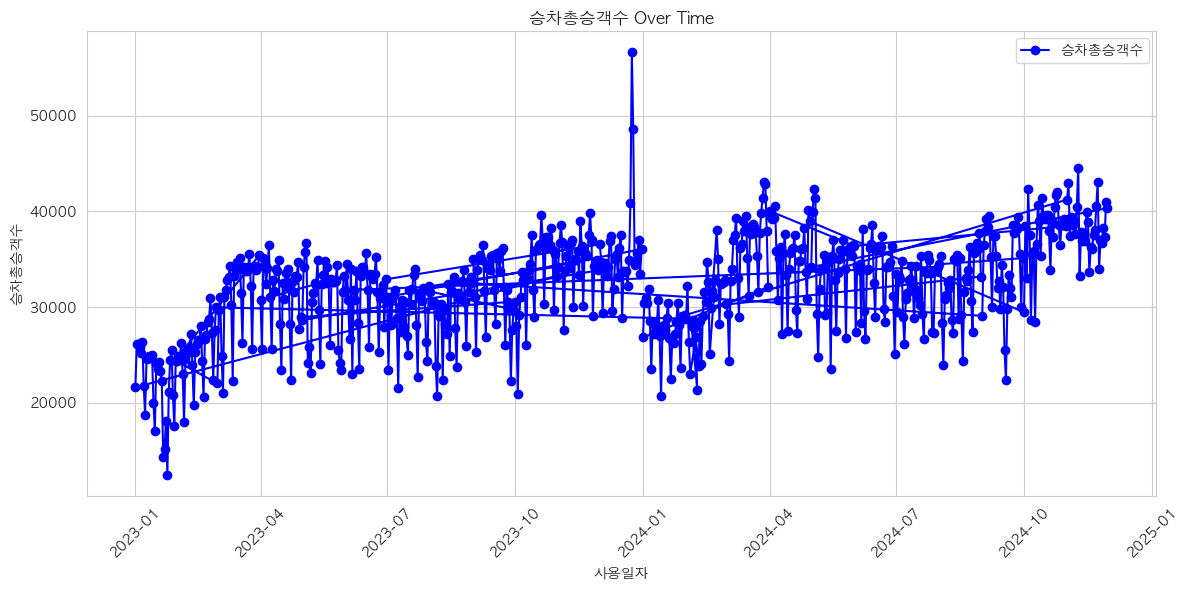

In [2275]:
import matplotlib.pyplot as plt

# Convert '사용일자' to datetime if it's not already in datetime format
md["사용일자"] = pd.to_datetime(md["사용일자"], format="%Y%m%d")

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(md["사용일자"], md["승차총승객수"], marker="o", linestyle="-", color="blue", label="승차총승객수")

# Add labels, title, and legend
plt.xlabel("사용일자")
plt.ylabel("승차총승객수")
plt.title("승차총승객수 Over Time")
plt.legend()

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()

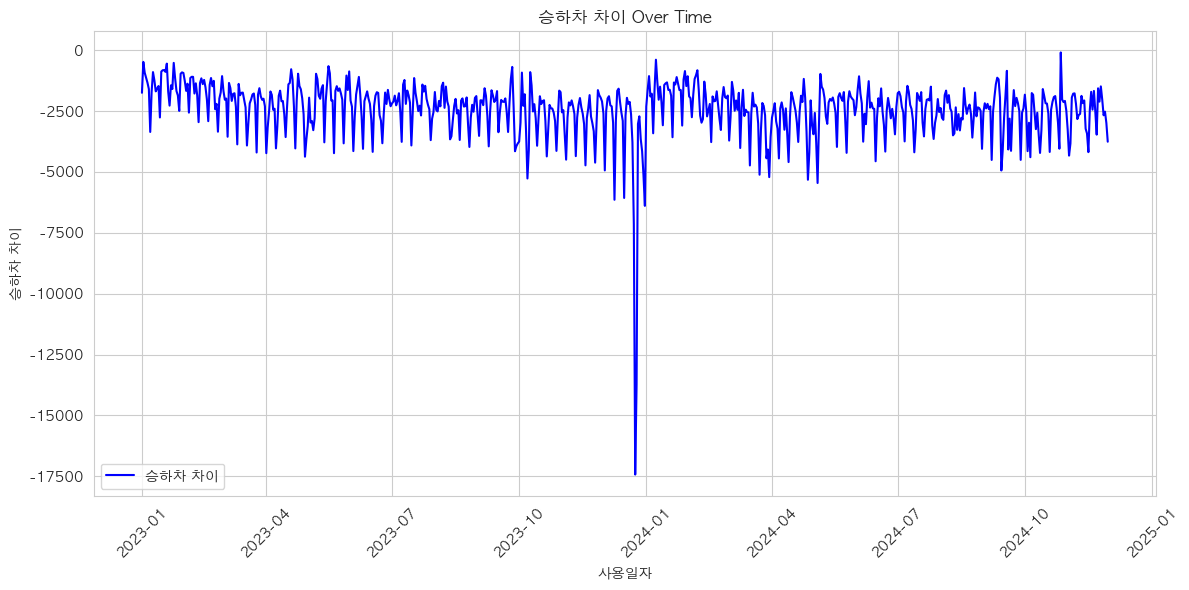

In [2276]:
# Sort the DataFrame by '사용일자' to ensure the plot is sequential
md = md.sort_values(by="사용일자")

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(md["사용일자"], md["승하차 차이"], linestyle="-", color="blue", label="승하차 차이")

# Add labels, title, and legend
plt.xlabel("사용일자")
plt.ylabel("승하차 차이")
plt.title("승하차 차이 Over Time")
plt.legend()

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()

In [2277]:
md["승차총승객수"].describe()

count      700.000000
mean     32093.882857
std       5179.113618
min      12484.000000
25%      28749.250000
50%      32843.000000
75%      35517.750000
max      56630.000000
Name: 승차총승객수, dtype: float64

In [2278]:
md[md["승차총승객수"] == 56630]

,사용일자,노선명,역명,승차총승객수,하차총승객수,승하차 차이
258180,2023-12-24,4호선,명동,56630,74060,-17430


In [2279]:
metro.drop("작업일자",axis=1,inplace=True)

In [2280]:
md

,사용일자,노선명,역명,승차총승객수,하차총승객수,승하차 차이
356265,2023-01-01,4호선,명동,21608,23356,-1748
356852,2023-01-02,4호선,명동,26155,26634,-479
357879,2023-01-03,4호선,명동,26088,27011,-923
358071,2023-01-04,4호선,명동,25781,26909,-1128
358662,2023-01-05,4호선,명동,25159,26493,-1334
...,...,...,...,...,...,...
128513,2024-11-26,4호선,명동,36729,38752,-2023
129122,2024-11-27,4호선,명동,38235,40908,-2673
130161,2024-11-28,4호선,명동,37342,39865,-2523
130741,2024-11-29,4호선,명동,40937,43926,-2989


In [2281]:
week= pd.read_csv("../data/Monthday_with_Week_Categories.csv")
holiday= pd.read_csv("../data/Weekend_Public_Holiday_Categories.csv")

In [2282]:
week.rename({"monthday" : "사용일자"},axis=1 ,inplace=True)
holiday.rename({"monthday" : "사용일자"},axis=1 ,inplace=True)

In [2283]:
week["사용일자"] = pd.to_datetime(week["사용일자"] , format="%Y%m%d")
holiday["사용일자"] = pd.to_datetime(holiday["사용일자"] , format="%Y%m%d")

In [2284]:
md_adj = pd.merge(md,week, on="사용일자",how="left")
md_adj = pd.merge(md_adj,holiday, on="사용일자",how="left")

In [2285]:
md_adj

,사용일자,노선명,역명,승차총승객수,하차총승객수,승하차 차이,week,weekend&public holiday
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1
1,2023-01-02,4호선,명동,26155,26634,-479,0,0
2,2023-01-03,4호선,명동,26088,27011,-923,1,0
3,2023-01-04,4호선,명동,25781,26909,-1128,2,0
4,2023-01-05,4호선,명동,25159,26493,-1334,3,0
...,...,...,...,...,...,...,...,...
695,2024-11-26,4호선,명동,36729,38752,-2023,1,0
696,2024-11-27,4호선,명동,38235,40908,-2673,2,0
697,2024-11-28,4호선,명동,37342,39865,-2523,3,0
698,2024-11-29,4호선,명동,40937,43926,-2989,4,0


In [2286]:
md_adj_sun = md_adj[md_adj["week"] == 6]
md_adj_sat = md_adj[md_adj["week"] == 5]
md_adj_fri = md_adj[md_adj["week"] == 4]
md_adj_thu = md_adj[md_adj["week"] == 3]
md_adj_wed = md_adj[md_adj["week"] == 2]
md_adj_tue = md_adj[md_adj["week"] == 1]
md_adj_mon = md_adj[md_adj["week"] == 0]

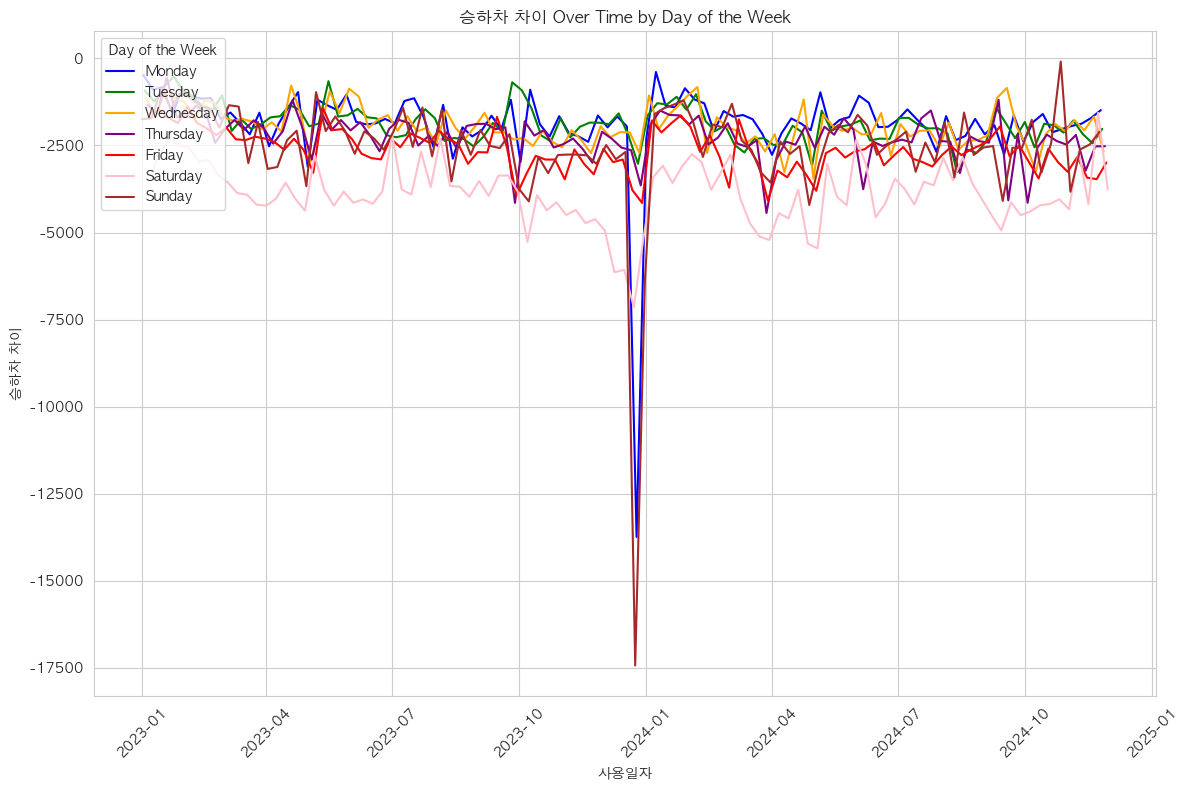

In [2287]:
import matplotlib.pyplot as plt

# List of DataFrames for each day of the week and their corresponding labels and colors
days_data = [
    (md_adj_mon, "Monday", "blue"),
    (md_adj_tue, "Tuesday", "green"),
    (md_adj_wed, "Wednesday", "orange"),
    (md_adj_thu, "Thursday", "purple"),
    (md_adj_fri, "Friday", "red"),
    (md_adj_sat, "Saturday", "pink"),
    (md_adj_sun, "Sunday", "brown"),
]

# Create the plot
plt.figure(figsize=(12, 8))
for data, label, color in days_data:
    # Sort the data to ensure the x-axis is sequential
    data = data.sort_values(by="사용일자")
    plt.plot(
        data["사용일자"], 
        data["승하차 차이"], 
        linestyle="-", 
        color=color, 
        label=label
    )

# Add labels, title, and legend
plt.xlabel("사용일자")
plt.ylabel("승하차 차이")
plt.title("승하차 차이 Over Time by Day of the Week")
plt.legend(title="Day of the Week", loc="upper left")  # Add legend with title

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()

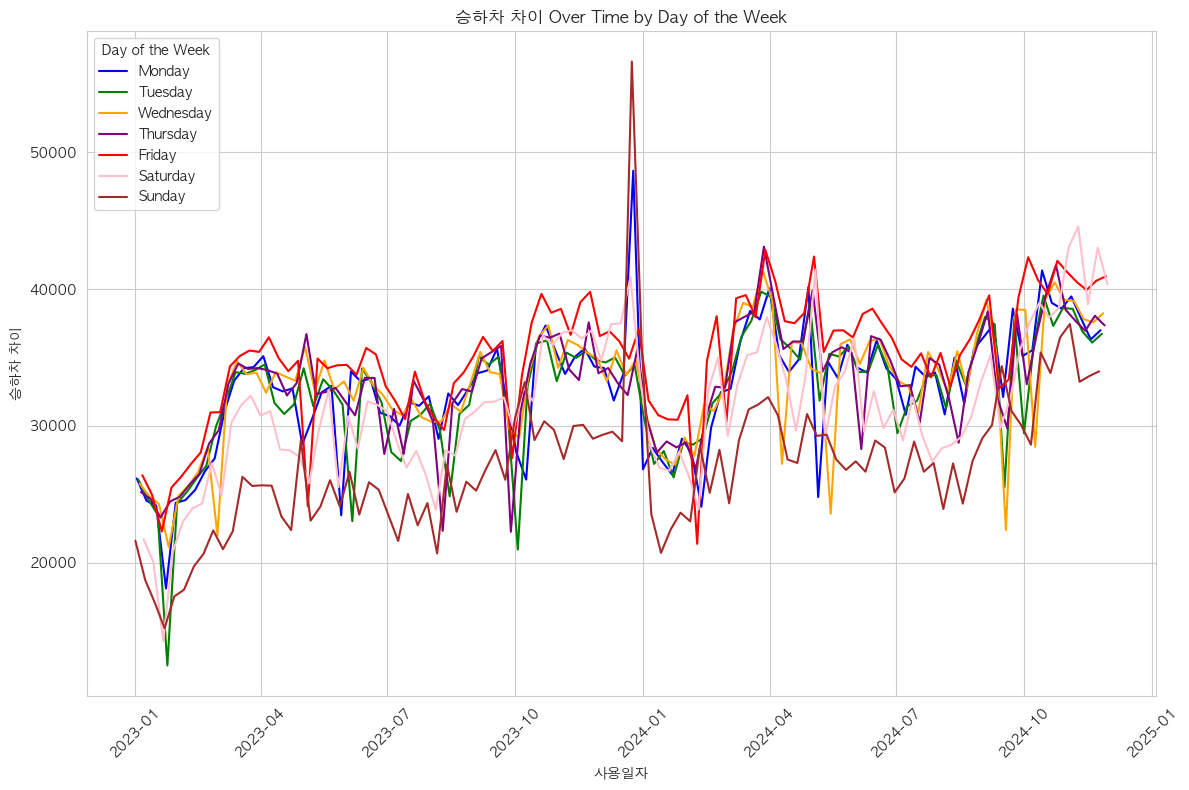

In [2288]:
import matplotlib.pyplot as plt

# List of DataFrames for each day of the week and their corresponding labels and colors
days_data = [
    (md_adj_mon, "Monday", "blue"),
    (md_adj_tue, "Tuesday", "green"),
    (md_adj_wed, "Wednesday", "orange"),
    (md_adj_thu, "Thursday", "purple"),
    (md_adj_fri, "Friday", "red"),
    (md_adj_sat, "Saturday", "pink"),
    (md_adj_sun, "Sunday", "brown"),
]

# Create the plot
plt.figure(figsize=(12, 8))
for data, label, color in days_data:
    # Sort the data to ensure the x-axis is sequential
    data = data.sort_values(by="사용일자")
    plt.plot(
        data["사용일자"], 
        data["승차총승객수"], 
        linestyle="-", 
        color=color, 
        label=label
    )

# Add labels, title, and legend
plt.xlabel("사용일자")
plt.ylabel("승하차 차이")
plt.title("승하차 차이 Over Time by Day of the Week")
plt.legend(title="Day of the Week", loc="upper left")  # Add legend with title

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()

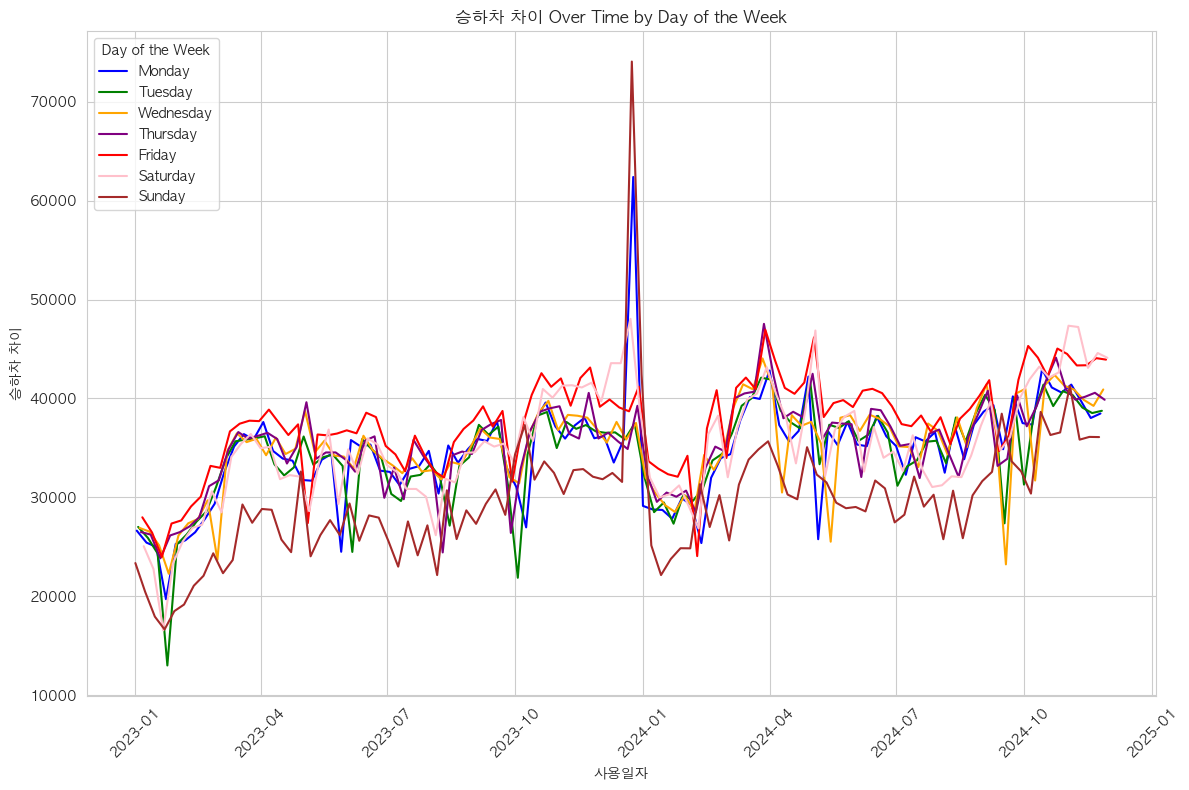

In [2289]:
import matplotlib.pyplot as plt

# List of DataFrames for each day of the week and their corresponding labels and colors
days_data = [
    (md_adj_mon, "Monday", "blue"),
    (md_adj_tue, "Tuesday", "green"),
    (md_adj_wed, "Wednesday", "orange"),
    (md_adj_thu, "Thursday", "purple"),
    (md_adj_fri, "Friday", "red"),
    (md_adj_sat, "Saturday", "pink"),
    (md_adj_sun, "Sunday", "brown"),
]

# Create the plot
plt.figure(figsize=(12, 8))
for data, label, color in days_data:
    # Sort the data to ensure the x-axis is sequential
    data = data.sort_values(by="사용일자")
    plt.plot(
        data["사용일자"], 
        data["하차총승객수"], 
        linestyle="-", 
        color=color, 
        label=label
    )

# Add labels, title, and legend
plt.xlabel("사용일자")
plt.ylabel("승하차 차이")
plt.title("승하차 차이 Over Time by Day of the Week")
plt.legend(title="Day of the Week", loc="upper left")  # Add legend with title

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()

# 4호선 전체

In [2290]:
line4 = df_combined[df_combined["노선명"] == "4호선"]

In [2291]:
line4[line4["역명"] == "선바위"]

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자,승하차 차이


In [2292]:
# Convert the unique stations to a list
unique_stations = line4["역명"].unique()
unique_stations

array(['남태령', '사당', '총신대입구(이수)', '동작(현충원)', '이촌(국립중앙박물관)', '신용산', '삼각지',
       '숙대입구(갈월)', '서울역', '회현(남대문시장)', '명동', '충무로', '동대문역사문화공원(DDP)',
       '동대문', '혜화', '한성대입구(삼선교)', '성신여대입구(돈암)', '길음', '미아사거리',
       '미아(서울사이버대학)', '수유(강북구청)', '쌍문', '창동', '노원', '상계', '당고개'],
      dtype=object)

In [2293]:
import pandas as pd

# Define the Seoul Metro Line 4 stations in order
line4_stations = [
    "당고개", "상계", "노원", "창동", "쌍문", "수유", "미아사거리", "길음", "성신여대입구",
    "한성대입구", "혜화", "동대문", "동대문역사문화공원", "충무로", "명동", "회현", "서울역",
    "숙대입구", "삼각지", "신용산", "이촌", "동작", "총신대입구(이수)", "사당", "남태령", "선바위",
    "경마공원", "대공원", "과천", "정부과천청사", "인덕원", "평촌", "범계", "금정", "산본",
    "수리산", "대야미", "반월", "상록수", "한대앞", "중앙", "고잔", "안산", "신길온천",
    "정왕", "오이도"
]

station_name_mapping = {
    "당고개": "당고개",
    "상계": "상계",
    "노원": "노원",
    "창동": "창동",
    "쌍문": "쌍문",
    "수유": "수유(강북구청)",
    "미아사거리": "미아사거리",
    "길음": "길음",
    "성신여대입구": "성신여대입구(돈암)",
    "한성대입구": "한성대입구(삼선교)",
    "혜화": "혜화",
    "동대문": "동대문",
    "동대문역사문화공원": "동대문역사문화공원(DDP)",
    "충무로": "충무로",
    "명동": "명동",
    "회현": "회현(남대문시장)",
    "서울역": "서울역",
    "숙대입구": "숙대입구(갈월)",
    "삼각지": "삼각지",
    "신용산": "신용산",
    "이촌": "이촌(국립중앙박물관)",
    "동작": "동작(현충원)",
    "총신대입구(이수)": "총신대입구(이수)",
    "사당": "사당",
    "남태령": "남태령",
    "선바위": "선바위",
    "경마공원": "경마공원",
    "대공원": "대공원",
    "과천": "과천",
    "정부과천청사": "정부과천청사",
    "인덕원": "인덕원",
    "평촌": "평촌",
    "범계": "범계",
    "금정": "금정",
    "산본": "산본",
    "수리산": "수리산",
    "대야미": "대야미",
    "반월": "반월",
    "상록수": "상록수",
    "한대앞": "한대앞",
    "중앙": "중앙",
    "고잔": "고잔",
    "안산": "안산",
    "신길온천": "신길온천",
    "정왕": "정왕",
    "오이도": "오이도"
}

# Sample data
line4 = pd.DataFrame({
    "사용일자": [20230901, 20230901, 20230902, 20230902, 20230901],
    "노선명": ["4호선"] * 5,
    "역명": ["남태령", "사당", "총신대입구", "동작", "이촌"],
    "승차총승객수": [1591, 30321, 21771, 2151, 10066],
    "하차총승객수": [1195, 26799, 23619, 2347, 10922],
    "등록일자": [20230904] * 5,
    "승하차 차이": [396, 3522, -1848, -196, -856]
})

# Convert 역명 to categorical with the custom order
line4["역명"] = pd.Categorical(line4["역명"], categories=line4_stations, ordered=True)

# Sort by date (사용일자) first, then by 역명 (station order)
line4_sorted = line4.sort_values(by=["사용일자", "역명"])

# Calculate the accumulated column for each day
line4_sorted["accumulated"] = line4_sorted.groupby("사용일자")["승하차 차이"].cumsum()

# Save to CSV or display
line4_sorted.to_csv("line4_sorted_with_accumulated.csv", index=False)
print(line4_sorted)

       사용일자  노선명   역명  승차총승객수  하차총승객수      등록일자  승하차 차이  accumulated
4  20230901  4호선   이촌   10066   10922  20230904    -856         -856
1  20230901  4호선   사당   30321   26799  20230904    3522         2666
0  20230901  4호선  남태령    1591    1195  20230904     396         3062
3  20230902  4호선   동작    2151    2347  20230904    -196         -196
2  20230902  4호선  NaN   21771   23619  20230904   -1848        -2044


# matro adjust

In [2294]:
metro

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 승차인원,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원
0,202411,1호선,동대문,590,18,11507,1945,9996,6511,16584,...,5576,9536,869,2870,2,219,0,0,0,0
1,202411,1호선,동묘앞,180,1,2890,959,3755,5025,9119,...,1307,4506,137,2065,1,272,0,0,0,0
2,202411,1호선,서울역,619,19,8411,8848,13670,58234,42622,...,28943,14302,3414,3953,0,187,0,0,0,0
3,202411,1호선,시청,71,0,2029,5239,3818,27038,7955,...,10576,3948,575,1036,2,17,0,0,0,0
4,202411,1호선,신설동,385,21,9307,2313,10188,9168,22551,...,3820,9065,426,2683,1,7,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70547,201501,중앙선,운길산,0,0,177,56,642,403,1292,...,111,633,3,222,0,0,0,0,0,0
70548,201501,중앙선,원덕,1,0,292,4,415,46,537,...,8,383,3,157,0,0,0,0,0,0
70549,201501,중앙선,중랑,14,1,4929,424,8539,2084,22160,...,1619,6501,86,1617,0,0,0,0,0,0
70550,201501,중앙선,팔당,0,0,161,50,368,149,1227,...,107,336,8,85,0,0,0,0,0,0


In [2295]:
metro_adj = metro.iloc[:,:]

In [2296]:
metro_adj

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 승차인원,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원
0,202411,1호선,동대문,590,18,11507,1945,9996,6511,16584,...,5576,9536,869,2870,2,219,0,0,0,0
1,202411,1호선,동묘앞,180,1,2890,959,3755,5025,9119,...,1307,4506,137,2065,1,272,0,0,0,0
2,202411,1호선,서울역,619,19,8411,8848,13670,58234,42622,...,28943,14302,3414,3953,0,187,0,0,0,0
3,202411,1호선,시청,71,0,2029,5239,3818,27038,7955,...,10576,3948,575,1036,2,17,0,0,0,0
4,202411,1호선,신설동,385,21,9307,2313,10188,9168,22551,...,3820,9065,426,2683,1,7,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70547,201501,중앙선,운길산,0,0,177,56,642,403,1292,...,111,633,3,222,0,0,0,0,0,0
70548,201501,중앙선,원덕,1,0,292,4,415,46,537,...,8,383,3,157,0,0,0,0,0,0
70549,201501,중앙선,중랑,14,1,4929,424,8539,2084,22160,...,1619,6501,86,1617,0,0,0,0,0,0
70550,201501,중앙선,팔당,0,0,161,50,368,149,1227,...,107,336,8,85,0,0,0,0,0,0


In [2297]:
df2_md = metro_adj[metro_adj["지하철역"] == "명동"].reset_index(drop=True)

In [2298]:
df2_md.drop(["호선명","지하철역"],axis=1,inplace= True)

In [2299]:
df2_md = df2_md.set_index("사용월").T
df2_md = df2_md[df2_md.index.str.contains("승차인원")]
df2_md.index = [str(int(str(i)[0:2]) * 100).zfill(4) for i in df2_md.index]

In [2300]:
df2_md

사용월,202411,202410,202409,202408,202407,202406,202405,202404,202403,202402,...,201510,201509,201508,201507,201506,201505,201504,201503,201502,201501
0400,44,33,34,27,23,20,25,40,37,14,...,14,14,4,11,6,24,37,13,16,17
0500,1892,1978,1757,1743,1529,1499,1669,1611,1482,1164,...,1553,1274,1344,1106,1076,1318,1385,1437,1129,1458
0600,4132,4503,4100,3943,3836,3927,4278,4085,4302,2997,...,3725,3145,3011,2708,2765,3526,3705,3487,2697,3074
0700,9020,9685,8848,8263,8515,8507,9063,8648,9579,6486,...,7595,6253,5576,5164,5338,6664,7356,7021,5475,5958
0800,18160,20322,18235,16638,15704,16480,17401,16814,19179,12238,...,14320,11521,9785,8021,8511,13120,14190,13300,9269,9533
0900,33474,35152,31778,32178,28792,30131,31184,30936,33807,23508,...,25969,20665,17915,12758,14046,25725,27655,25546,20786,18892
1000,38825,40779,37295,39767,36226,35987,36791,36473,42158,30498,...,33028,28168,25681,17274,18650,34023,36637,34000,28397,26261
1100,45264,46342,43447,44617,42392,42214,43720,42044,47838,35949,...,36482,32976,30933,23401,23685,38353,40306,38616,31475,31159
1200,46133,49198,45331,44202,43145,43896,45464,45165,47386,36376,...,43640,38550,37248,30128,28365,45155,45414,45612,37596,38317
1300,52010,55026,48868,47153,46514,47947,50153,49786,51717,40300,...,56233,48522,47695,42384,37818,60347,56131,57792,48540,50846


In [2301]:
df2_md.columns

Index([202411, 202410, 202409, 202408, 202407, 202406, 202405, 202404, 202403,
       202402,
       ...
       201510, 201509, 201508, 201507, 201506, 201505, 201504, 201503, 201502,
       201501],
      dtype='int64', name='사용월', length=119)

In [2302]:
import numpy as np

# Iterate through numeric columns
for i in df2_md.select_dtypes(include=[np.number]).columns:
    # Avoid division by zero for empty or zero-sum columns
    column_sum = df2_md[i].sum()
    if column_sum != 0:
        df2_md[f"{i}R"] = (df2_md[i] / column_sum).round(5)  # Round to 5 decimal places
    else:
        df2_md[f"{i}R"] = np.nan  # Assign NaN if the column sum is zero

# Display the updated DataFrame
print(df2_md)

사용월   202411  202410  202409  202408  202407  202406  202405  202404  202403  \
0400      44      33      34      27      23      20      25      40      37   
0500    1892    1978    1757    1743    1529    1499    1669    1611    1482   
0600    4132    4503    4100    3943    3836    3927    4278    4085    4302   
0700    9020    9685    8848    8263    8515    8507    9063    8648    9579   
0800   18160   20322   18235   16638   15704   16480   17401   16814   19179   
0900   33474   35152   31778   32178   28792   30131   31184   30936   33807   
1000   38825   40779   37295   39767   36226   35987   36791   36473   42158   
1100   45264   46342   43447   44617   42392   42214   43720   42044   47838   
1200   46133   49198   45331   44202   43145   43896   45464   45165   47386   
1300   52010   55026   48868   47153   46514   47947   50153   49786   51717   
1400   64364   68443   60392   54835   53833   59188   61962   60367   64014   
1500   84257   87035   75480   66163   6

/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_76769/2742297934.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2_md[f"{i}R"] = (df2_md[i] / column_sum).round(5)  # Round to 5 decimal places
/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_76769/2742297934.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2_md[f"{i}R"] = (df2_md[i] / column_sum).round(5)  # Round to 5 decimal places
/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_76769/2742297934.py:8: PerformanceWarning: DataFrame is h

In [2303]:
df2_md.index

Index(['0400', '0500', '0600', '0700', '0800', '0900', '1000', '1100', '1200',
       '1300', '1400', '1500', '1600', '1700', '1800', '1900', '2000', '2100',
       '2200', '2300', '0000', '0100', '0200', '0300'],
      dtype='object')

In [2304]:
import numpy as np

for i in df2_md.columns:
    if "R" not in str(i):
        for j in df2_md.index:
            df2_md.loc[ j , f"{i}DT"] = str(i)+str(j)
    else:
        continue


/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_76769/4075034509.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2_md.loc[ j , f"{i}DT"] = str(i)+str(j)
/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_76769/4075034509.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2_md.loc[ j , f"{i}DT"] = str(i)+str(j)
/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_76769/4075034509.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

In [2305]:
df2_md

사용월,202411,202410,202409,202408,202407,202406,202405,202404,202403,202402,...,201510DT,201509DT,201508DT,201507DT,201506DT,201505DT,201504DT,201503DT,201502DT,201501DT
0400,44,33,34,27,23,20,25,40,37,14,...,2015100400,2015090400,2015080400,2015070400,2015060400,2015050400,2015040400,2015030400,2015020400,2015010400
0500,1892,1978,1757,1743,1529,1499,1669,1611,1482,1164,...,2015100500,2015090500,2015080500,2015070500,2015060500,2015050500,2015040500,2015030500,2015020500,2015010500
0600,4132,4503,4100,3943,3836,3927,4278,4085,4302,2997,...,2015100600,2015090600,2015080600,2015070600,2015060600,2015050600,2015040600,2015030600,2015020600,2015010600
0700,9020,9685,8848,8263,8515,8507,9063,8648,9579,6486,...,2015100700,2015090700,2015080700,2015070700,2015060700,2015050700,2015040700,2015030700,2015020700,2015010700
0800,18160,20322,18235,16638,15704,16480,17401,16814,19179,12238,...,2015100800,2015090800,2015080800,2015070800,2015060800,2015050800,2015040800,2015030800,2015020800,2015010800
0900,33474,35152,31778,32178,28792,30131,31184,30936,33807,23508,...,2015100900,2015090900,2015080900,2015070900,2015060900,2015050900,2015040900,2015030900,2015020900,2015010900
1000,38825,40779,37295,39767,36226,35987,36791,36473,42158,30498,...,2015101000,2015091000,2015081000,2015071000,2015061000,2015051000,2015041000,2015031000,2015021000,2015011000
1100,45264,46342,43447,44617,42392,42214,43720,42044,47838,35949,...,2015101100,2015091100,2015081100,2015071100,2015061100,2015051100,2015041100,2015031100,2015021100,2015011100
1200,46133,49198,45331,44202,43145,43896,45464,45165,47386,36376,...,2015101200,2015091200,2015081200,2015071200,2015061200,2015051200,2015041200,2015031200,2015021200,2015011200
1300,52010,55026,48868,47153,46514,47947,50153,49786,51717,40300,...,2015101300,2015091300,2015081300,2015071300,2015061300,2015051300,2015041300,2015031300,2015021300,2015011300


In [2306]:
# Convert all column names to strings
df2_md.columns = df2_md.columns.astype(str)

# Identify columns for values, ratios, and datetime
value_cols = [col for col in df2_md.columns if not col.endswith("R") and not col.endswith("DT")]
ratio_cols = [col for col in df2_md.columns if col.endswith("R")]
datetime_cols = [col for col in df2_md.columns if col.endswith("DT")]

# Debugging: Print column lists
print("Value Columns:", value_cols)
print("Ratio Columns:", ratio_cols)
print("Datetime Columns:", datetime_cols)

# Ensure the value and ratio lists have the same length
assert len(value_cols) == len(ratio_cols), "Mismatch in value and ratio column counts!"

# Create an empty DataFrame for restructuring
restructured_df_in = pd.DataFrame()

# Combine values, ratios, and datetime columns into a unified structure
if datetime_cols:
    for value_col, ratio_col, datetime_col in zip(value_cols, ratio_cols, datetime_cols):
        temp_df = pd.DataFrame({
            "in": df2_md[value_col],  # Original values
            "ratio_in": df2_md[ratio_col],  # Ratios
            "datetime": df2_md[datetime_col]  # Corresponding datetime values
        })
        restructured_df_in = pd.concat([restructured_df_in, temp_df], ignore_index=True)
else:
    for value_col, ratio_col in zip(value_cols, ratio_cols):
        temp_df = pd.DataFrame({
            "in": df2_md[value_col],  # Original values
            "ratio_in": df2_md[ratio_col],  # Ratios
        })
        restructured_df_in = pd.concat([restructured_df_in, temp_df], ignore_index=True)

# Sort the restructured DataFrame if necessary
if "datetime" in restructured_df_in.columns:
    restructured_df = restructured_df_in.sort_values(by="datetime").reset_index(drop=True)

# Display the restructured DataFrame
print(restructured_df_in)

Value Columns: ['202411', '202410', '202409', '202408', '202407', '202406', '202405', '202404', '202403', '202402', '202401', '202312', '202311', '202310', '202309', '202308', '202307', '202306', '202305', '202304', '202303', '202302', '202301', '202212', '202211', '202210', '202209', '202208', '202207', '202206', '202205', '202204', '202203', '202202', '202201', '202112', '202111', '202110', '202109', '202108', '202107', '202106', '202105', '202104', '202103', '202102', '202101', '202012', '202011', '202010', '202009', '202008', '202007', '202006', '202005', '202004', '202003', '202002', '202001', '201912', '201911', '201910', '201909', '201908', '201907', '201906', '201905', '201904', '201903', '201902', '201901', '201812', '201811', '201810', '201809', '201808', '201807', '201806', '201805', '201804', '201803', '201802', '201801', '201712', '201711', '201710', '201709', '201708', '201707', '201706', '201705', '201704', '201703', '201702', '201701', '201612', '201611', '201610', '201

In [2307]:
restructured_df_in["year"] = [ str(i)[0:4] for i in restructured_df_in["datetime"]]
restructured_df_in["month"] = [ str(i)[4:6] for i in restructured_df_in["datetime"]]
restructured_df_in["time"] = [ str(i)[6:8] for i in restructured_df_in["datetime"]]

In [2308]:
restructured_df_in

,in,ratio_in,datetime,year,month,time
0,44,0.00004,2024110400,2024,11,04
1,1892,0.00164,2024110500,2024,11,05
2,4132,0.00358,2024110600,2024,11,06
3,9020,0.00782,2024110700,2024,11,07
4,18160,0.01575,2024110800,2024,11,08
...,...,...,...,...,...,...
2851,45613,0.03734,2015012300,2015,01,23
2852,2971,0.00243,2015010000,2015,01,00
2853,3,0.00000,2015010100,2015,01,01
2854,0,0.00000,2015010200,2015,01,02


# out

In [2309]:
df2_md = metro_adj[metro_adj["지하철역"] == "명동"].reset_index(drop=True)
df2_md.drop(["호선명","지하철역"],axis=1,inplace= True)
df2_md = df2_md.set_index("사용월").T
df2_md = df2_md[df2_md.index.str.contains("하차인원")]
df2_md.index = [str(int(str(i)[0:2]) * 100).zfill(4) for i in df2_md.index]
import numpy as np

# Iterate through numeric columns
for i in df2_md.select_dtypes(include=[np.number]).columns:
    # Avoid division by zero for empty or zero-sum columns
    column_sum = df2_md[i].sum()
    if column_sum != 0:
        df2_md[f"{i}R"] = (df2_md[i] / column_sum).round(5)  # Round to 5 decimal places
    else:
        df2_md[f"{i}R"] = np.nan  # Assign NaN if the column sum is zero

# Display the updated DataFrame
print(df2_md)

import numpy as np

for i in df2_md.columns:
    if "R" not in str(i):
        for j in df2_md.index:
            df2_md.loc[ j , f"{i}DT"] = str(i)+str(j)
    else:
        continue

# Convert all column names to strings
df2_md.columns = df2_md.columns.astype(str)

# Identify columns for values, ratios, and datetime
value_cols = [col for col in df2_md.columns if not col.endswith("R") and not col.endswith("DT")]
ratio_cols = [col for col in df2_md.columns if col.endswith("R")]
datetime_cols = [col for col in df2_md.columns if col.endswith("DT")]

# Debugging: Print column lists
print("Value Columns:", value_cols)
print("Ratio Columns:", ratio_cols)
print("Datetime Columns:", datetime_cols)

# Ensure the value and ratio lists have the same length
assert len(value_cols) == len(ratio_cols), "Mismatch in value and ratio column counts!"

# Create an empty DataFrame for restructuring
restructured_df_out = pd.DataFrame()

# Combine values, ratios, and datetime columns into a unified structure
if datetime_cols:
    for value_col, ratio_col, datetime_col in zip(value_cols, ratio_cols, datetime_cols):
        temp_df = pd.DataFrame({
            "out": df2_md[value_col],  # Original values
            "ratio_out": df2_md[ratio_col],  # Ratios
            "datetime": df2_md[datetime_col]  # Corresponding datetime values
        })
        restructured_df_out = pd.concat([restructured_df_out, temp_df], ignore_index=True)
else:
    for value_col, ratio_col in zip(value_cols, ratio_cols):
        temp_df = pd.DataFrame({
            "out": df2_md[value_col],  # Original values
            "ratio_out": df2_md[ratio_col],  # Ratios
        })
        restructured_df_out = pd.concat([restructured_df_out, temp_df], ignore_index=True)

# Sort the restructured DataFrame if necessary
if "datetime" in restructured_df_out.columns:
    restructured_df_out = restructured_df_out.sort_values(by="datetime").reset_index(drop=True)

# Display the restructured DataFrame
print(restructured_df_out)

사용월   202411  202410  202409  202408  202407  202406  202405  202404  202403  \
0400       0       1       8       9       2       3       2       0      10   
0500    1466    1898    1459    1424    1485    1544    1376    1267    1156   
0600   25061   25187   21821   23025   24450   23290   24021   23403   22348   
0700   55355   56227   49745   51077   56072   52620   54871   56939   55575   
0800  136749  134490  118703  121371  131844  118536  130121  134948  134366   
0900  111025  109065   94977   85248   91510   91908  100673  101651  101346   
1000   75688   79254   66380   62246   63360   66778   70421   73047   73054   
1100   76171   79957   67519   64483   63414   67872   71385   72479   74621   
1200   80314   85120   73706   68394   66392   73655   78250   79389   82459   
1300   80742   82588   74012   71120   69525   71267   75936   75129   79267   
1400   75651   79700   70021   68974   66111   68065   70488   67962   74532   
1500   79333   80317   73077   69928   6

/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_76769/4235078140.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2_md[f"{i}R"] = (df2_md[i] / column_sum).round(5)  # Round to 5 decimal places
/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_76769/4235078140.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2_md[f"{i}R"] = (df2_md[i] / column_sum).round(5)  # Round to 5 decimal places
/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_76769/4235078140.py:13: PerformanceWarning: DataFrame i

Value Columns: ['202411', '202410', '202409', '202408', '202407', '202406', '202405', '202404', '202403', '202402', '202401', '202312', '202311', '202310', '202309', '202308', '202307', '202306', '202305', '202304', '202303', '202302', '202301', '202212', '202211', '202210', '202209', '202208', '202207', '202206', '202205', '202204', '202203', '202202', '202201', '202112', '202111', '202110', '202109', '202108', '202107', '202106', '202105', '202104', '202103', '202102', '202101', '202012', '202011', '202010', '202009', '202008', '202007', '202006', '202005', '202004', '202003', '202002', '202001', '201912', '201911', '201910', '201909', '201908', '201907', '201906', '201905', '201904', '201903', '201902', '201901', '201812', '201811', '201810', '201809', '201808', '201807', '201806', '201805', '201804', '201803', '201802', '201801', '201712', '201711', '201710', '201709', '201708', '201707', '201706', '201705', '201704', '201703', '201702', '201701', '201612', '201611', '201610', '201

# prev CMR

# prev station in 

In [2310]:
df2_md = metro_adj[metro_adj["지하철역"] == "충무로"].reset_index(drop=True)
df2_md = df2_md.groupby('사용월').sum()
df2_md.reset_index(inplace=True)
df2_md.drop(["호선명","지하철역"],axis=1,inplace= True)
df2_md = df2_md.set_index("사용월").T
df2_md = df2_md[df2_md.index.str.contains("승차인원")]
df2_md.index = [str(int(str(i)[0:2]) * 100).zfill(4) for i in df2_md.index]
import numpy as np

# Iterate through numeric columns
for i in df2_md.select_dtypes(include=[np.number]).columns:
    # Avoid division by zero for empty or zero-sum columns
    column_sum = df2_md[i].sum()
    if column_sum != 0:
        df2_md[f"{i}R"] = (df2_md[i] / column_sum).round(5)  # Round to 5 decimal places
    else:
        df2_md[f"{i}R"] = np.nan  # Assign NaN if the column sum is zero

# Display the updated DataFrame
print(df2_md)

import numpy as np

for i in df2_md.columns:
    if "R" not in str(i):
        for j in df2_md.index:
            df2_md.loc[ j , f"{i}DT"] = str(i)+str(j)
    else:
        continue

# Convert all column names to strings
df2_md.columns = df2_md.columns.astype(str)

# Identify columns for values, ratios, and datetime
value_cols = [col for col in df2_md.columns if not col.endswith("R") and not col.endswith("DT")]
ratio_cols = [col for col in df2_md.columns if col.endswith("R")]
datetime_cols = [col for col in df2_md.columns if col.endswith("DT")]

# Debugging: Print column lists
print("Value Columns:", value_cols)
print("Ratio Columns:", ratio_cols)
print("Datetime Columns:", datetime_cols)

# Ensure the value and ratio lists have the same length
assert len(value_cols) == len(ratio_cols), "Mismatch in value and ratio column counts!"

# Create an empty DataFrame for restructuring
restructured_df_in_CMR = pd.DataFrame()

# Combine values, ratios, and datetime columns into a unified structure
if datetime_cols:
    for value_col, ratio_col, datetime_col in zip(value_cols, ratio_cols, datetime_cols):
        temp_df = pd.DataFrame({
            "in_CMR": df2_md[value_col],  # Original values
            "ratio_in_CMR": df2_md[ratio_col],  # Ratios
            "datetime": df2_md[datetime_col]  # Corresponding datetime values
        })
        restructured_df_in_CMR = pd.concat([restructured_df_in_CMR, temp_df], ignore_index=True)
else:
    for value_col, ratio_col in zip(value_cols, ratio_cols):
        temp_df = pd.DataFrame({
            "in_CMR": df2_md[value_col],  # Original values
            "ratio_in_CMR": df2_md[ratio_col],  # Ratios
        })
        restructured_df_in_CMR = pd.concat([restructured_df_in_CMR, temp_df], ignore_index=True)

# Sort the restructured DataFrame if necessary
if "datetime" in restructured_df_in_CMR.columns:
    restructured_df_in_CMR = restructured_df_in_CMR.sort_values(by="datetime").reset_index(drop=True)

# Display the restructured DataFrame
print(restructured_df_in_CMR)

사용월   201501  201502  201503  201504  201505  201506  201507  201508  201509  \
0400      94      97     110     120      99      86     103      63      93   
0500    3373    2888    3803    3974    4443    4119    3613    3412    3358   
0600    5569    4714    5934    6858    6571    6000    5720    5749    5784   
0700   10263    8549   12044   12362   11335   10449   10784    9956   10789   
0800   18426   15600   20430   20592   19415   17268   18076   17550   17333   
0900   23123   20568   25442   26692   26221   20202   21231   22441   22144   
1000   24827   23254   30045   31176   29372   22445   22705   24944   24764   
1100   31208   27256   34823   36450   36372   27742   29236   30204   30448   
1200   36214   31482   40548   42167   42866   32846   34711   34452   35183   
1300   44529   38705   49091   49477   50116   40181   41118   40081   42496   
1400   50058   43664   56413   56929   56286   45095   46316   45765   50595   
1500   58253   51992   67612   67390   6

/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_76769/1748941234.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2_md[f"{i}R"] = (df2_md[i] / column_sum).round(5)  # Round to 5 decimal places
/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_76769/1748941234.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2_md[f"{i}R"] = (df2_md[i] / column_sum).round(5)  # Round to 5 decimal places
/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_76769/1748941234.py:15: PerformanceWarning: DataFrame i

Value Columns: ['201501', '201502', '201503', '201504', '201505', '201506', '201507', '201508', '201509', '201510', '201511', '201512', '201601', '201602', '201603', '201604', '201605', '201606', '201607', '201608', '201609', '201610', '201611', '201612', '201701', '201702', '201703', '201704', '201705', '201706', '201707', '201708', '201709', '201710', '201711', '201712', '201801', '201802', '201803', '201804', '201805', '201806', '201807', '201808', '201809', '201810', '201811', '201812', '201901', '201902', '201903', '201904', '201905', '201906', '201907', '201908', '201909', '201910', '201911', '201912', '202001', '202002', '202003', '202004', '202005', '202006', '202007', '202008', '202009', '202010', '202011', '202012', '202101', '202102', '202103', '202104', '202105', '202106', '202107', '202108', '202109', '202110', '202111', '202112', '202201', '202202', '202203', '202204', '202205', '202206', '202207', '202208', '202209', '202210', '202211', '202212', '202301', '202302', '202

In [2311]:
restructured_df_in_CMR

,in_CMR,ratio_in_CMR,datetime
0,5425,0.00542,2015010000
1,1,0.00000,2015010100
2,0,0.00000,2015010200
3,0,0.00000,2015010300
4,94,0.00009,2015010400
...,...,...,...
2851,74975,0.07918,2024111900
2852,59806,0.06316,2024112000
2853,56421,0.05958,2024112100
2854,42341,0.04471,2024112200


# prev HH

In [2312]:
df2_md = metro_adj[metro_adj["지하철역"].str.contains("회현", na=False)].reset_index(drop=True)
df2_md.drop(["호선명","지하철역"],axis=1,inplace= True)
df2_md = df2_md.set_index("사용월").T
df2_md = df2_md[df2_md.index.str.contains("승차인원")]
df2_md.index = [str(int(str(i)[0:2]) * 100).zfill(4) for i in df2_md.index]
import numpy as np

# Iterate through numeric columns
for i in df2_md.select_dtypes(include=[np.number]).columns:
    # Avoid division by zero for empty or zero-sum columns
    column_sum = df2_md[i].sum()
    if column_sum != 0:
        df2_md[f"{i}R"] = (df2_md[i] / column_sum).round(5)  # Round to 5 decimal places
    else:
        df2_md[f"{i}R"] = np.nan  # Assign NaN if the column sum is zero

# Display the updated DataFrame
print(df2_md)

import numpy as np

for i in df2_md.columns:
    if "R" not in str(i):
        for j in df2_md.index:
            df2_md.loc[ j , f"{i}DT"] = str(i)+str(j)
    else:
        continue

# Convert all column names to strings
df2_md.columns = df2_md.columns.astype(str)

# Identify columns for values, ratios, and datetime
value_cols = [col for col in df2_md.columns if not col.endswith("R") and not col.endswith("DT")]
ratio_cols = [col for col in df2_md.columns if col.endswith("R")]
datetime_cols = [col for col in df2_md.columns if col.endswith("DT")]

# Debugging: Print column lists
print("Value Columns:", value_cols)
print("Ratio Columns:", ratio_cols)
print("Datetime Columns:", datetime_cols)

# Ensure the value and ratio lists have the same length
assert len(value_cols) == len(ratio_cols), "Mismatch in value and ratio column counts!"

# Create an empty DataFrame for restructuring
restructured_df_in_HH = pd.DataFrame()

# Combine values, ratios, and datetime columns into a unified structure
if datetime_cols:
    for value_col, ratio_col, datetime_col in zip(value_cols, ratio_cols, datetime_cols):
        temp_df = pd.DataFrame({
            "in_HH": df2_md[value_col],  # Original values
            "ratio_in_HH": df2_md[ratio_col],  # Ratios
            "datetime": df2_md[datetime_col]  # Corresponding datetime values
        })
        restructured_df_in_HH = pd.concat([restructured_df_in_HH, temp_df], ignore_index=True)
else:
    for value_col, ratio_col in zip(value_cols, ratio_cols):
        temp_df = pd.DataFrame({
            "in_HH": df2_md[value_col],  # Original values
            "ratio_in_HH": df2_md[ratio_col],  # Ratios
        })
        restructured_df_in_HH = pd.concat([restructured_df_in_HH, temp_df], ignore_index=True)

# Sort the restructured DataFrame if necessary
if "datetime" in restructured_df_in_HH.columns:
    restructured_df_in_HH = restructured_df_in_HH.sort_values(by="datetime").reset_index(drop=True)

# Display the restructured DataFrame
print(restructured_df_in_HH)

사용월   202411  202410  202409  202408  202407  202406  202405  202404  202403  \
0400      26      19      14      22      23      26      21      32      35   
0500    1519    1585    1248    1299    1365    1404    1459    1448    1347   
0600    3503    3690    3188    3161    3489    3190    3475    3338    3380   
0700    5712    6055    5235    5134    5199    5196    5559    5490    5515   
0800    9978   11047    9032    9243    9442    9212    9691    9540    9865   
0900   14943   15688   13124   13205   13008   13023   13380   13312   13475   
1000   20566   21558   17866   19133   19208   19352   19783   19238   19070   
1100   31615   32856   27671   29617   30719   31893   32797   30466   30380   
1200   41003   44443   36231   38877   40486   42726   45002   42525   41288   
1300   53121   56801   45432   46596   50713   54361   58785   56890   54564   
1400   68197   72304   55010   54295   60421   64787   71877   69534   67467   
1500   81107   86383   64275   63007   7

/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_76769/3262245431.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2_md[f"{i}R"] = (df2_md[i] / column_sum).round(5)  # Round to 5 decimal places
/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_76769/3262245431.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2_md[f"{i}R"] = (df2_md[i] / column_sum).round(5)  # Round to 5 decimal places
/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_76769/3262245431.py:13: PerformanceWarning: DataFrame i

Value Columns: ['202411', '202410', '202409', '202408', '202407', '202406', '202405', '202404', '202403', '202402', '202401', '202312', '202311', '202310', '202309', '202308', '202307', '202306', '202305', '202304', '202303', '202302', '202301', '202212', '202211', '202210', '202209', '202208', '202207', '202206', '202205', '202204', '202203', '202202', '202201', '202112', '202111', '202110', '202109', '202108', '202107', '202106', '202105', '202104', '202103', '202102', '202101', '202012', '202011', '202010', '202009', '202008', '202007', '202006', '202005', '202004', '202003', '202002', '202001', '201912', '201911', '201910', '201909', '201908', '201907', '201906', '201905', '201904', '201903', '201902', '201901', '201812', '201811', '201810', '201809', '201808', '201807', '201806', '201805', '201804', '201803', '201802', '201801', '201712', '201711', '201710', '201709', '201708', '201707', '201706', '201705', '201704', '201703', '201702', '201701', '201612', '201611', '201610', '201

In [2313]:
restructured_df_in_HH

,in_HH,ratio_in_HH,datetime
0,1156,0.00131,2015010000
1,0,0.00000,2015010100
2,0,0.00000,2015010200
3,0,0.00000,2015010300
4,0,0.00000,2015010400
...,...,...,...
2851,64014,0.07529,2024111900
2852,58422,0.06871,2024112000
2853,24412,0.02871,2024112100
2854,13427,0.01579,2024112200


In [2314]:
restructured_df_combine = pd.merge(restructured_df_in, restructured_df_out, on="datetime",how="left")

In [2315]:
restructured_df_combine = pd.merge(restructured_df_combine, restructured_df_in_CMR, on="datetime",how="left")

In [2316]:
restructured_df_combine = pd.merge(restructured_df_combine, restructured_df_in_HH, on="datetime",how="left")

In [2317]:
restructured_df_combine

,in,ratio_in,datetime,year,month,time,out,ratio_out,in_CMR,ratio_in_CMR,in_HH,ratio_in_HH
0,44,0.00004,2024110400,2024,11,04,0,0.00000,72,0.00008,26,0.00003
1,1892,0.00164,2024110500,2024,11,05,1466,0.00119,3510,0.00371,1519,0.00179
2,4132,0.00358,2024110600,2024,11,06,25061,0.02036,5864,0.00619,3503,0.00412
3,9020,0.00782,2024110700,2024,11,07,55355,0.04498,12941,0.01367,5712,0.00672
4,18160,0.01575,2024110800,2024,11,08,136749,0.11112,24046,0.02539,9978,0.01174
...,...,...,...,...,...,...,...,...,...,...,...,...
2851,45613,0.03734,2015012300,2015,01,23,8871,0.00665,30679,0.03065,9133,0.01036
2852,2971,0.00243,2015010000,2015,01,00,2215,0.00166,5425,0.00542,1156,0.00131
2853,3,0.00000,2015010100,2015,01,01,82,0.00006,1,0.00000,0,0.00000
2854,0,0.00000,2015010200,2015,01,02,0,0.00000,0,0.00000,0,0.00000


In [2318]:
restructured_df_combine["Net_in_out"] = restructured_df_combine["in"] - restructured_df_combine["out"]

In [2319]:
restructured_df_combine

,in,ratio_in,datetime,year,month,time,out,ratio_out,in_CMR,ratio_in_CMR,in_HH,ratio_in_HH,Net_in_out
0,44,0.00004,2024110400,2024,11,04,0,0.00000,72,0.00008,26,0.00003,44
1,1892,0.00164,2024110500,2024,11,05,1466,0.00119,3510,0.00371,1519,0.00179,426
2,4132,0.00358,2024110600,2024,11,06,25061,0.02036,5864,0.00619,3503,0.00412,-20929
3,9020,0.00782,2024110700,2024,11,07,55355,0.04498,12941,0.01367,5712,0.00672,-46335
4,18160,0.01575,2024110800,2024,11,08,136749,0.11112,24046,0.02539,9978,0.01174,-118589
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2851,45613,0.03734,2015012300,2015,01,23,8871,0.00665,30679,0.03065,9133,0.01036,36742
2852,2971,0.00243,2015010000,2015,01,00,2215,0.00166,5425,0.00542,1156,0.00131,756
2853,3,0.00000,2015010100,2015,01,01,82,0.00006,1,0.00000,0,0.00000,-79
2854,0,0.00000,2015010200,2015,01,02,0,0.00000,0,0.00000,0,0.00000,0


In [2320]:
# Identify invalid datetime entries
# invalid_entries = restructured_df_combine[~restructured_df_combine['datetime'].str.match(r'^\d{10}$')]

# # Print invalid entries to inspect them
# print("Invalid datetime entries:", invalid_entries)

# # Replace invalid entries or drop them
# restructured_df_combine = restructured_df_combine[restructured_df_combine['datetime'].str.match(r'^\d{10}$')]

# # Parse the datetime column
# restructured_df_combine['datetime'] = pd.to_datetime(restructured_df_combine['datetime'], format='%Y%m%d%H', errors='coerce')

# # Handle any remaining NaT values (if invalid dates were not dropped)
# restructured_df_combine = restructured_df_combine.dropna(subset=['datetime'])

In [2321]:
# restructured_df_combine.replace(np.inf, 0)

In [2322]:
restructured_df_combine["datetime"] = restructured_df_combine["year"].astype(str) + restructured_df_combine["month"].astype(str) + restructured_df_combine["time"].astype(str)

In [2323]:
restructured_df_combine

,in,ratio_in,datetime,year,month,time,out,ratio_out,in_CMR,ratio_in_CMR,in_HH,ratio_in_HH,Net_in_out
0,44,0.00004,20241104,2024,11,04,0,0.00000,72,0.00008,26,0.00003,44
1,1892,0.00164,20241105,2024,11,05,1466,0.00119,3510,0.00371,1519,0.00179,426
2,4132,0.00358,20241106,2024,11,06,25061,0.02036,5864,0.00619,3503,0.00412,-20929
3,9020,0.00782,20241107,2024,11,07,55355,0.04498,12941,0.01367,5712,0.00672,-46335
4,18160,0.01575,20241108,2024,11,08,136749,0.11112,24046,0.02539,9978,0.01174,-118589
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2851,45613,0.03734,20150123,2015,01,23,8871,0.00665,30679,0.03065,9133,0.01036,36742
2852,2971,0.00243,20150100,2015,01,00,2215,0.00166,5425,0.00542,1156,0.00131,756
2853,3,0.00000,20150101,2015,01,01,82,0.00006,1,0.00000,0,0.00000,-79
2854,0,0.00000,20150102,2015,01,02,0,0.00000,0,0.00000,0,0.00000,0


In [2324]:
restructured_df_combine["datetime"].unique()

array(['20241104', '20241105', '20241106', ..., '20150101', '20150102',
       '20150103'], dtype=object)

In [2325]:
restructured_df_combine['datetime'] = restructured_df_combine['datetime'].astype(str).str.strip()
restructured_df_in["year"] = [ str(i)[0:4] for i in restructured_df_in["datetime"]]
restructured_df_in["month"] = [ str(i)[4:6] for i in restructured_df_in["datetime"]]
restructured_df_in["time"] = [ str(i)[6:8] for i in restructured_df_in["datetime"]]

In [2326]:
restructured_df_combine["yearmonth"] = restructured_df_combine["year"].astype(str) + restructured_df_combine["month"].astype(str)

In [2327]:
restructured_df_combine

,in,ratio_in,datetime,year,month,time,out,ratio_out,in_CMR,ratio_in_CMR,in_HH,ratio_in_HH,Net_in_out,yearmonth
0,44,0.00004,20241104,2024,11,04,0,0.00000,72,0.00008,26,0.00003,44,202411
1,1892,0.00164,20241105,2024,11,05,1466,0.00119,3510,0.00371,1519,0.00179,426,202411
2,4132,0.00358,20241106,2024,11,06,25061,0.02036,5864,0.00619,3503,0.00412,-20929,202411
3,9020,0.00782,20241107,2024,11,07,55355,0.04498,12941,0.01367,5712,0.00672,-46335,202411
4,18160,0.01575,20241108,2024,11,08,136749,0.11112,24046,0.02539,9978,0.01174,-118589,202411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2851,45613,0.03734,20150123,2015,01,23,8871,0.00665,30679,0.03065,9133,0.01036,36742,201501
2852,2971,0.00243,20150100,2015,01,00,2215,0.00166,5425,0.00542,1156,0.00131,756,201501
2853,3,0.00000,20150101,2015,01,01,82,0.00006,1,0.00000,0,0.00000,-79,201501
2854,0,0.00000,20150102,2015,01,02,0,0.00000,0,0.00000,0,0.00000,0,201501


In [2328]:
restructured_df_combine['yearmonth'] = pd.to_datetime(restructured_df_combine['yearmonth'], format="%Y%m")

In [2329]:
restructured_df_combine

,in,ratio_in,datetime,year,month,time,out,ratio_out,in_CMR,ratio_in_CMR,in_HH,ratio_in_HH,Net_in_out,yearmonth
0,44,0.00004,20241104,2024,11,04,0,0.00000,72,0.00008,26,0.00003,44,2024-11-01
1,1892,0.00164,20241105,2024,11,05,1466,0.00119,3510,0.00371,1519,0.00179,426,2024-11-01
2,4132,0.00358,20241106,2024,11,06,25061,0.02036,5864,0.00619,3503,0.00412,-20929,2024-11-01
3,9020,0.00782,20241107,2024,11,07,55355,0.04498,12941,0.01367,5712,0.00672,-46335,2024-11-01
4,18160,0.01575,20241108,2024,11,08,136749,0.11112,24046,0.02539,9978,0.01174,-118589,2024-11-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2851,45613,0.03734,20150123,2015,01,23,8871,0.00665,30679,0.03065,9133,0.01036,36742,2015-01-01
2852,2971,0.00243,20150100,2015,01,00,2215,0.00166,5425,0.00542,1156,0.00131,756,2015-01-01
2853,3,0.00000,20150101,2015,01,01,82,0.00006,1,0.00000,0,0.00000,-79,2015-01-01
2854,0,0.00000,20150102,2015,01,02,0,0.00000,0,0.00000,0,0.00000,0,2015-01-01


In [2330]:
from datetime import datetime
from dateutil.relativedelta import relativedelta


restructured_df_combine["prev_month"] =  restructured_df_combine['yearmonth'] - pd.DateOffset(months=1)

In [2331]:
# restructured_df_combine["prev_month"] = [ str(i).replace("-","") for i in restructured_df_combine["prev_month"]]
# restructured_df_combine["prev_month"] = restructured_df_combine["prev_month"].astype(str) +  restructured_df_combine["time"].astype(str)

In [2332]:
restructured_df_combine

,in,ratio_in,datetime,year,month,time,out,ratio_out,in_CMR,ratio_in_CMR,in_HH,ratio_in_HH,Net_in_out,yearmonth,prev_month
0,44,0.00004,20241104,2024,11,04,0,0.00000,72,0.00008,26,0.00003,44,2024-11-01,2024-10-01
1,1892,0.00164,20241105,2024,11,05,1466,0.00119,3510,0.00371,1519,0.00179,426,2024-11-01,2024-10-01
2,4132,0.00358,20241106,2024,11,06,25061,0.02036,5864,0.00619,3503,0.00412,-20929,2024-11-01,2024-10-01
3,9020,0.00782,20241107,2024,11,07,55355,0.04498,12941,0.01367,5712,0.00672,-46335,2024-11-01,2024-10-01
4,18160,0.01575,20241108,2024,11,08,136749,0.11112,24046,0.02539,9978,0.01174,-118589,2024-11-01,2024-10-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2851,45613,0.03734,20150123,2015,01,23,8871,0.00665,30679,0.03065,9133,0.01036,36742,2015-01-01,2014-12-01
2852,2971,0.00243,20150100,2015,01,00,2215,0.00166,5425,0.00542,1156,0.00131,756,2015-01-01,2014-12-01
2853,3,0.00000,20150101,2015,01,01,82,0.00006,1,0.00000,0,0.00000,-79,2015-01-01,2014-12-01
2854,0,0.00000,20150102,2015,01,02,0,0.00000,0,0.00000,0,0.00000,0,2015-01-01,2014-12-01


In [2333]:
restructured_df_combine.drop("yearmonth", axis=1 ,inplace=True)

In [2334]:
restructured_df_combine['prev_month'] = [ str(i)[0:4] + str(i)[5:7] for i in restructured_df_combine['prev_month']]

In [2335]:
restructured_df_combine['prev_month'] = restructured_df_combine['prev_month'] + restructured_df_combine['time']

In [2336]:
restructured_df_combine

,in,ratio_in,datetime,year,month,time,out,ratio_out,in_CMR,ratio_in_CMR,in_HH,ratio_in_HH,Net_in_out,prev_month
0,44,0.00004,20241104,2024,11,04,0,0.00000,72,0.00008,26,0.00003,44,20241004
1,1892,0.00164,20241105,2024,11,05,1466,0.00119,3510,0.00371,1519,0.00179,426,20241005
2,4132,0.00358,20241106,2024,11,06,25061,0.02036,5864,0.00619,3503,0.00412,-20929,20241006
3,9020,0.00782,20241107,2024,11,07,55355,0.04498,12941,0.01367,5712,0.00672,-46335,20241007
4,18160,0.01575,20241108,2024,11,08,136749,0.11112,24046,0.02539,9978,0.01174,-118589,20241008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2851,45613,0.03734,20150123,2015,01,23,8871,0.00665,30679,0.03065,9133,0.01036,36742,20141223
2852,2971,0.00243,20150100,2015,01,00,2215,0.00166,5425,0.00542,1156,0.00131,756,20141200
2853,3,0.00000,20150101,2015,01,01,82,0.00006,1,0.00000,0,0.00000,-79,20141201
2854,0,0.00000,20150102,2015,01,02,0,0.00000,0,0.00000,0,0.00000,0,20141202


In [2337]:
restructured_df_combine['prev_Net_in_out'] = restructured_df_combine['prev_month'].map(lambda x : restructured_df_combine[restructured_df_combine['datetime'] == x].iloc[0,0] if int(x[0:4]) > 2014 else None)

In [2338]:
restructured_df_combine

,in,ratio_in,datetime,year,month,time,out,ratio_out,in_CMR,ratio_in_CMR,in_HH,ratio_in_HH,Net_in_out,prev_month,prev_Net_in_out
0,44,0.00004,20241104,2024,11,04,0,0.00000,72,0.00008,26,0.00003,44,20241004,33.0
1,1892,0.00164,20241105,2024,11,05,1466,0.00119,3510,0.00371,1519,0.00179,426,20241005,1978.0
2,4132,0.00358,20241106,2024,11,06,25061,0.02036,5864,0.00619,3503,0.00412,-20929,20241006,4503.0
3,9020,0.00782,20241107,2024,11,07,55355,0.04498,12941,0.01367,5712,0.00672,-46335,20241007,9685.0
4,18160,0.01575,20241108,2024,11,08,136749,0.11112,24046,0.02539,9978,0.01174,-118589,20241008,20322.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2851,45613,0.03734,20150123,2015,01,23,8871,0.00665,30679,0.03065,9133,0.01036,36742,20141223,NaN
2852,2971,0.00243,20150100,2015,01,00,2215,0.00166,5425,0.00542,1156,0.00131,756,20141200,NaN
2853,3,0.00000,20150101,2015,01,01,82,0.00006,1,0.00000,0,0.00000,-79,20141201,NaN
2854,0,0.00000,20150102,2015,01,02,0,0.00000,0,0.00000,0,0.00000,0,20141202,NaN


In [2339]:
restructured_df_combine["Net_pre_cur_in_out"] = restructured_df_combine["Net_in_out"] - restructured_df_combine["prev_Net_in_out"]

In [2340]:
restructured_df_combine["Net_pre_cur_in_out(%)"] = (restructured_df_combine["Net_in_out"] / restructured_df_combine["prev_Net_in_out"]) -1

In [2341]:
restructured_df_combine_pre_net_in_out =  restructured_df_combine.fillna(0)

In [2342]:
restructured_df_combine_pre_net_in_out

,in,ratio_in,datetime,year,month,time,out,ratio_out,in_CMR,ratio_in_CMR,in_HH,ratio_in_HH,Net_in_out,prev_month,prev_Net_in_out,Net_pre_cur_in_out,Net_pre_cur_in_out(%)
0,44,0.00004,20241104,2024,11,04,0,0.00000,72,0.00008,26,0.00003,44,20241004,33.0,11.0,0.333333
1,1892,0.00164,20241105,2024,11,05,1466,0.00119,3510,0.00371,1519,0.00179,426,20241005,1978.0,-1552.0,-0.784631
2,4132,0.00358,20241106,2024,11,06,25061,0.02036,5864,0.00619,3503,0.00412,-20929,20241006,4503.0,-25432.0,-5.647790
3,9020,0.00782,20241107,2024,11,07,55355,0.04498,12941,0.01367,5712,0.00672,-46335,20241007,9685.0,-56020.0,-5.784202
4,18160,0.01575,20241108,2024,11,08,136749,0.11112,24046,0.02539,9978,0.01174,-118589,20241008,20322.0,-138911.0,-6.835498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2851,45613,0.03734,20150123,2015,01,23,8871,0.00665,30679,0.03065,9133,0.01036,36742,20141223,0.0,0.0,0.000000
2852,2971,0.00243,20150100,2015,01,00,2215,0.00166,5425,0.00542,1156,0.00131,756,20141200,0.0,0.0,0.000000
2853,3,0.00000,20150101,2015,01,01,82,0.00006,1,0.00000,0,0.00000,-79,20141201,0.0,0.0,0.000000
2854,0,0.00000,20150102,2015,01,02,0,0.00000,0,0.00000,0,0.00000,0,20141202,0.0,0.0,0.000000


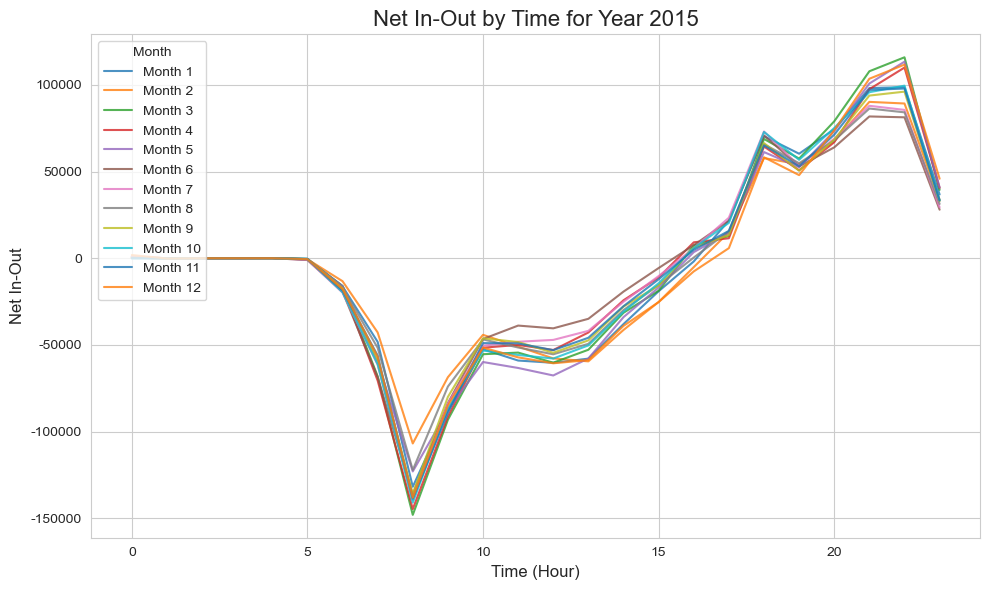

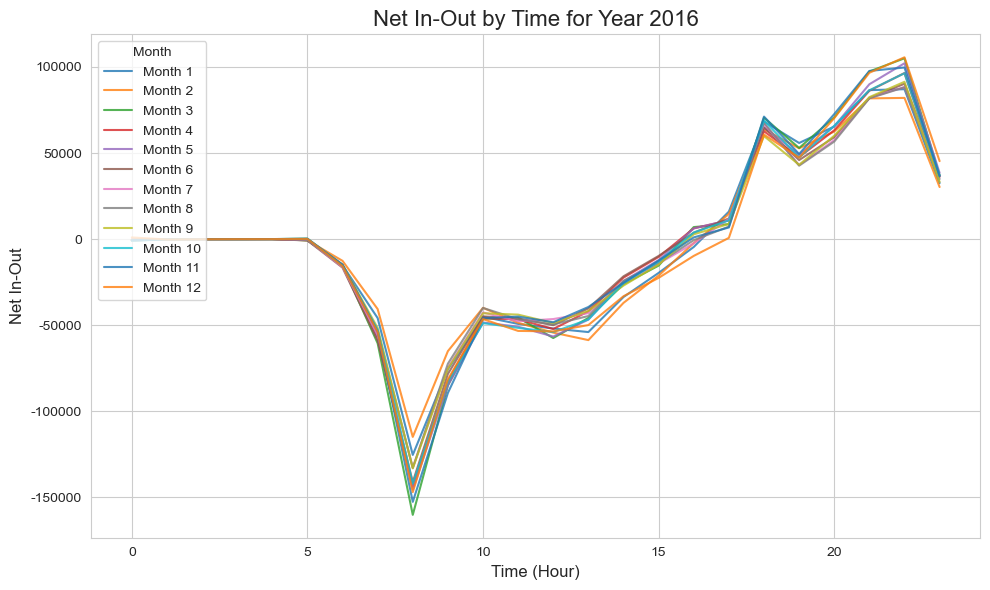

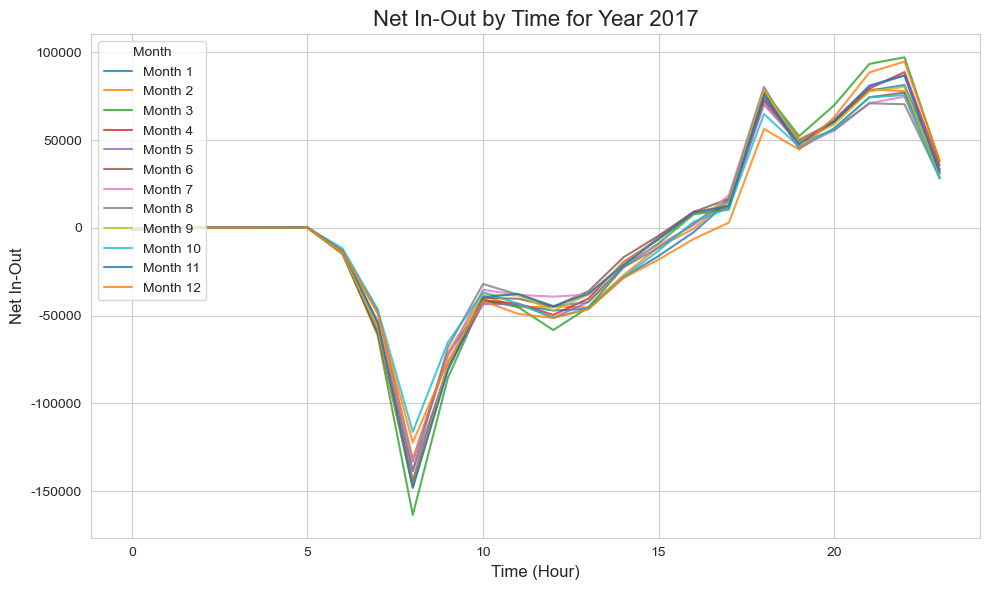

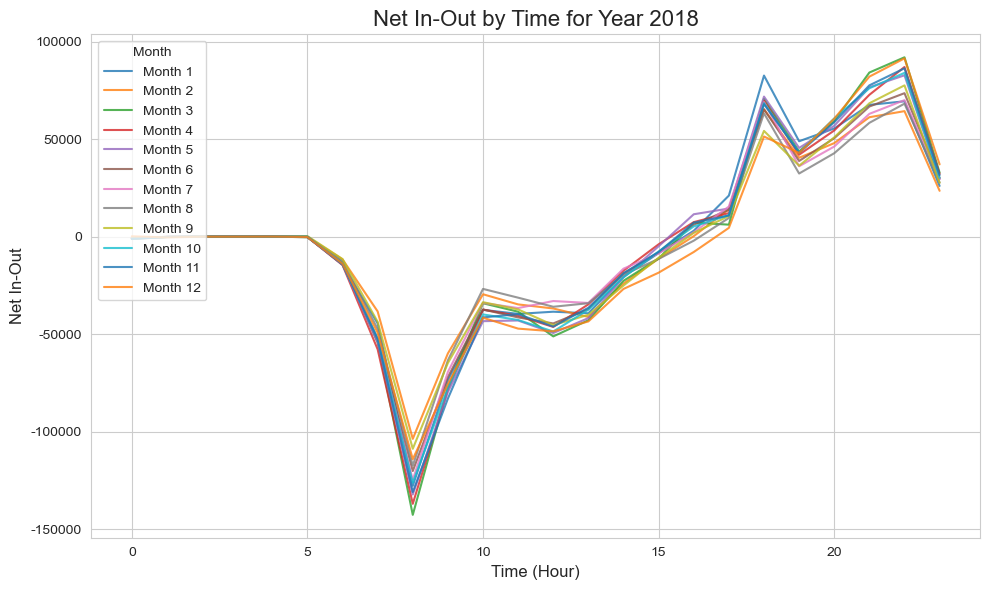

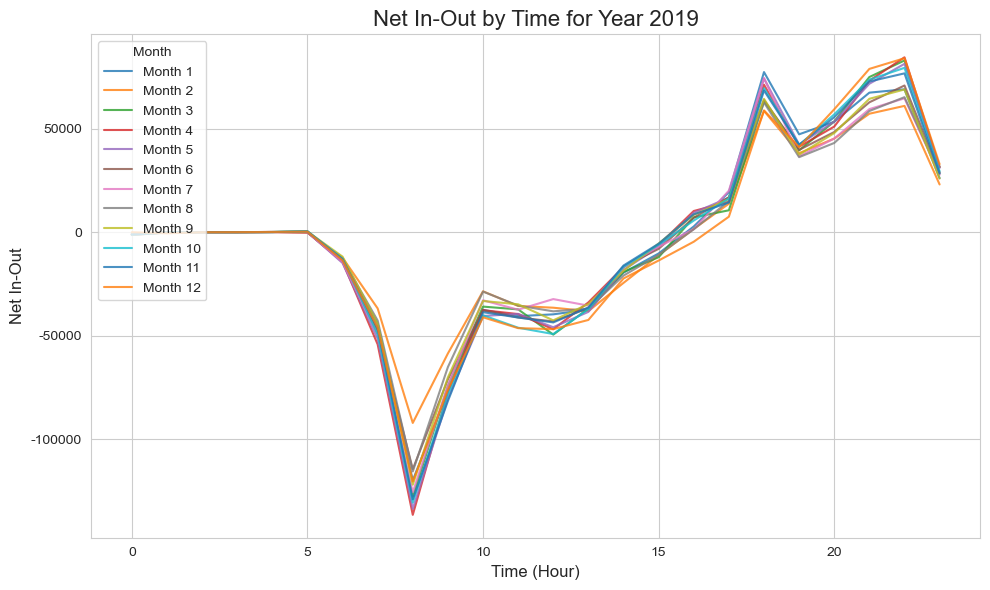

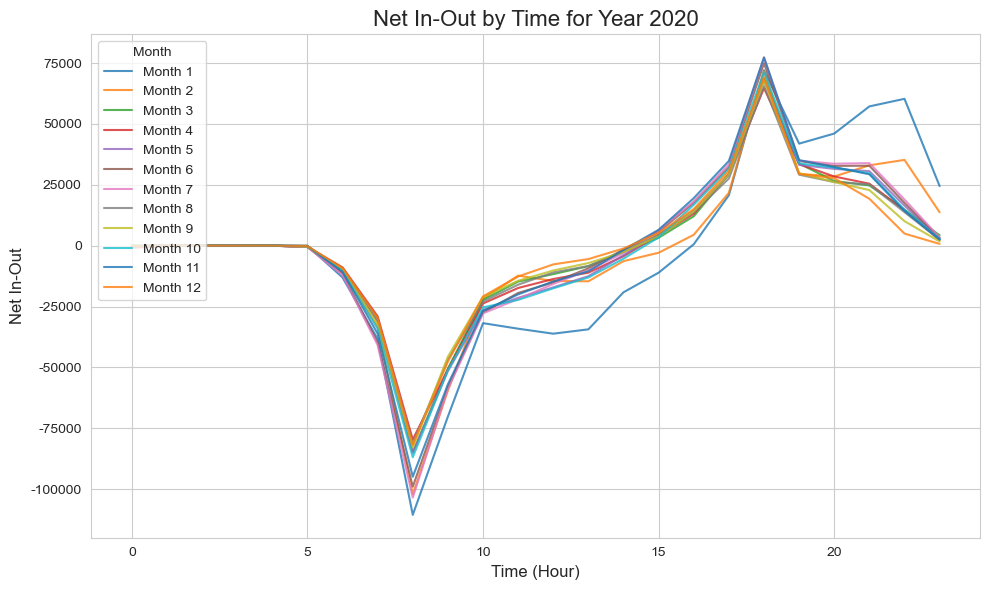

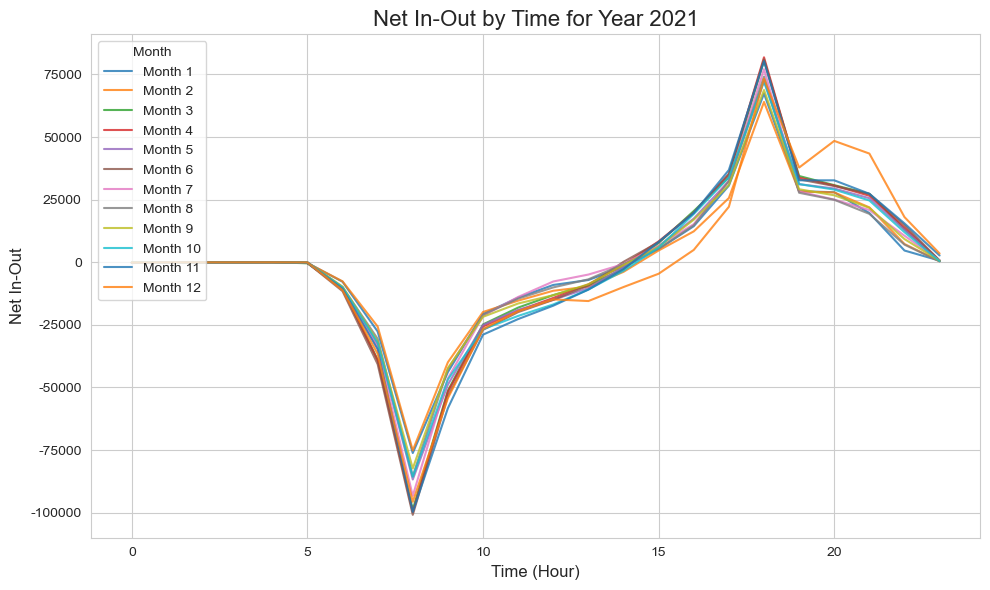

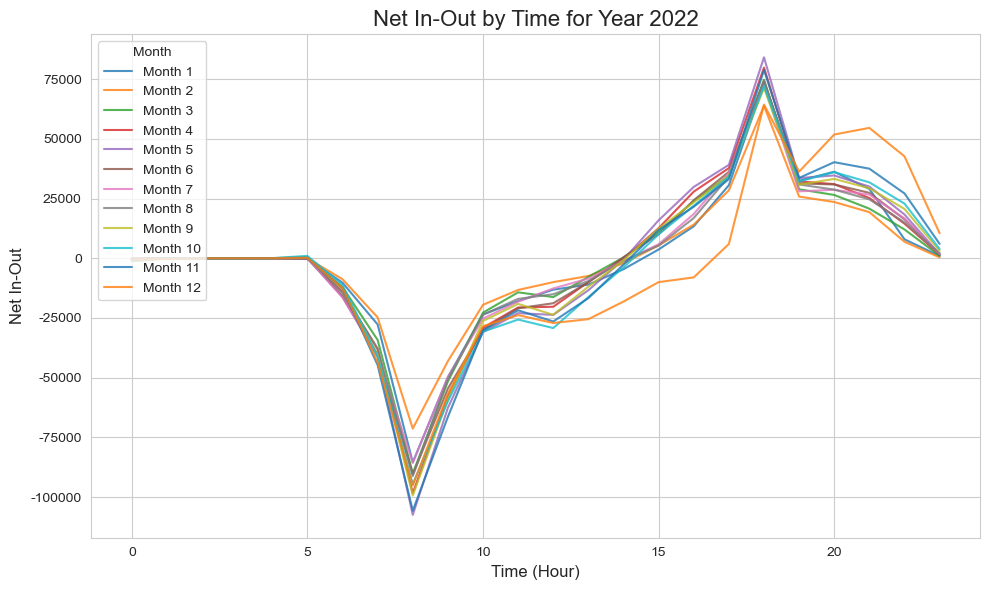

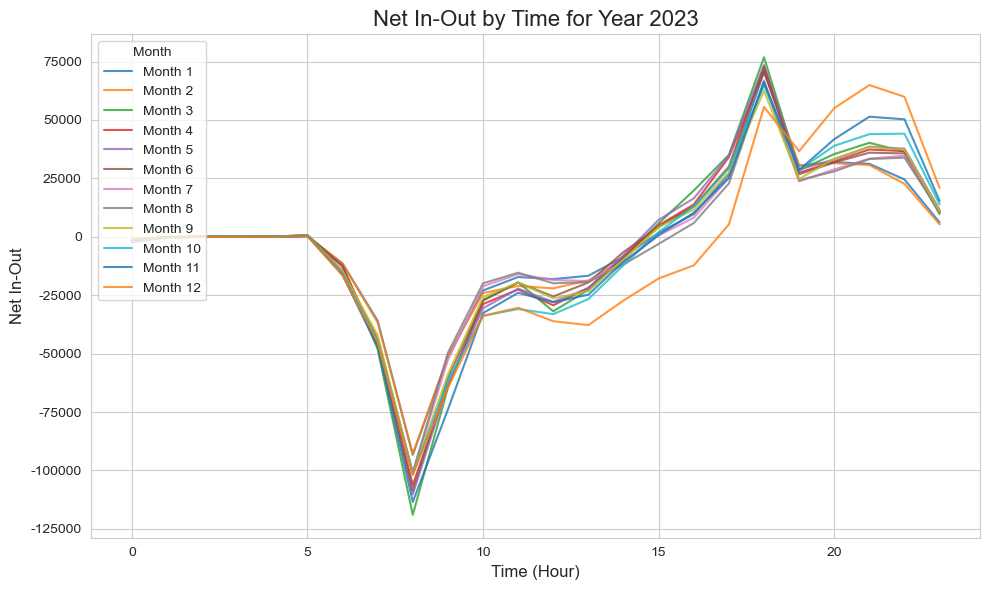

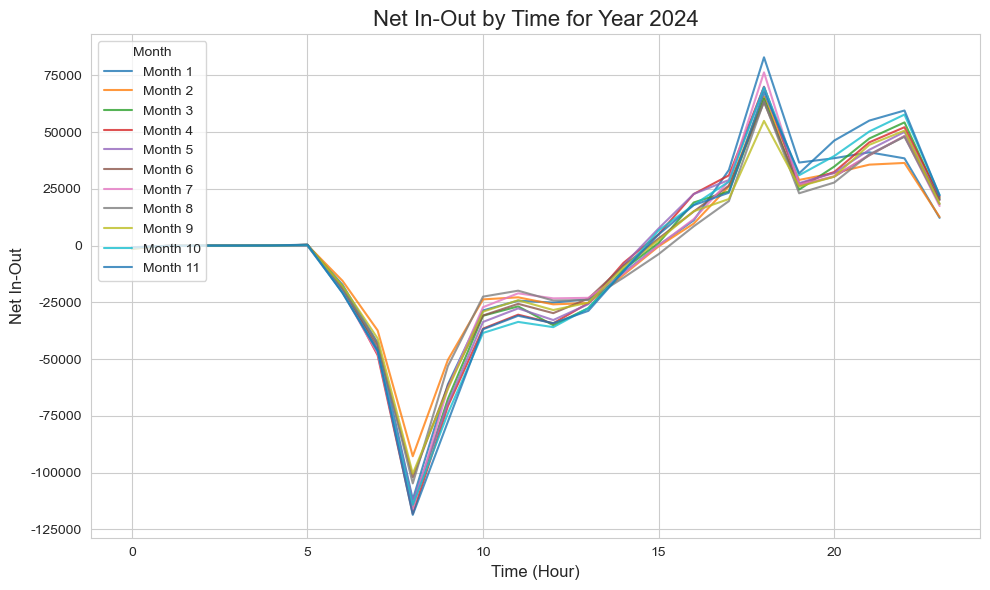

In [2343]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'time', 'month', and 'Net_in_out' are numeric and check for missing values
restructured_df_combine_pre_net_in_out['time'] = pd.to_numeric(restructured_df_combine_pre_net_in_out['time'], errors='coerce')
restructured_df_combine_pre_net_in_out['month'] = pd.to_numeric(restructured_df_combine_pre_net_in_out['month'], errors='coerce')
restructured_df_combine_pre_net_in_out['Net_in_out'] = pd.to_numeric(restructured_df_combine_pre_net_in_out['Net_in_out'], errors='coerce')

# Drop rows with NaN in key columns
restructured_df_combine_pre_net_in_out = restructured_df_combine_pre_net_in_out.dropna(subset=['time', 'month', 'Net_in_out'])

# Group the data
aggregated_data = (
    restructured_df_combine_pre_net_in_out
    .groupby(['year', 'month', 'time'], as_index=False)
    .agg({'Net_in_out': 'mean'})  # Aggregate 'Net_in_out' (e.g., mean)
)

# Ensure aggregated data is not empty
if aggregated_data.empty:
    print("Aggregated data is empty. Please check your preprocessing steps.")
else:
    # Set the plot style
    sns.set_style("whitegrid")

    # Get unique years
    years = aggregated_data['year'].unique()

    # Loop through each year to create separate plots
    for year in years:
        yearly_data = aggregated_data[aggregated_data['year'] == year]
        
        # Check if yearly data is not empty
        if yearly_data.empty:
            print(f"No data for year {year}. Skipping...")
            continue
        
        # Initialize the plot for the current year
        plt.figure(figsize=(10, 6))
        
        # Loop through each month and plot data
        for month in yearly_data['month'].unique():
            monthly_data = yearly_data[yearly_data['month'] == month]
            
            if not monthly_data.empty:
                plt.plot(
                    monthly_data['time'],
                    monthly_data['Net_in_out'],
                    label=f"Month {month}",
                    alpha=0.8
                )
        
        # Add labels, legend, and title
        plt.title(f"Net In-Out by Time for Year {year}", fontsize=16)
        plt.xlabel("Time (Hour)", fontsize=12)
        plt.ylabel("Net In-Out", fontsize=12)
        plt.legend(title="Month", loc='upper left', fontsize=10)
        
        # Adjust layout and show plot
        plt.tight_layout()
        plt.show()

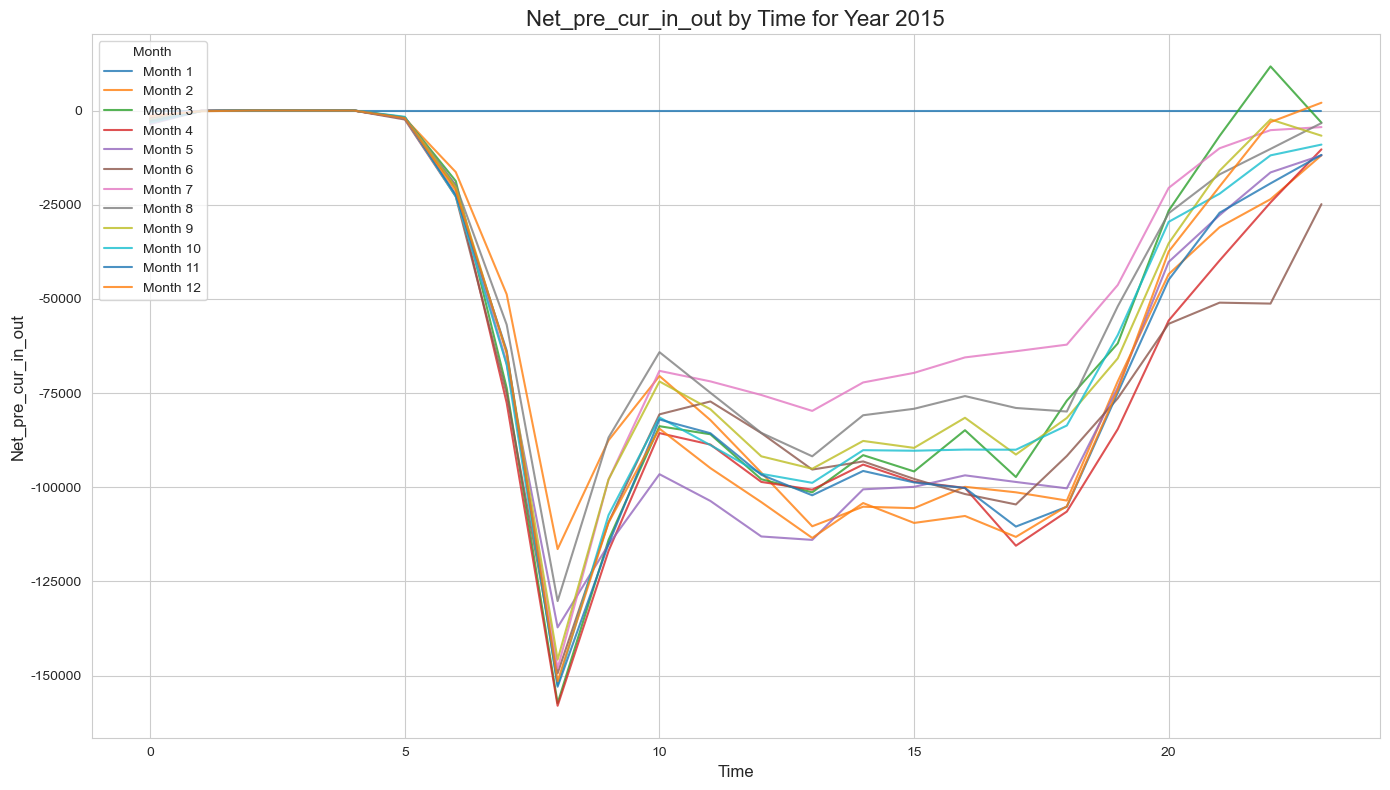

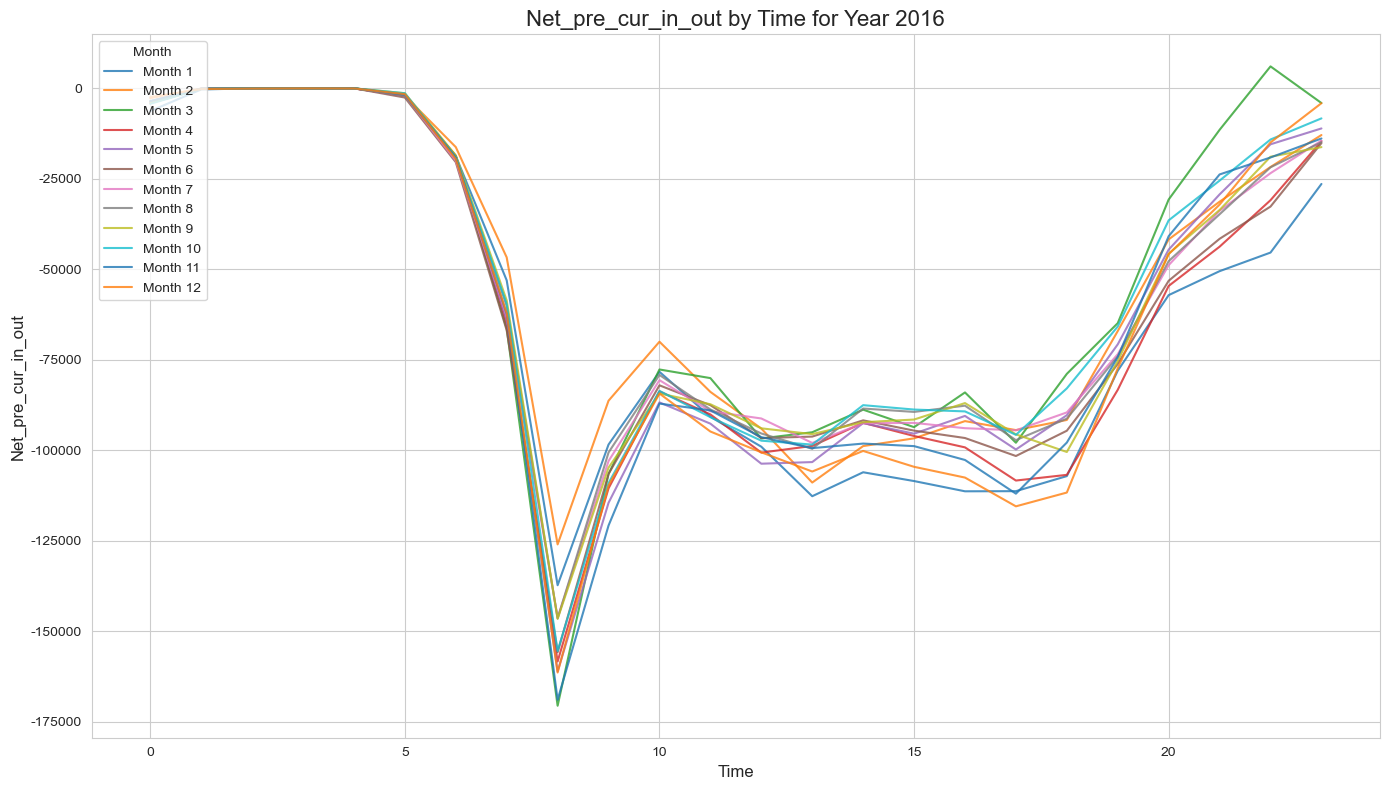

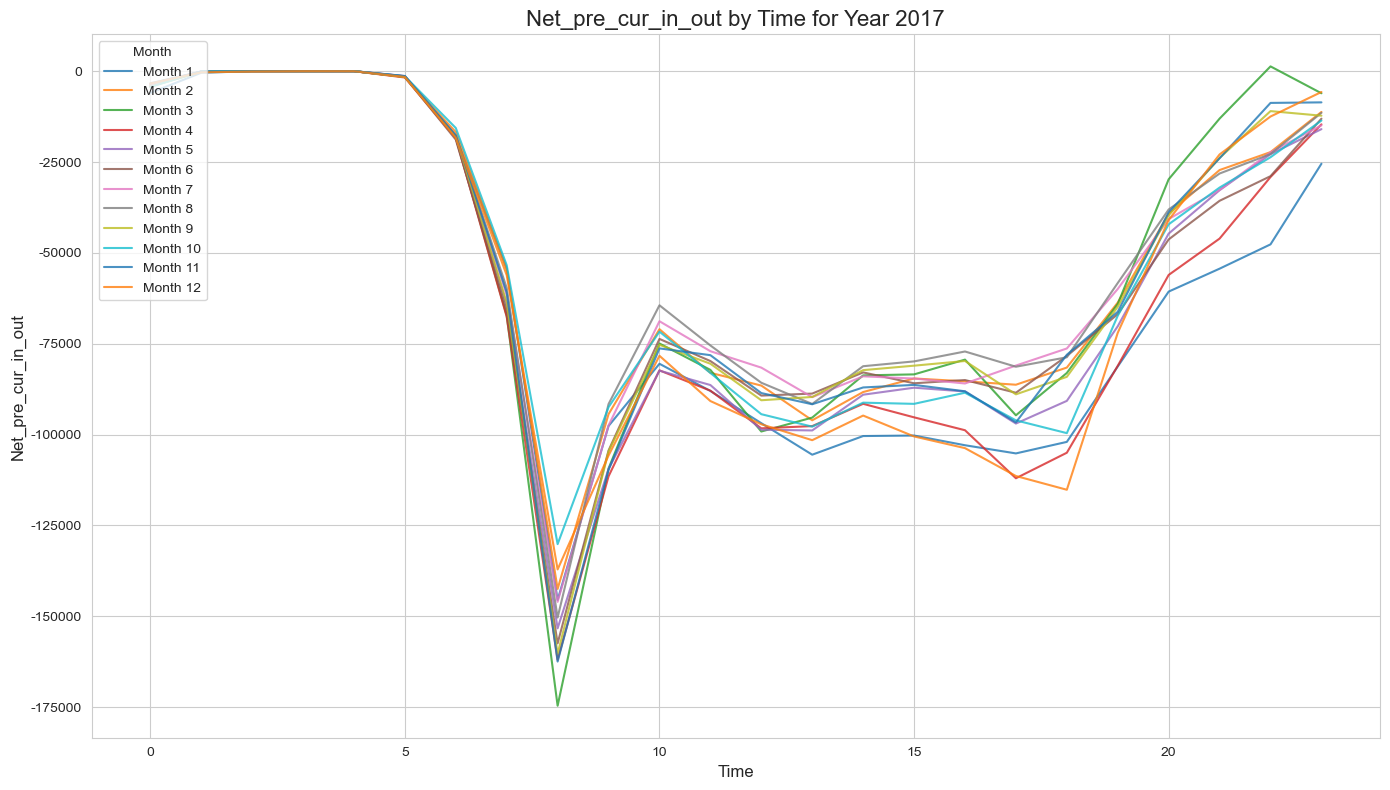

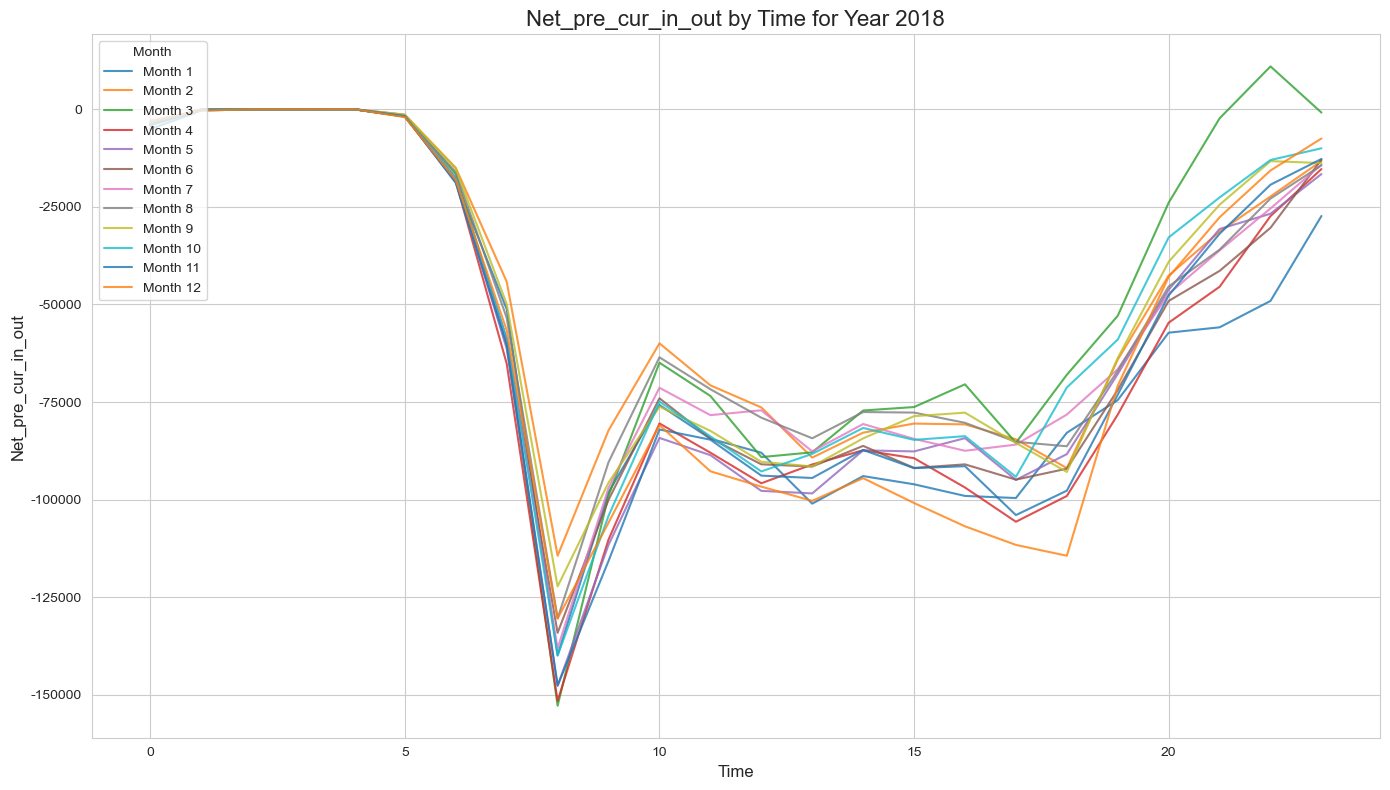

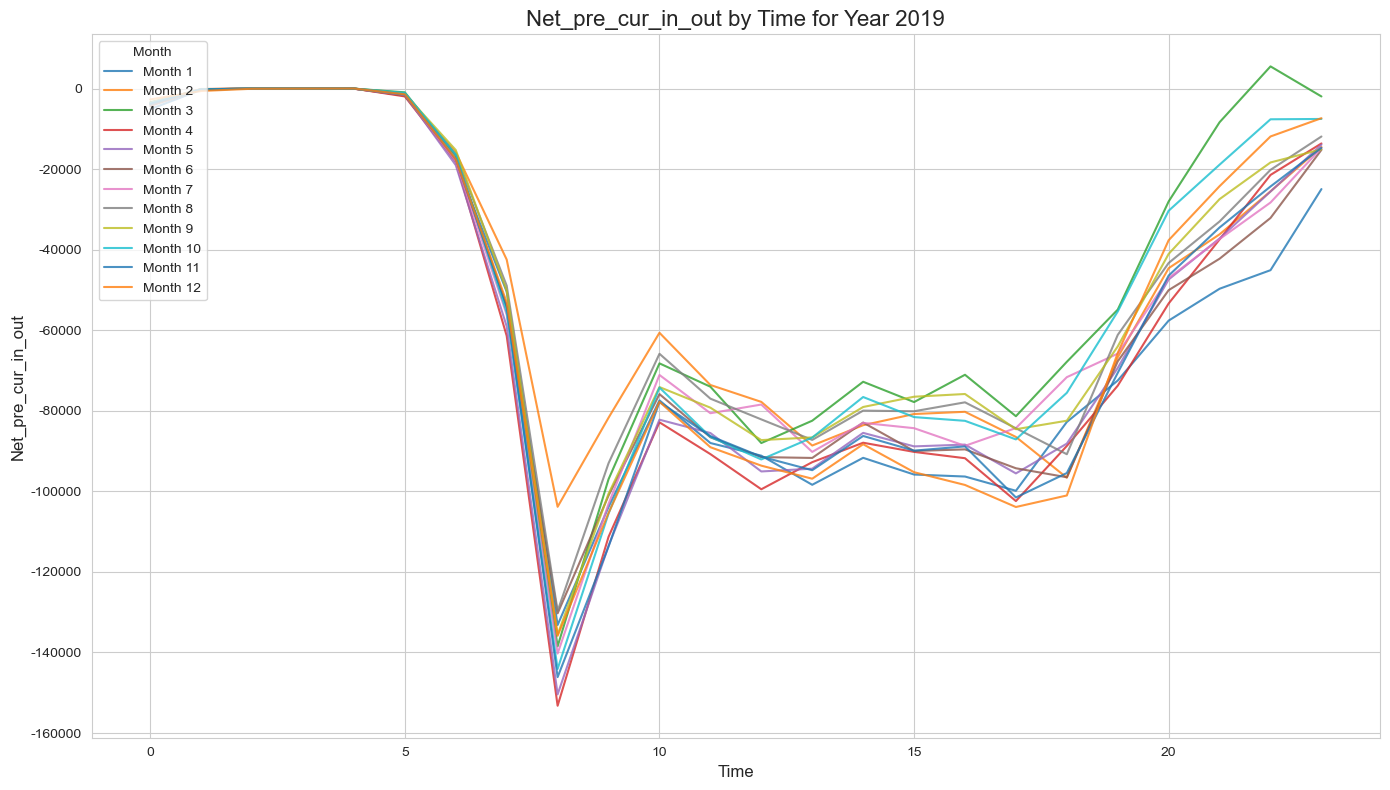

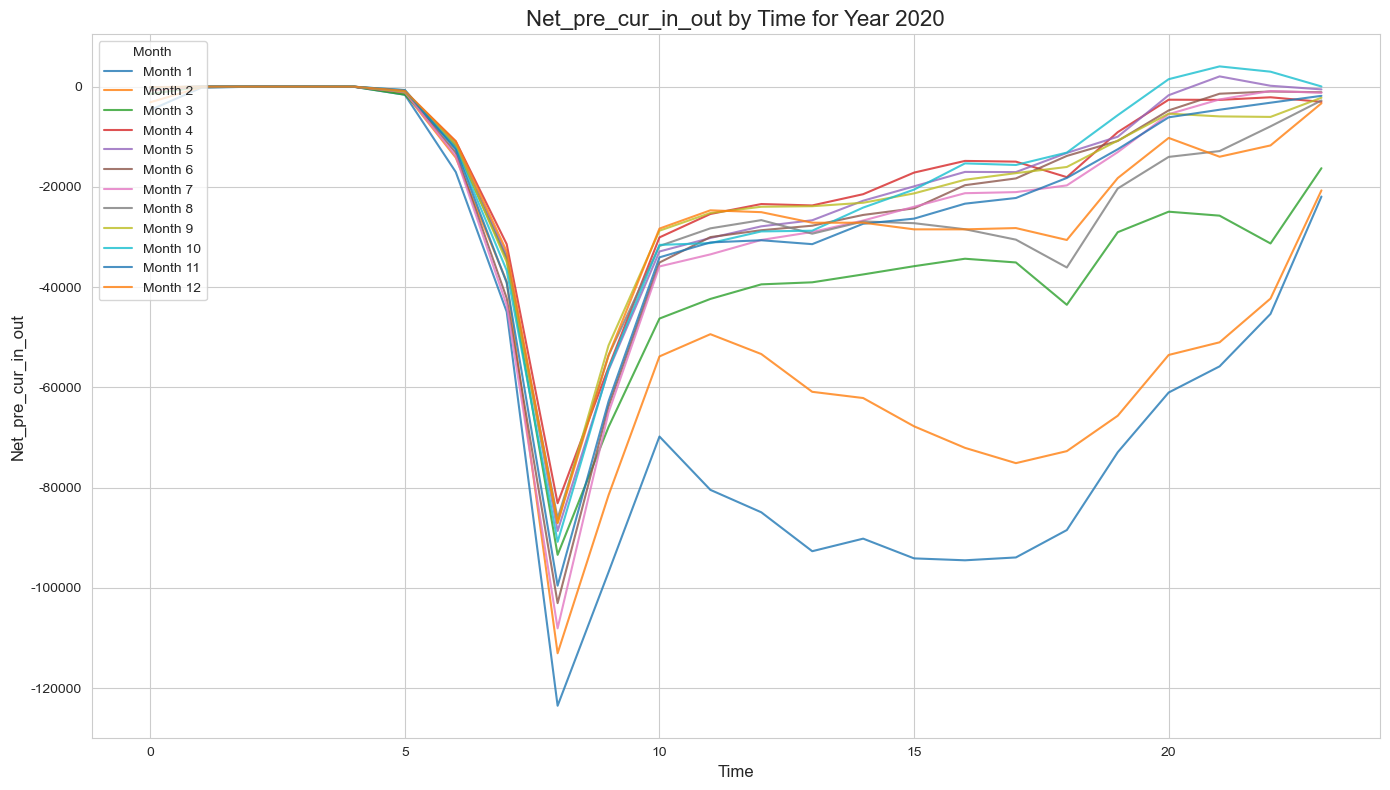

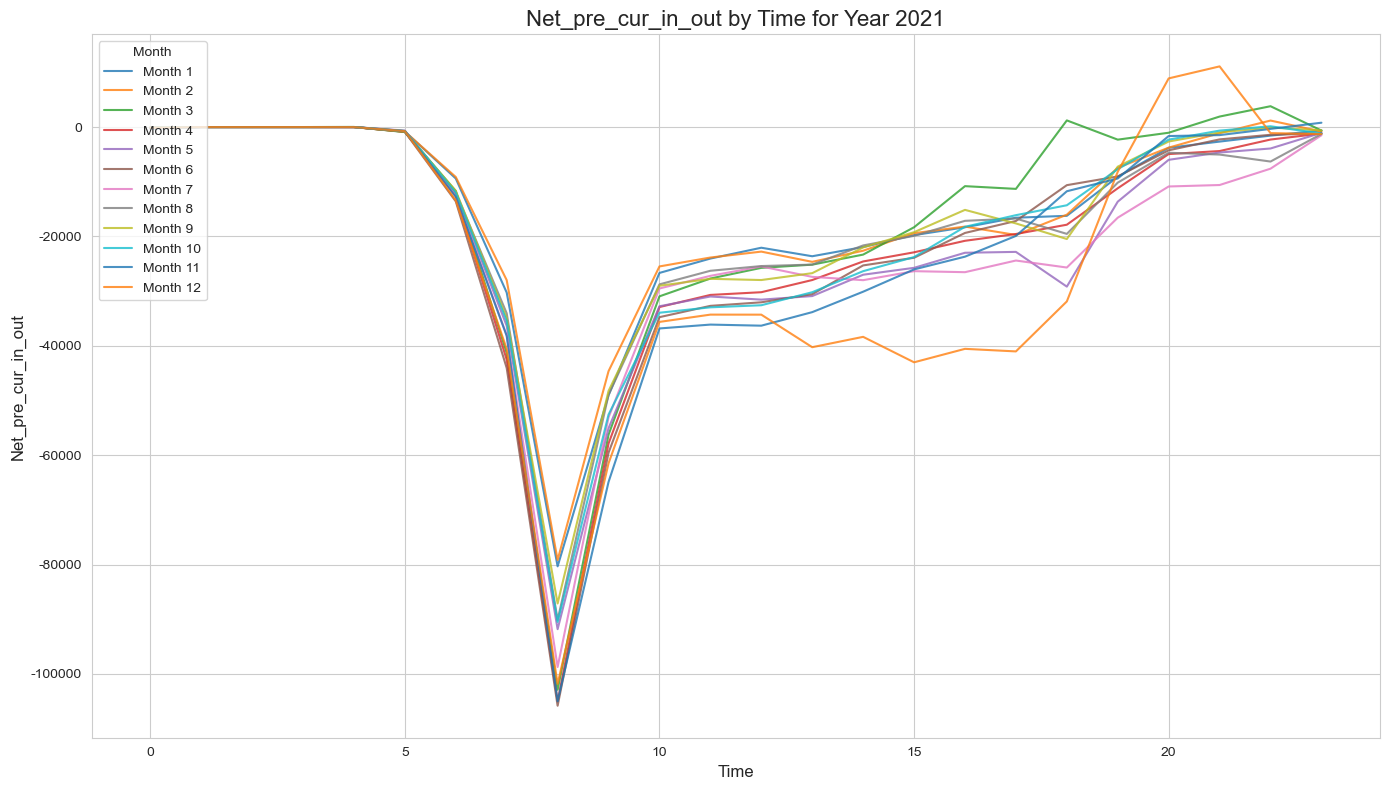

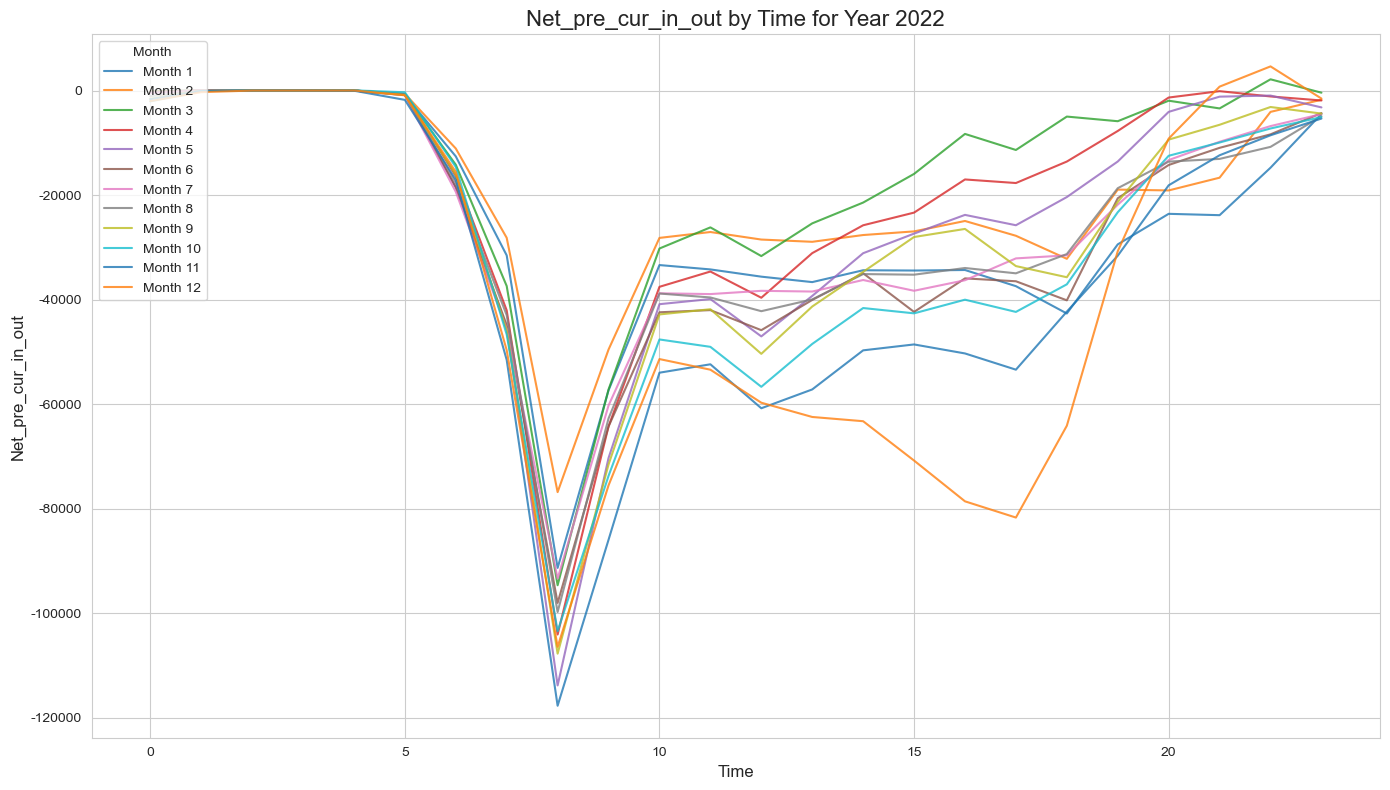

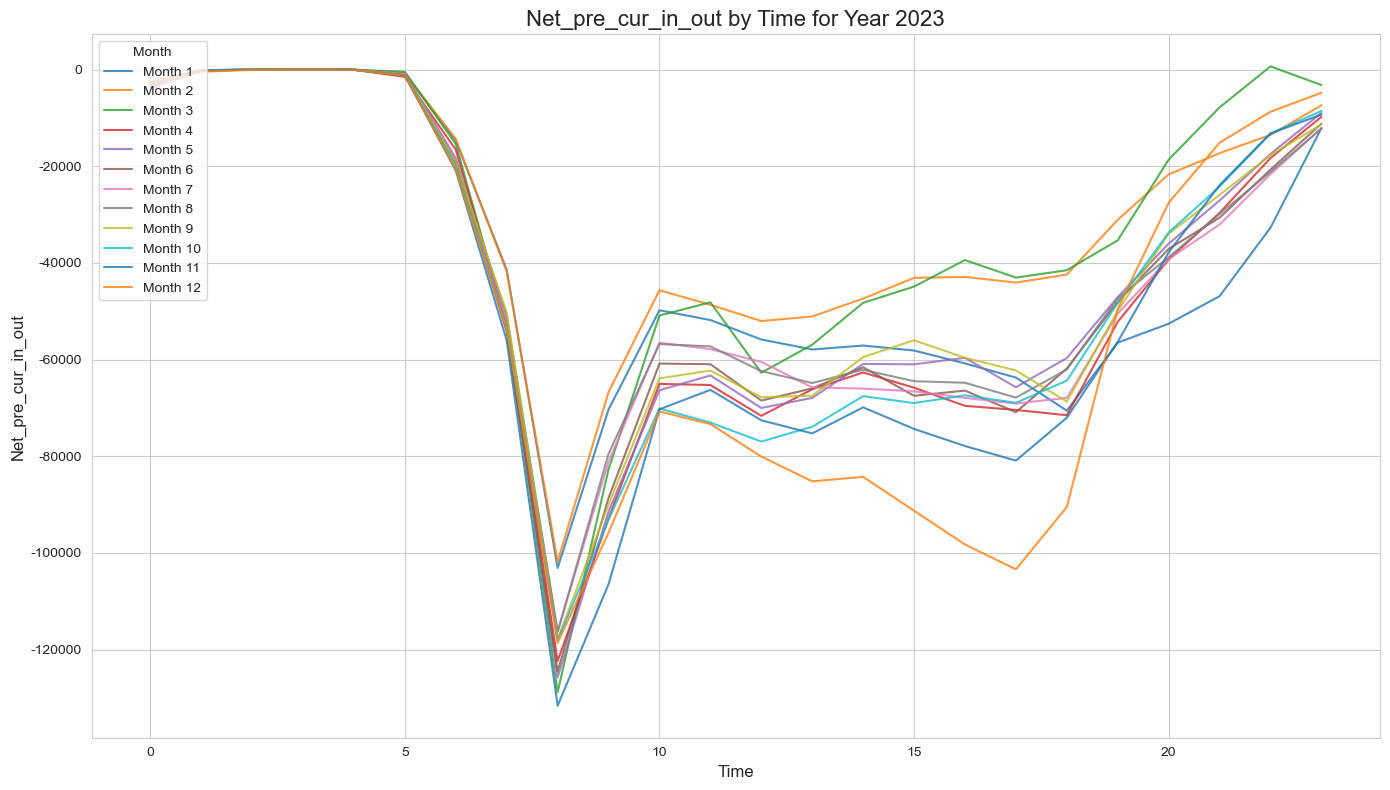

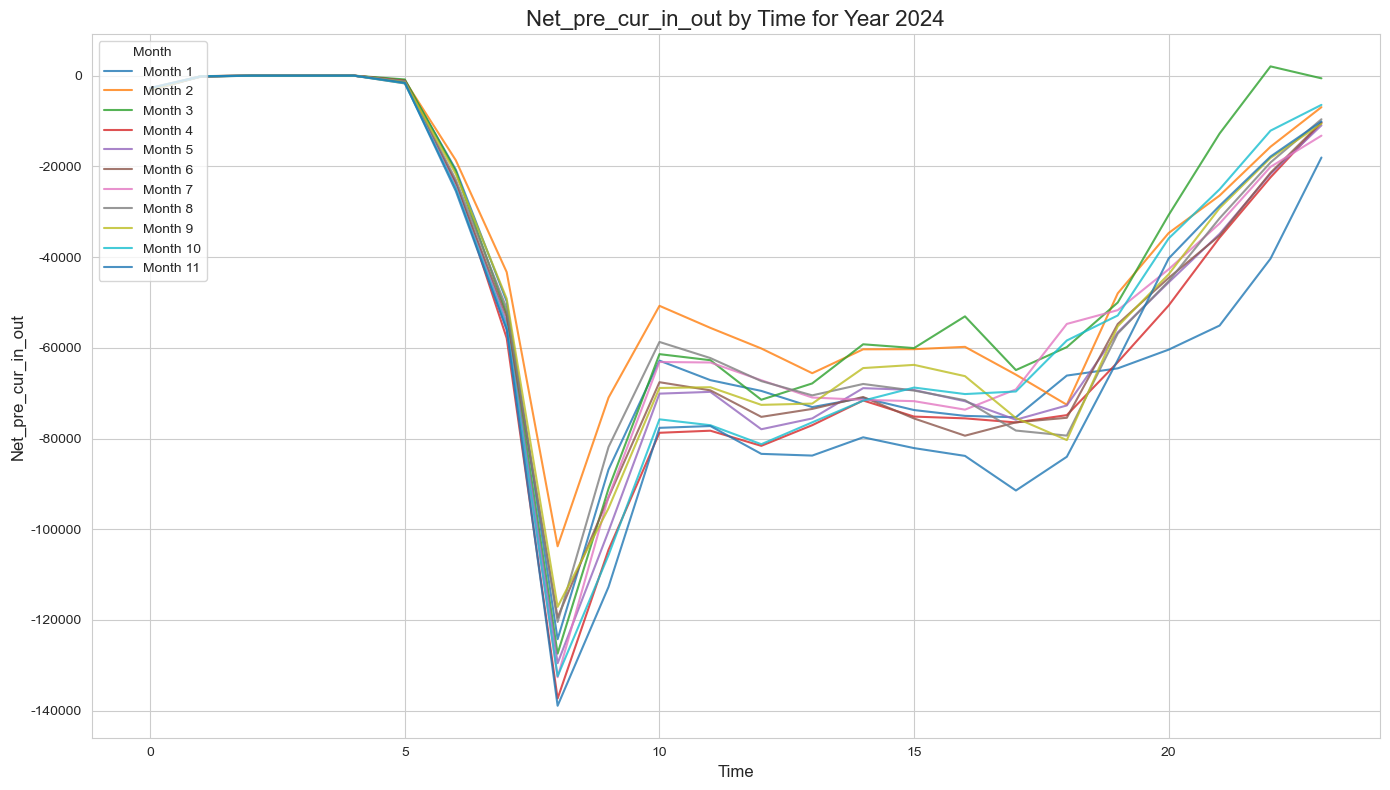

In [2344]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'time' and 'month' are numeric
restructured_df_combine_pre_net_in_out['time'] = restructured_df_combine_pre_net_in_out['time'].astype(int)
restructured_df_combine_pre_net_in_out['month'] = restructured_df_combine_pre_net_in_out['month'].astype(int)

# Group the data to ensure only one value per time per month
aggregated_data = (
    restructured_df_combine_pre_net_in_out
    .groupby(['year', 'month', 'time'], as_index=False)
    .agg({'Net_pre_cur_in_out': 'mean'})  # Aggregate 'Net_in_out' (e.g., mean or sum)
)

# Set the plot style
sns.set_style("whitegrid")

# Get unique years
years = aggregated_data['year'].unique()

# Loop through each year to create separate plots
for year in years:
    yearly_data = aggregated_data[aggregated_data['year'] == year]
    
    # Initialize the plot for the current year
    plt.figure(figsize=(14, 8))
    
    # Loop through each month and plot data
    for month in yearly_data['month'].unique():
        monthly_data = yearly_data[yearly_data['month'] == month]
        plt.plot(
            monthly_data['time'],
            monthly_data['Net_pre_cur_in_out'],
            label=f"Month {month}",
            alpha=0.8
        )
    
    # Add labels, legend, and title
    plt.title(f"Net_pre_cur_in_out by Time for Year {year}", fontsize=16)
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Net_pre_cur_in_out", fontsize=12)
    plt.legend(title="Month", loc='upper left', fontsize=10)
    
    # Adjust layout and show plot
    plt.tight_layout()
    plt.show()

In [2345]:
restructured_df_combine_pre_net_in_out

,in,ratio_in,datetime,year,month,time,out,ratio_out,in_CMR,ratio_in_CMR,in_HH,ratio_in_HH,Net_in_out,prev_month,prev_Net_in_out,Net_pre_cur_in_out,Net_pre_cur_in_out(%)
0,44,0.00004,20241104,2024,11,4,0,0.00000,72,0.00008,26,0.00003,44,20241004,33.0,11.0,0.333333
1,1892,0.00164,20241105,2024,11,5,1466,0.00119,3510,0.00371,1519,0.00179,426,20241005,1978.0,-1552.0,-0.784631
2,4132,0.00358,20241106,2024,11,6,25061,0.02036,5864,0.00619,3503,0.00412,-20929,20241006,4503.0,-25432.0,-5.647790
3,9020,0.00782,20241107,2024,11,7,55355,0.04498,12941,0.01367,5712,0.00672,-46335,20241007,9685.0,-56020.0,-5.784202
4,18160,0.01575,20241108,2024,11,8,136749,0.11112,24046,0.02539,9978,0.01174,-118589,20241008,20322.0,-138911.0,-6.835498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2851,45613,0.03734,20150123,2015,1,23,8871,0.00665,30679,0.03065,9133,0.01036,36742,20141223,0.0,0.0,0.000000
2852,2971,0.00243,20150100,2015,1,0,2215,0.00166,5425,0.00542,1156,0.00131,756,20141200,0.0,0.0,0.000000
2853,3,0.00000,20150101,2015,1,1,82,0.00006,1,0.00000,0,0.00000,-79,20141201,0.0,0.0,0.000000
2854,0,0.00000,20150102,2015,1,2,0,0.00000,0,0.00000,0,0.00000,0,20141202,0.0,0.0,0.000000


In [2346]:
restructured_df_combine_pre_net_in_out[(restructured_df_combine_pre_net_in_out["month"] == 1) ]

,in,ratio_in,datetime,year,month,time,out,ratio_out,in_CMR,ratio_in_CMR,in_HH,ratio_in_HH,Net_in_out,prev_month,prev_Net_in_out,Net_pre_cur_in_out,Net_pre_cur_in_out(%)
240,22,0.00003,20240104,2024,1,4,0,0.00000,80,0.00010,46,0.00006,22,20231204,31.0,-9.0,-0.290323
241,1299,0.00151,20240105,2024,1,5,1051,0.00115,3236,0.00400,1219,0.00163,248,20231205,1272.0,-1024.0,-0.805031
242,3117,0.00362,20240106,2024,1,6,20354,0.02224,5340,0.00660,2897,0.00386,-17237,20231206,3468.0,-20705.0,-5.970300
243,5943,0.00689,20240107,2024,1,7,48990,0.05353,10606,0.01311,4746,0.00633,-43047,20231207,6721.0,-49768.0,-7.404850
244,10975,0.01273,20240108,2024,1,8,122758,0.13413,17896,0.02212,8029,0.01070,-111783,20231208,12451.0,-124234.0,-9.977833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2851,45613,0.03734,20150123,2015,1,23,8871,0.00665,30679,0.03065,9133,0.01036,36742,20141223,0.0,0.0,0.000000
2852,2971,0.00243,20150100,2015,1,0,2215,0.00166,5425,0.00542,1156,0.00131,756,20141200,0.0,0.0,0.000000
2853,3,0.00000,20150101,2015,1,1,82,0.00006,1,0.00000,0,0.00000,-79,20141201,0.0,0.0,0.000000
2854,0,0.00000,20150102,2015,1,2,0,0.00000,0,0.00000,0,0.00000,0,20141202,0.0,0.0,0.000000


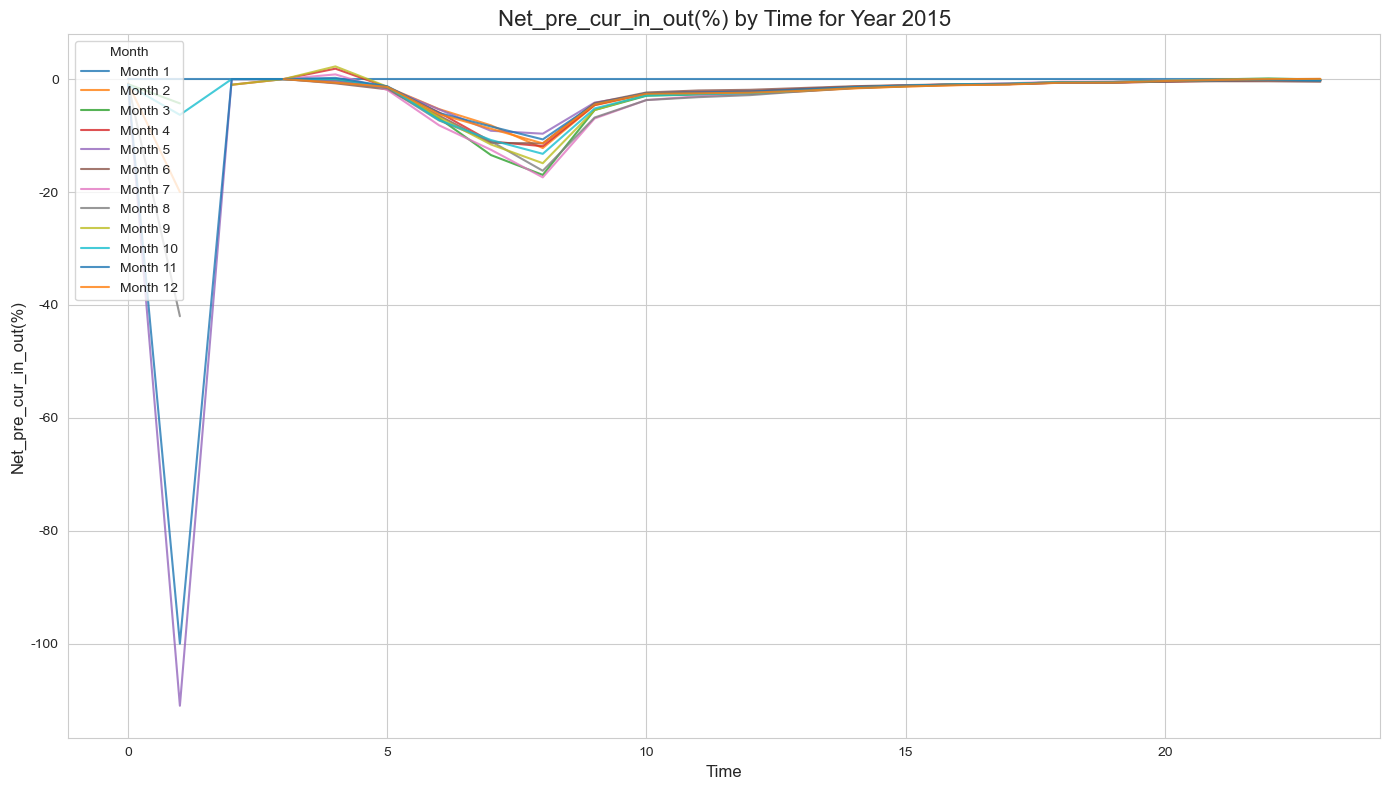

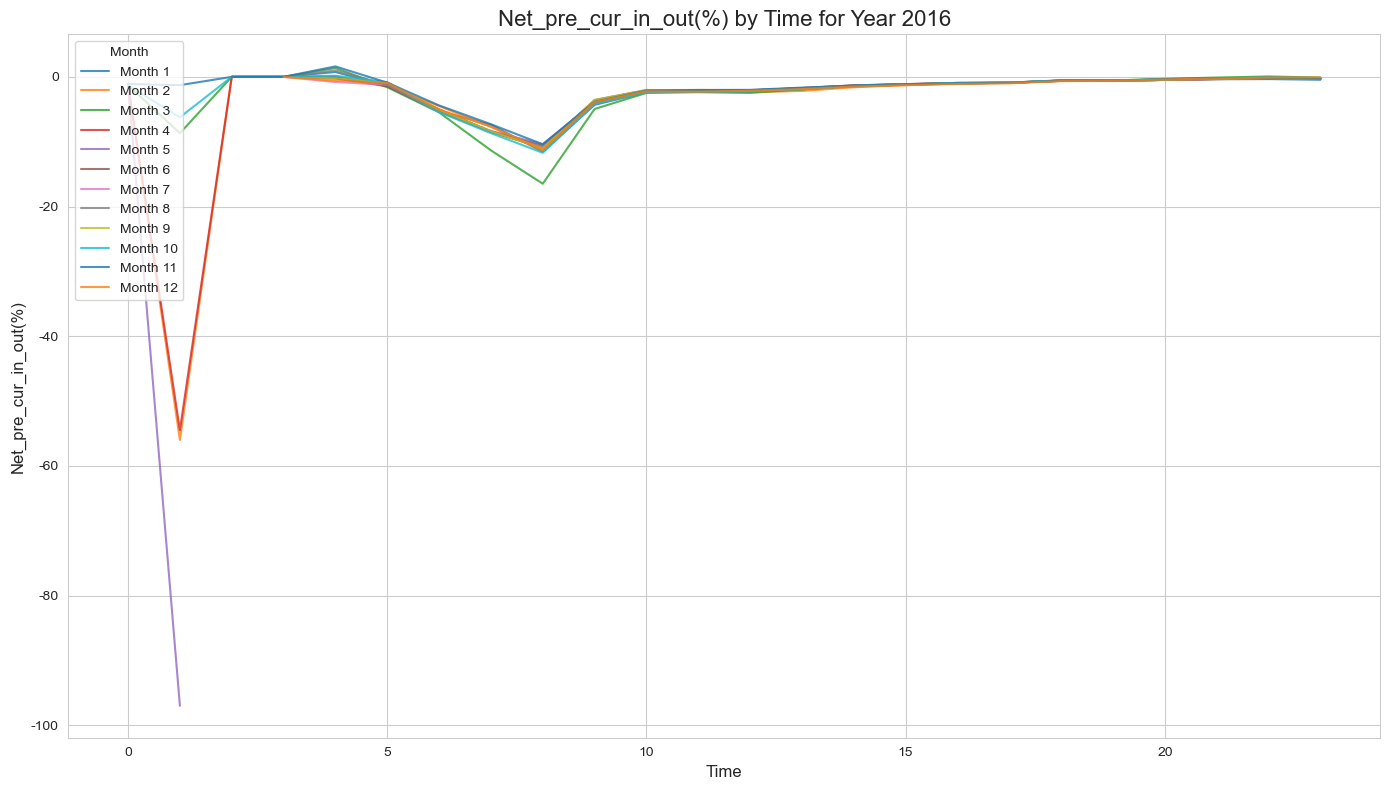

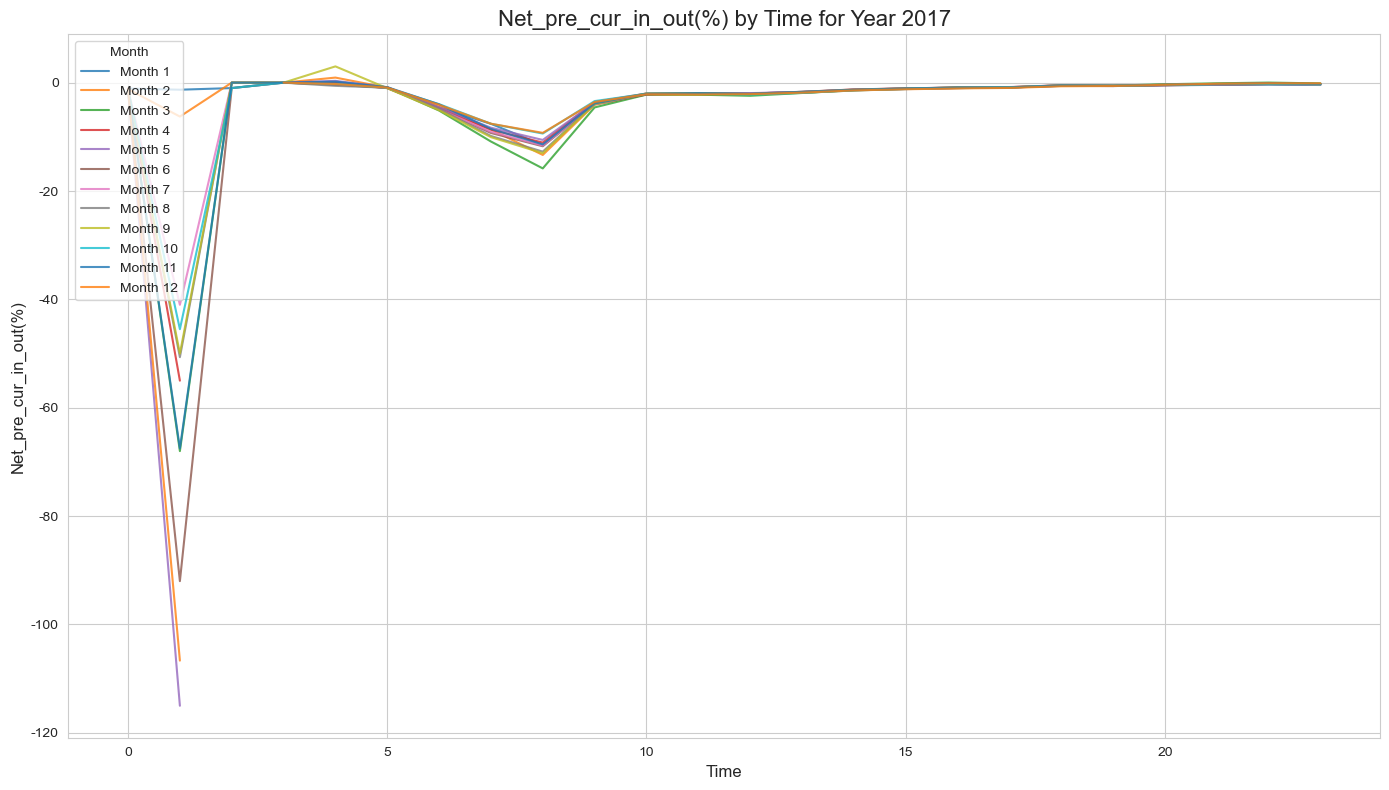

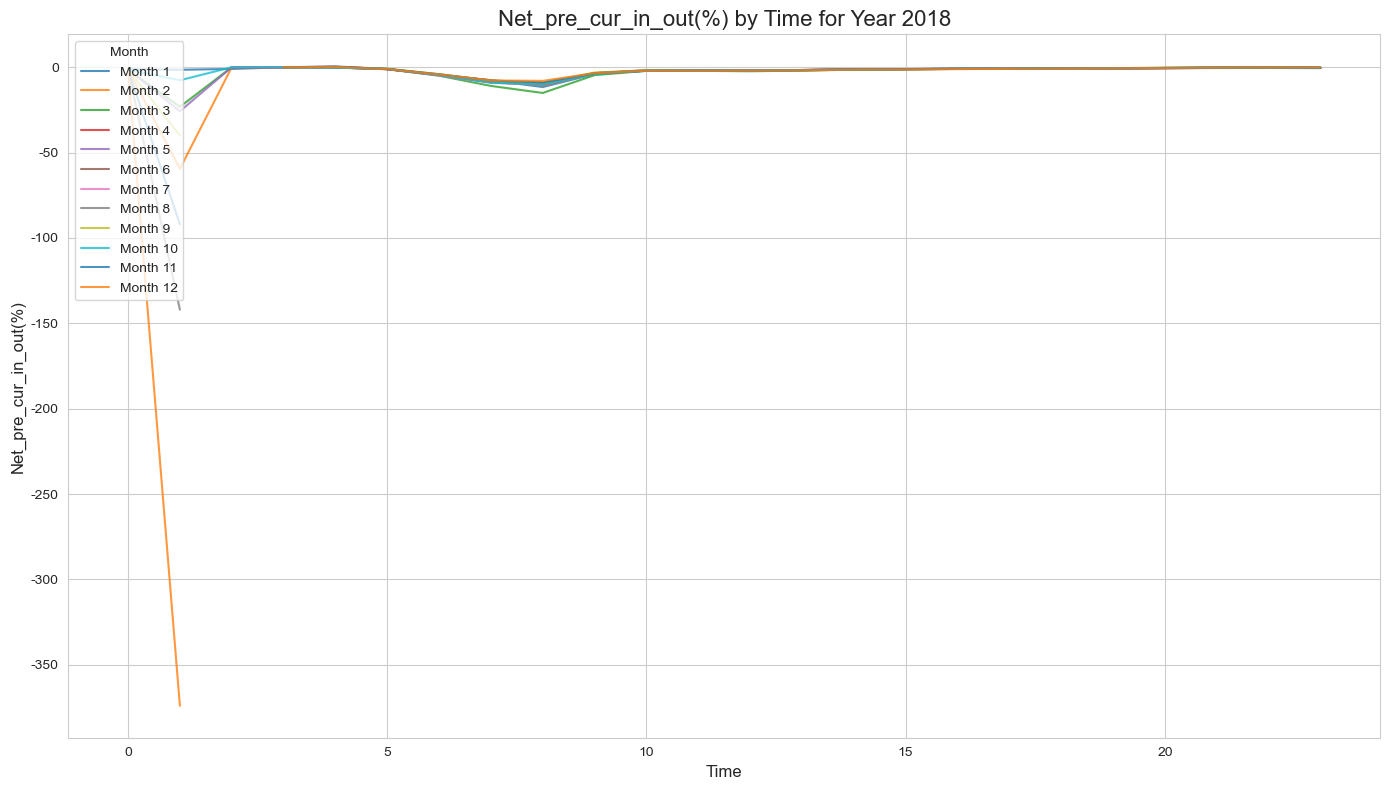

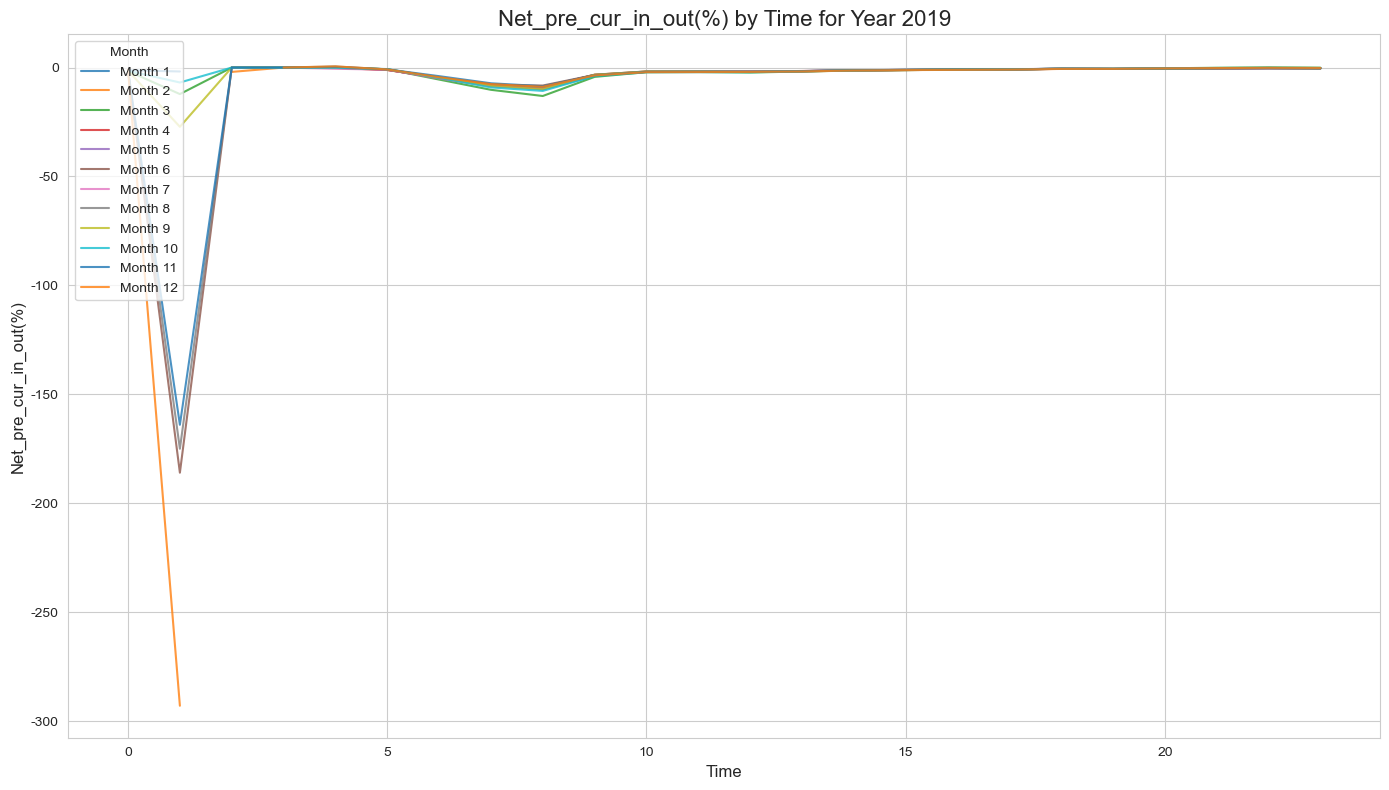

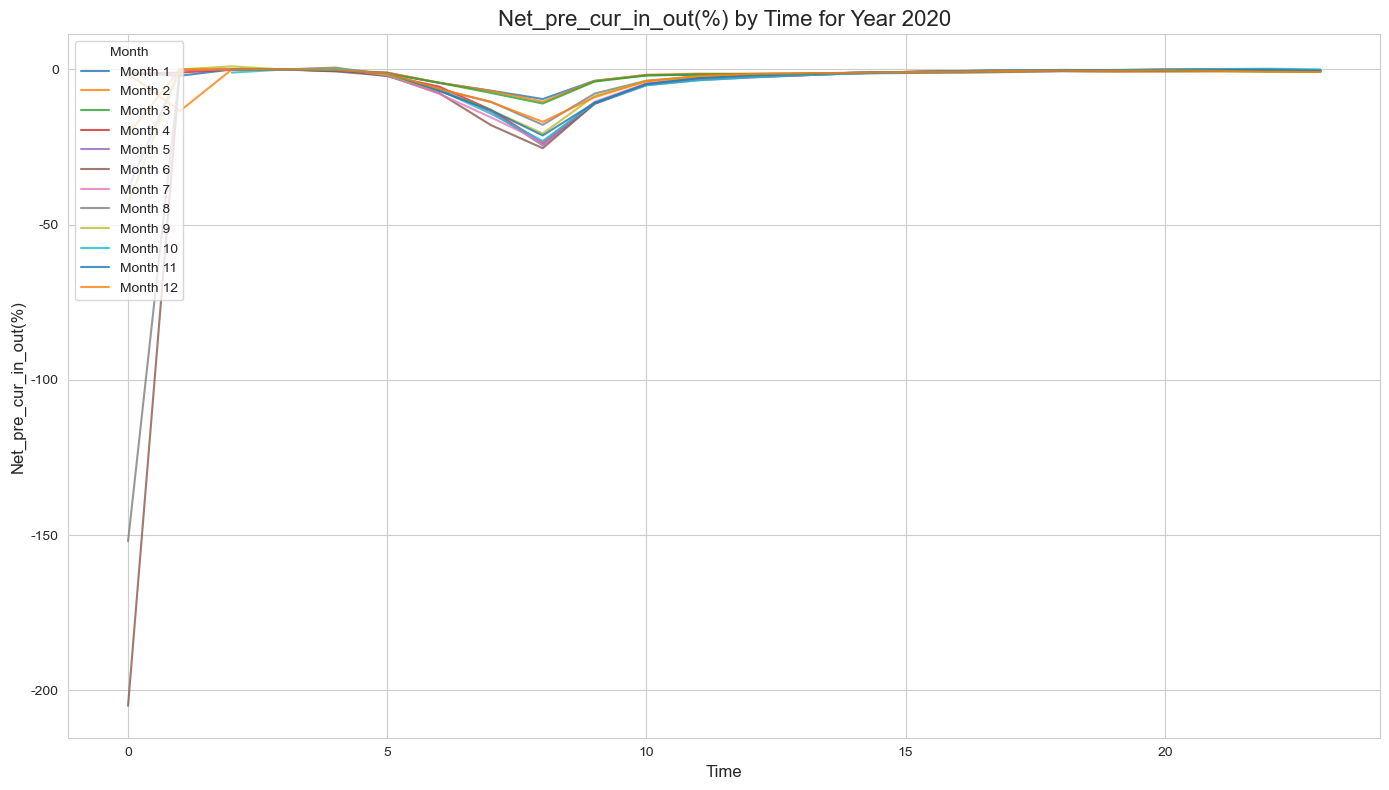

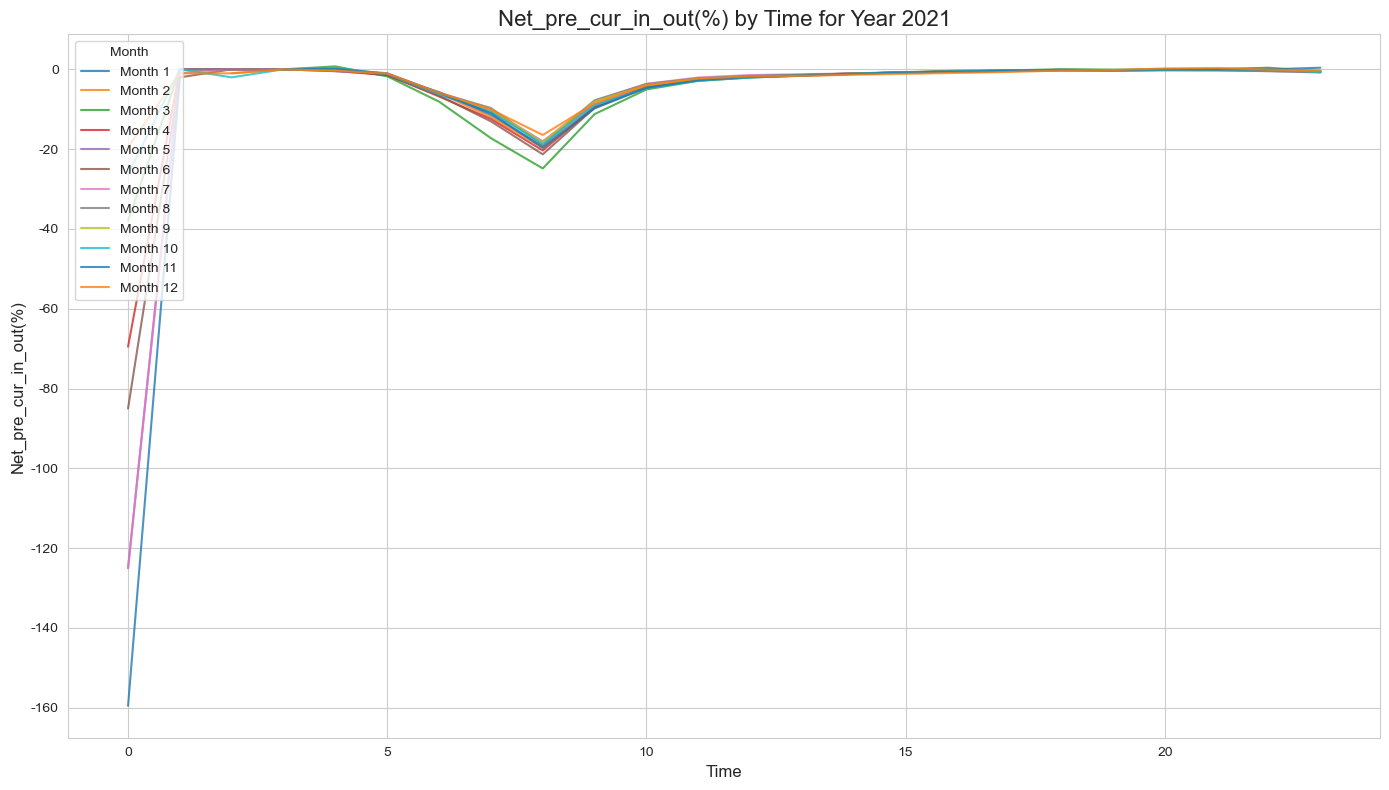

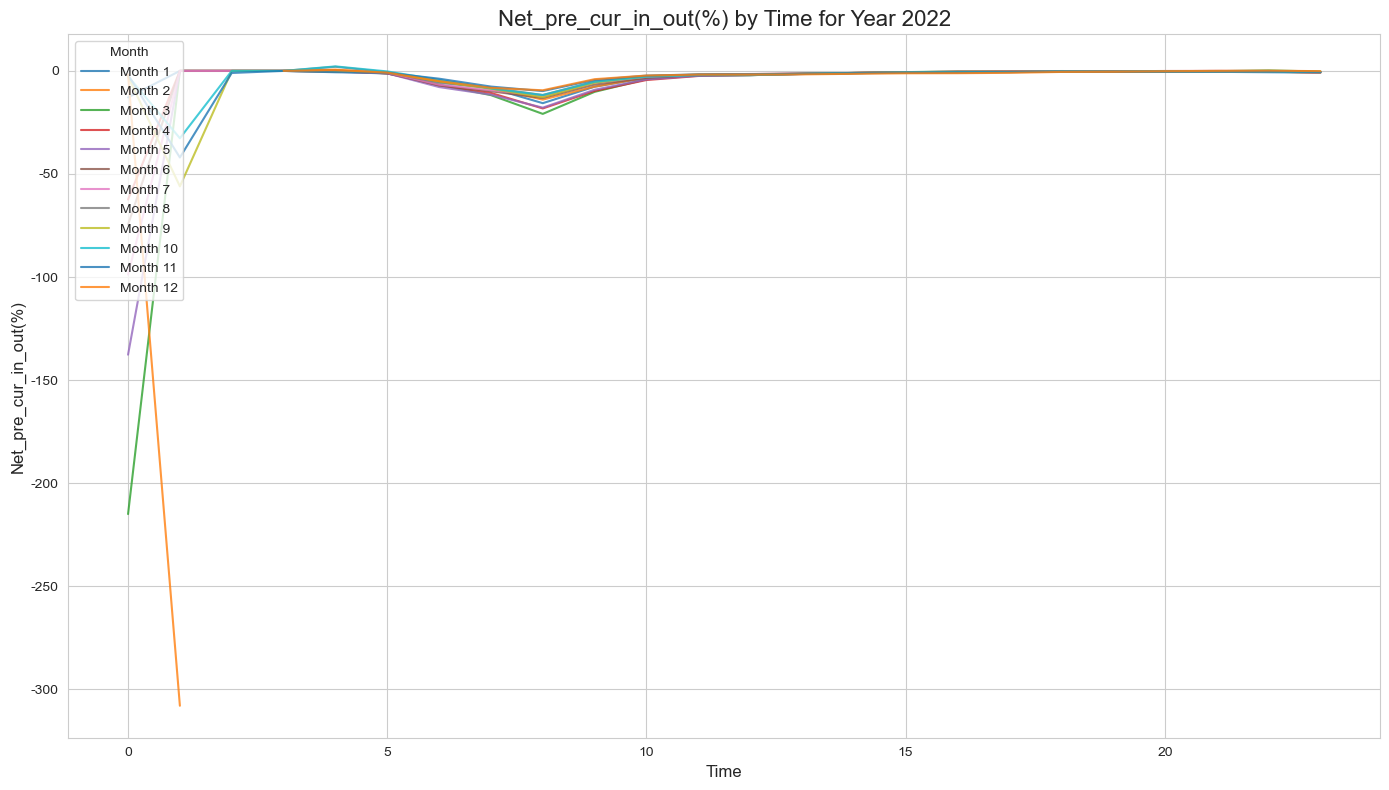

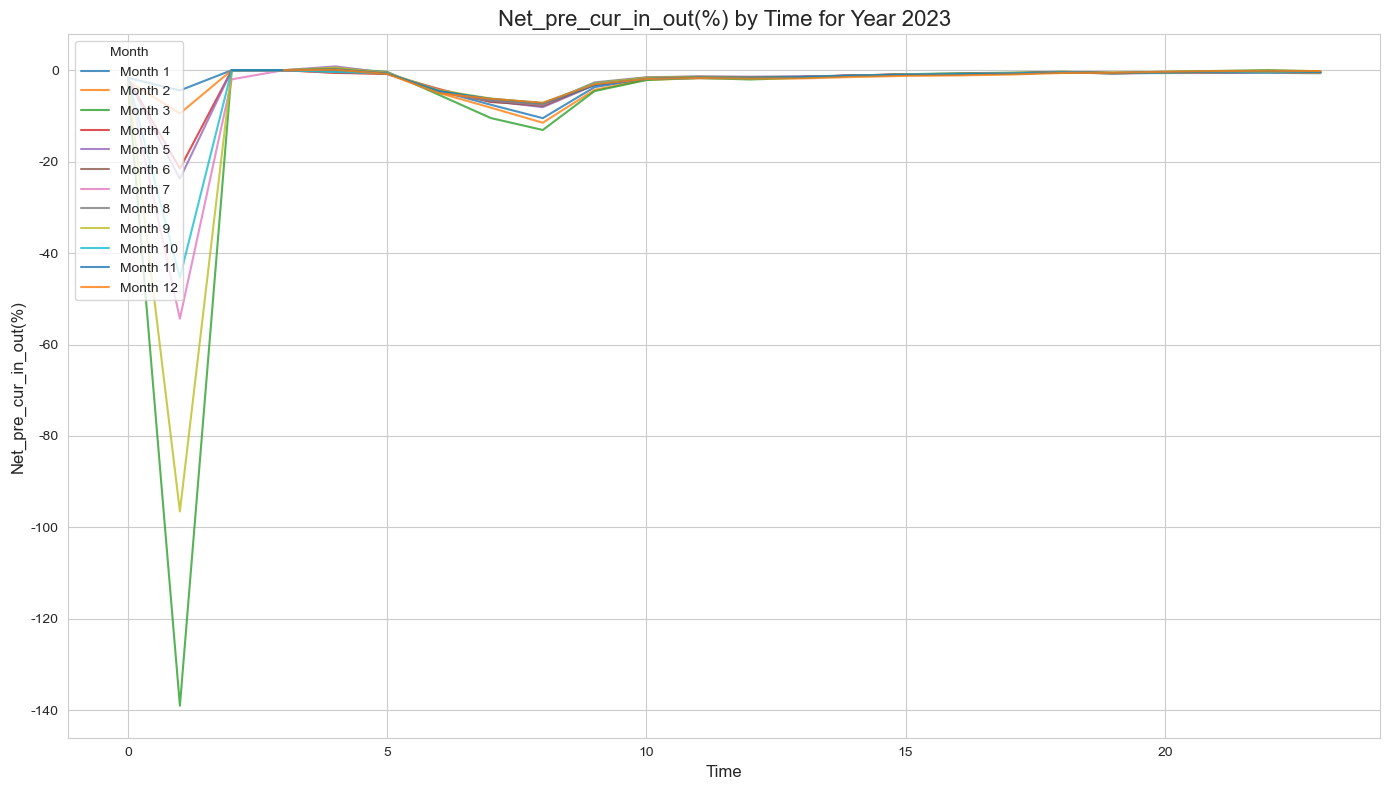

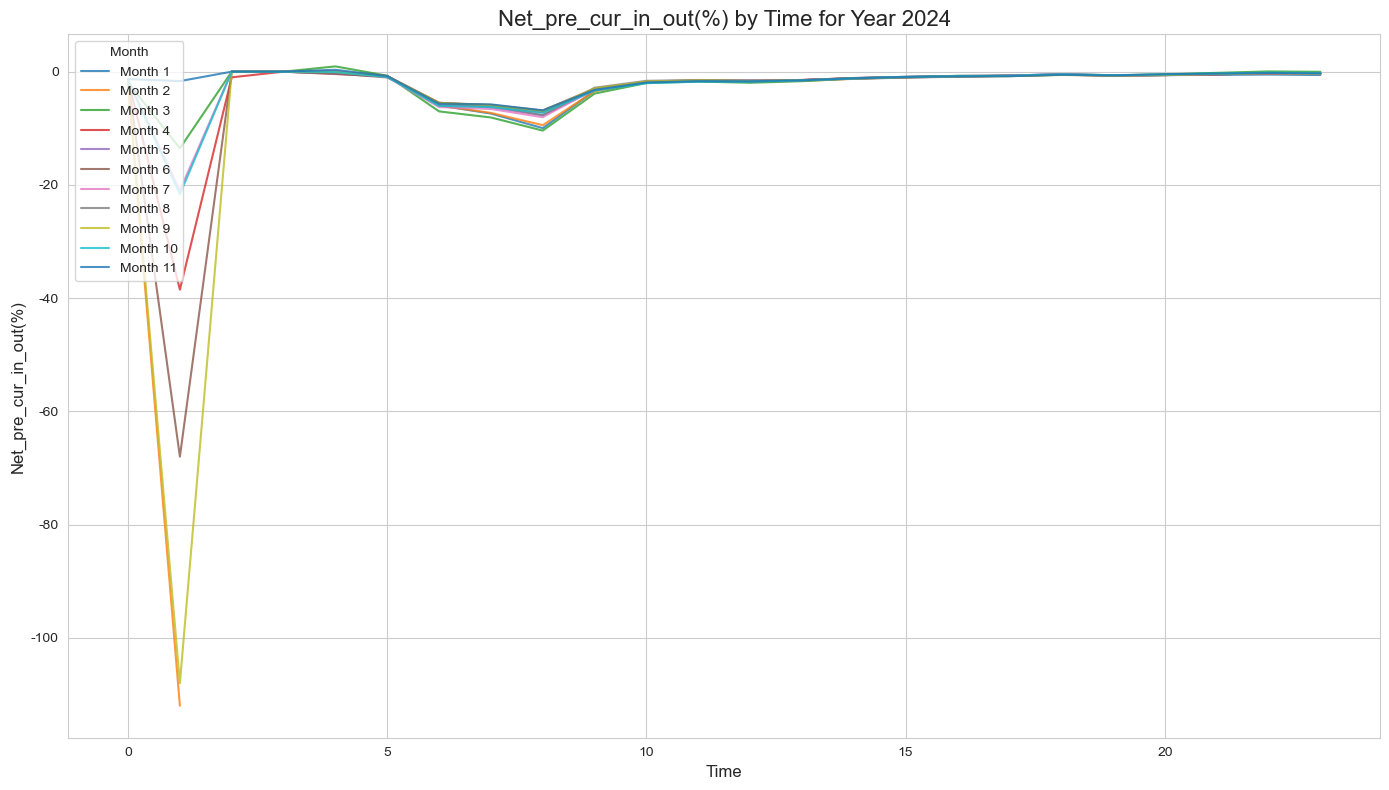

In [2347]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'time' and 'month' are numeric
restructured_df_combine_pre_net_in_out['time'] = restructured_df_combine_pre_net_in_out['time'].astype(int)
restructured_df_combine_pre_net_in_out['month'] = restructured_df_combine_pre_net_in_out['month'].astype(int)

# Group the data to ensure only one value per time per month
aggregated_data = (
    restructured_df_combine_pre_net_in_out
    .groupby(['year', 'month', 'time'], as_index=False)
    .agg({'Net_pre_cur_in_out(%)': 'mean'})  # Aggregate 'Net_in_out' (e.g., mean or sum)
)

# Set the plot style
sns.set_style("whitegrid")

# Get unique years
years = aggregated_data['year'].unique()

# Loop through each year to create separate plots
for year in years:
    yearly_data = aggregated_data[aggregated_data['year'] == year]
    
    # Initialize the plot for the current year
    plt.figure(figsize=(14, 8))
    
    # Loop through each month and plot data
    for month in yearly_data['month'].unique():
        monthly_data = yearly_data[yearly_data['month'] == month]
        plt.plot(
            monthly_data['time'],
            monthly_data['Net_pre_cur_in_out(%)'],
            label=f"Month {month}",
            alpha=0.8
        )
    
    # Add labels, legend, and title
    plt.title(f"Net_pre_cur_in_out(%) by Time for Year {year}", fontsize=16)
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Net_pre_cur_in_out(%)", fontsize=12)
    plt.legend(title="Month", loc='upper left', fontsize=10)
    
    # Adjust layout and show plot
    plt.tight_layout()
    plt.show()

In [2348]:
restructured_df_combine_pre_net_in_out

,in,ratio_in,datetime,year,month,time,out,ratio_out,in_CMR,ratio_in_CMR,in_HH,ratio_in_HH,Net_in_out,prev_month,prev_Net_in_out,Net_pre_cur_in_out,Net_pre_cur_in_out(%)
0,44,0.00004,20241104,2024,11,4,0,0.00000,72,0.00008,26,0.00003,44,20241004,33.0,11.0,0.333333
1,1892,0.00164,20241105,2024,11,5,1466,0.00119,3510,0.00371,1519,0.00179,426,20241005,1978.0,-1552.0,-0.784631
2,4132,0.00358,20241106,2024,11,6,25061,0.02036,5864,0.00619,3503,0.00412,-20929,20241006,4503.0,-25432.0,-5.647790
3,9020,0.00782,20241107,2024,11,7,55355,0.04498,12941,0.01367,5712,0.00672,-46335,20241007,9685.0,-56020.0,-5.784202
4,18160,0.01575,20241108,2024,11,8,136749,0.11112,24046,0.02539,9978,0.01174,-118589,20241008,20322.0,-138911.0,-6.835498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2851,45613,0.03734,20150123,2015,1,23,8871,0.00665,30679,0.03065,9133,0.01036,36742,20141223,0.0,0.0,0.000000
2852,2971,0.00243,20150100,2015,1,0,2215,0.00166,5425,0.00542,1156,0.00131,756,20141200,0.0,0.0,0.000000
2853,3,0.00000,20150101,2015,1,1,82,0.00006,1,0.00000,0,0.00000,-79,20141201,0.0,0.0,0.000000
2854,0,0.00000,20150102,2015,1,2,0,0.00000,0,0.00000,0,0.00000,0,20141202,0.0,0.0,0.000000


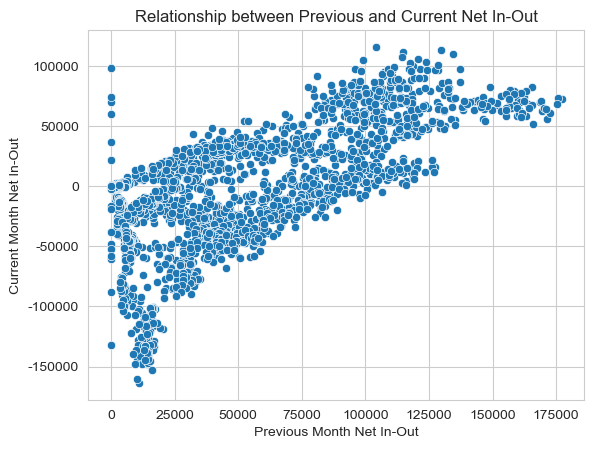

In [2349]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x='prev_Net_in_out', y='Net_in_out', data=restructured_df_combine_pre_net_in_out)
plt.title('Relationship between Previous and Current Net In-Out')
plt.xlabel('Previous Month Net In-Out')
plt.ylabel('Current Month Net In-Out')
plt.show()

In [2350]:
from scipy.stats import pearsonr

correlation, p_value = pearsonr(restructured_df_combine_pre_net_in_out['prev_Net_in_out'], 
                                restructured_df_combine_pre_net_in_out['Net_in_out'])

print(f"Correlation: {correlation:.2f}, p-value: {p_value:.2e}")

Correlation: 0.56, p-value: 2.55e-231


In [2351]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data
X = restructured_df_combine_pre_net_in_out[['prev_Net_in_out']].dropna()  # Independent variable
y = restructured_df_combine_pre_net_in_out['Net_in_out'].dropna()  # Dependent variable

# Train linear regression model
model = LinearRegression()
model.fit(X, y)

# Print results
print(f"Intercept: {model.intercept_:.2f}, Coefficient: {model.coef_[0]:.2f}")
print(f"R-squared: {model.score(X, y):.2f}")

Intercept: -25511.00, Coefficient: 0.57
R-squared: 0.31


In [2352]:
from statsmodels.tsa.stattools import grangercausalitytests

# Create a DataFrame with lagged data
test_data = restructured_df_combine_pre_net_in_out[['Net_in_out', 'prev_Net_in_out']].dropna()

# Perform Granger causality test
max_lags = 2  # Number of lags to test
grangercausalitytests(test_data, max_lags)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=359.7587, p=0.0000  , df_denom=2852, df_num=1
ssr based chi2 test:   chi2=360.1371, p=0.0000  , df=1
likelihood ratio test: chi2=339.1688, p=0.0000  , df=1
parameter F test:         F=359.7587, p=0.0000  , df_denom=2852, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=203.6963, p=0.0000  , df_denom=2849, df_num=2
ssr based chi2 test:   chi2=408.1076, p=0.0000  , df=2
likelihood ratio test: chi2=381.4427, p=0.0000  , df=2
parameter F test:         F=203.6963, p=0.0000  , df_denom=2849, df_num=2


{1: ({'ssr_ftest': (359.75869249358095, 1.1921339980551312e-75, 2852.0, 1),
   'ssr_chi2test': (360.13712029073406, 2.6286116407477664e-80, 1),
   'lrtest': (339.16875776408415, 9.680571839721625e-76, 1),
   'params_ftest': (359.75869248820175, 1.1921340009102388e-75, 2852.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (203.69630465873578, 2.0695634751662736e-83, 2849.0, 2),
   'ssr_chi2test': (408.1075840617985, 2.401950812138724e-89, 2),
   'lrtest': (381.44270985813637, 1.4817262444066354e-83, 2),
   'params_ftest': (203.69630465873635, 2.069563475165156e-83, 2849.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])])}

In [2353]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    restructured_df_combine_pre_net_in_out[['prev_Net_in_out']], 
    restructured_df_combine_pre_net_in_out['Net_in_out'], 
    test_size=0.2, random_state=42
)

# Train the model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 1127171437.54


In [2354]:
# Drop rows with missing values in the required columns
data_filtered = restructured_df_combine_pre_net_in_out.dropna(subset=["Net_in_out", "in_CMR", "in_HH"])

In [2355]:
correlation_matrix = data_filtered[["Net_in_out", "in_CMR", "in_HH"]].corr()
print(correlation_matrix)

            Net_in_out    in_CMR     in_HH
Net_in_out    1.000000  0.527651  0.351174
in_CMR        0.527651  1.000000  0.902544
in_HH         0.351174  0.902544  1.000000


In [2356]:
import statsmodels.api as sm

# Define predictors (in_CMR and in_HH) and the target (Net_in_out)
X = data_filtered[["in_CMR", "in_HH"]]
X = sm.add_constant(X)  # Add a constant term for the intercept
y = data_filtered["Net_in_out"]

# Fit the regression model
model = sm.OLS(y, X).fit()

# Display the results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Net_in_out   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.362
Method:                 Least Squares   F-statistic:                     812.1
Date:                Fri, 27 Dec 2024   Prob (F-statistic):          6.90e-280
Time:                        15:54:25   Log-Likelihood:                -33875.
No. Observations:                2856   AIC:                         6.776e+04
Df Residuals:                    2853   BIC:                         6.777e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.352e+04    885.654    -26.558      0.0

In [2357]:
from statsmodels.tsa.stattools import grangercausalitytests

# Prepare the data for Granger causality test
# Ensure columns are in the correct order: dependent variable first
test_data = data_filtered[["Net_in_out", "in_CMR", "in_HH"]]

# Run the Granger causality test
max_lag = 2  # Test for lags 1 and 2
grangercausalitytests(test_data[["Net_in_out", "in_CMR"]], maxlag=max_lag, verbose=True)
grangercausalitytests(test_data[["Net_in_out", "in_HH"]], maxlag=max_lag, verbose=True)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=281.3652, p=0.0000  , df_denom=2852, df_num=1
ssr based chi2 test:   chi2=281.6612, p=0.0000  , df=1
likelihood ratio test: chi2=268.6186, p=0.0000  , df=1
parameter F test:         F=281.3652, p=0.0000  , df_denom=2852, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=236.8464, p=0.0000  , df_denom=2849, df_num=2
ssr based chi2 test:   chi2=474.5242, p=0.0000  , df=2
likelihood ratio test: chi2=438.9666, p=0.0000  , df=2
parameter F test:         F=236.8464, p=0.0000  , df_denom=2849, df_num=2

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=563.6907, p=0.0000  , df_denom=2852, df_num=1
ssr based chi2 test:   chi2=564.2836, p=0.0000  , df=1
likelihood ratio test: chi2=514.9256, p=0.0000  , df=1
parameter F test:         F=563.6907, p=0.0000  , df_denom=2852, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=295.4079, p=0.

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{1: ({'ssr_ftest': (563.6906927454751, 7.372315663407195e-114, 2852.0, 1),
   'ssr_chi2test': (564.2836352694009, 9.835366832374328e-125, 1),
   'lrtest': (514.9255806786168, 5.3772389031533396e-114, 1),
   'params_ftest': (563.6906927347104, 7.372315696597771e-114, 2852.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (295.40793321940157, 2.6002081734053325e-117, 2849.0, 2),
   'ssr_chi2test': (591.8527493212861, 3.025578568743023e-129, 2),
   'lrtest': (537.8359781797772, 1.6233092140070162e-117, 2),
   'params_ftest': (295.40793321940134, 2.6002081734053325e-117, 2849.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])])}

# Merge

In [2358]:
md_adj.to_csv("../data/md_adj.csv",index=False)

In [2359]:
import pandas as pd

# Load your dataset
file_path = "../data/md_adj.csv"  # Replace with your file path
md_adj = pd.read_csv(file_path)

# Ensure '사용일자' column is treated as a string
md_adj['사용일자'] = md_adj['사용일자'].astype(str)

# Create a new DataFrame to hold the expanded data
expanded_data = []

# Loop through each row in the original DataFrame
for _, row in md_adj.iterrows():
    for hour in range(24):  # Add rows for each hour (00 to 23)
        new_row = row.copy()
        new_row['time'] = f"{hour:02d}"  # Format time as '00', '01', ..., '23'
        expanded_data.append(new_row)

# Convert the list of rows back into a DataFrame
expanded_df = pd.DataFrame(expanded_data)

# Save the expanded DataFrame to a new CSV file
expanded_df.to_csv('expanded_md_adj.csv', index=False)

# Print the first few rows to confirm
print(expanded_df.head(48))  # View two days' worth of data

         사용일자  노선명  역명  승차총승객수  하차총승객수  승하차 차이  week  weekend&public holiday  \
0  2023-01-01  4호선  명동   21608   23356   -1748     6                       1   
0  2023-01-01  4호선  명동   21608   23356   -1748     6                       1   
0  2023-01-01  4호선  명동   21608   23356   -1748     6                       1   
0  2023-01-01  4호선  명동   21608   23356   -1748     6                       1   
0  2023-01-01  4호선  명동   21608   23356   -1748     6                       1   
0  2023-01-01  4호선  명동   21608   23356   -1748     6                       1   
0  2023-01-01  4호선  명동   21608   23356   -1748     6                       1   
0  2023-01-01  4호선  명동   21608   23356   -1748     6                       1   
0  2023-01-01  4호선  명동   21608   23356   -1748     6                       1   
0  2023-01-01  4호선  명동   21608   23356   -1748     6                       1   
0  2023-01-01  4호선  명동   21608   23356   -1748     6                       1   
0  2023-01-01  4호선  명동   21608   23356  

In [2360]:
expanded_df

,사용일자,노선명,역명,승차총승객수,하차총승객수,승하차 차이,week,weekend&public holiday,time
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,00
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,01
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,02
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,03
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,04
...,...,...,...,...,...,...,...,...,...
699,2024-11-30,4호선,명동,40349,44107,-3758,5,1,19
699,2024-11-30,4호선,명동,40349,44107,-3758,5,1,20
699,2024-11-30,4호선,명동,40349,44107,-3758,5,1,21
699,2024-11-30,4호선,명동,40349,44107,-3758,5,1,22


In [2361]:
restructured_df_combine_pre_net_in_out[restructured_df_combine_pre_net_in_out["time"] == 2]

,in,ratio_in,datetime,year,month,time,out,ratio_out,in_CMR,ratio_in_CMR,in_HH,ratio_in_HH,Net_in_out,prev_month,prev_Net_in_out,Net_pre_cur_in_out,Net_pre_cur_in_out(%)
22,0,0.0,20241102,2024,11,2,0,0.0,0,0.0,0,0.0,0,20241002,0.0,0.0,0.0
46,0,0.0,20241002,2024,10,2,0,0.0,0,0.0,0,0.0,0,20240902,0.0,0.0,0.0
70,0,0.0,20240902,2024,9,2,0,0.0,0,0.0,0,0.0,0,20240802,0.0,0.0,0.0
94,0,0.0,20240802,2024,8,2,0,0.0,0,0.0,0,0.0,0,20240702,0.0,0.0,0.0
118,0,0.0,20240702,2024,7,2,0,0.0,0,0.0,0,0.0,0,20240602,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2758,0,0.0,20150502,2015,5,2,0,0.0,0,0.0,0,0.0,0,20150402,0.0,0.0,0.0
2782,0,0.0,20150402,2015,4,2,0,0.0,0,0.0,0,0.0,0,20150302,1.0,-1.0,-1.0
2806,1,0.0,20150302,2015,3,2,0,0.0,0,0.0,0,0.0,1,20150202,0.0,1.0,inf
2830,0,0.0,20150202,2015,2,2,3,0.0,0,0.0,0,0.0,-3,20150102,0.0,-3.0,-inf


In [2362]:
restructured_df_combine_pre_net_in_out

,in,ratio_in,datetime,year,month,time,out,ratio_out,in_CMR,ratio_in_CMR,in_HH,ratio_in_HH,Net_in_out,prev_month,prev_Net_in_out,Net_pre_cur_in_out,Net_pre_cur_in_out(%)
0,44,0.00004,20241104,2024,11,4,0,0.00000,72,0.00008,26,0.00003,44,20241004,33.0,11.0,0.333333
1,1892,0.00164,20241105,2024,11,5,1466,0.00119,3510,0.00371,1519,0.00179,426,20241005,1978.0,-1552.0,-0.784631
2,4132,0.00358,20241106,2024,11,6,25061,0.02036,5864,0.00619,3503,0.00412,-20929,20241006,4503.0,-25432.0,-5.647790
3,9020,0.00782,20241107,2024,11,7,55355,0.04498,12941,0.01367,5712,0.00672,-46335,20241007,9685.0,-56020.0,-5.784202
4,18160,0.01575,20241108,2024,11,8,136749,0.11112,24046,0.02539,9978,0.01174,-118589,20241008,20322.0,-138911.0,-6.835498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2851,45613,0.03734,20150123,2015,1,23,8871,0.00665,30679,0.03065,9133,0.01036,36742,20141223,0.0,0.0,0.000000
2852,2971,0.00243,20150100,2015,1,0,2215,0.00166,5425,0.00542,1156,0.00131,756,20141200,0.0,0.0,0.000000
2853,3,0.00000,20150101,2015,1,1,82,0.00006,1,0.00000,0,0.00000,-79,20141201,0.0,0.0,0.000000
2854,0,0.00000,20150102,2015,1,2,0,0.00000,0,0.00000,0,0.00000,0,20141202,0.0,0.0,0.000000


In [2363]:
expanded_df["year"] =  [ str(i)[0:4] for i in expanded_df['사용일자']]
expanded_df["month"] = [ str(i)[5:7] for i in expanded_df['사용일자']]

In [2364]:
expanded_df["time"] = expanded_df["time"].astype(int)

In [2365]:
expanded_df

,사용일자,노선명,역명,승차총승객수,하차총승객수,승하차 차이,week,weekend&public holiday,time,year,month
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,0,2023,01
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,1,2023,01
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,2,2023,01
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,3,2023,01
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,4,2023,01
...,...,...,...,...,...,...,...,...,...,...,...
699,2024-11-30,4호선,명동,40349,44107,-3758,5,1,19,2024,11
699,2024-11-30,4호선,명동,40349,44107,-3758,5,1,20,2024,11
699,2024-11-30,4호선,명동,40349,44107,-3758,5,1,21,2024,11
699,2024-11-30,4호선,명동,40349,44107,-3758,5,1,22,2024,11


In [2366]:
restructured_df_combine_pre_net_in_out["month"] = [ str(i).zfill(2) for i in restructured_df_combine_pre_net_in_out["month"] ]
restructured_df_combine_pre_net_in_out["time"] = [ str(i).zfill(2) for i in restructured_df_combine_pre_net_in_out["time"] ]
expanded_df["month"] = [ str(i).zfill(2) for i in expanded_df["month"] ]
expanded_df["time"] = [ str(i).zfill(2) for i in expanded_df["time"] ]

In [2367]:
restructured_df_combine_pre_net_in_out["yearmonthtime"] = restructured_df_combine_pre_net_in_out["year"].astype(str) + restructured_df_combine_pre_net_in_out["month"].astype(str) + restructured_df_combine_pre_net_in_out["time"].astype(str)
expanded_df["yearmonthtime"] = expanded_df["year"].astype(str) + expanded_df["month"].astype(str) + expanded_df["time"].astype(str)

In [2368]:
expanded_df

,사용일자,노선명,역명,승차총승객수,하차총승객수,승하차 차이,week,weekend&public holiday,time,year,month,yearmonthtime
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,00,2023,01,20230100
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,01,2023,01,20230101
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,02,2023,01,20230102
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,03,2023,01,20230103
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,04,2023,01,20230104
...,...,...,...,...,...,...,...,...,...,...,...,...
699,2024-11-30,4호선,명동,40349,44107,-3758,5,1,19,2024,11,20241119
699,2024-11-30,4호선,명동,40349,44107,-3758,5,1,20,2024,11,20241120
699,2024-11-30,4호선,명동,40349,44107,-3758,5,1,21,2024,11,20241121
699,2024-11-30,4호선,명동,40349,44107,-3758,5,1,22,2024,11,20241122


In [2369]:
restructured_df_combine_pre_net_in_out.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   in                     2856 non-null   int64  
 1   ratio_in               2856 non-null   float64
 2   datetime               2856 non-null   object 
 3   year                   2856 non-null   object 
 4   month                  2856 non-null   object 
 5   time                   2856 non-null   object 
 6   out                    2856 non-null   int64  
 7   ratio_out              2856 non-null   float64
 8   in_CMR                 2856 non-null   int64  
 9   ratio_in_CMR           2856 non-null   float64
 10  in_HH                  2856 non-null   int64  
 11  ratio_in_HH            2856 non-null   float64
 12  Net_in_out             2856 non-null   int64  
 13  prev_month             2856 non-null   object 
 14  prev_Net_in_out        2856 non-null   float64
 15  Net_

In [2370]:
restructured_df_combine_pre_net_in_out["prev_month"].unique()

array(['20241004', '20241005', '20241006', ..., '20141201', '20141202',
       '20141203'], dtype=object)

In [2371]:
restructured_df_combine_pre_net_in_out

,in,ratio_in,datetime,year,month,time,out,ratio_out,in_CMR,ratio_in_CMR,in_HH,ratio_in_HH,Net_in_out,prev_month,prev_Net_in_out,Net_pre_cur_in_out,Net_pre_cur_in_out(%),yearmonthtime
0,44,0.00004,20241104,2024,11,04,0,0.00000,72,0.00008,26,0.00003,44,20241004,33.0,11.0,0.333333,20241104
1,1892,0.00164,20241105,2024,11,05,1466,0.00119,3510,0.00371,1519,0.00179,426,20241005,1978.0,-1552.0,-0.784631,20241105
2,4132,0.00358,20241106,2024,11,06,25061,0.02036,5864,0.00619,3503,0.00412,-20929,20241006,4503.0,-25432.0,-5.647790,20241106
3,9020,0.00782,20241107,2024,11,07,55355,0.04498,12941,0.01367,5712,0.00672,-46335,20241007,9685.0,-56020.0,-5.784202,20241107
4,18160,0.01575,20241108,2024,11,08,136749,0.11112,24046,0.02539,9978,0.01174,-118589,20241008,20322.0,-138911.0,-6.835498,20241108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2851,45613,0.03734,20150123,2015,01,23,8871,0.00665,30679,0.03065,9133,0.01036,36742,20141223,0.0,0.0,0.000000,20150123
2852,2971,0.00243,20150100,2015,01,00,2215,0.00166,5425,0.00542,1156,0.00131,756,20141200,0.0,0.0,0.000000,20150100
2853,3,0.00000,20150101,2015,01,01,82,0.00006,1,0.00000,0,0.00000,-79,20141201,0.0,0.0,0.000000,20150101
2854,0,0.00000,20150102,2015,01,02,0,0.00000,0,0.00000,0,0.00000,0,20141202,0.0,0.0,0.000000,20150102


In [2372]:
expanded_df

,사용일자,노선명,역명,승차총승객수,하차총승객수,승하차 차이,week,weekend&public holiday,time,year,month,yearmonthtime
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,00,2023,01,20230100
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,01,2023,01,20230101
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,02,2023,01,20230102
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,03,2023,01,20230103
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,04,2023,01,20230104
...,...,...,...,...,...,...,...,...,...,...,...,...
699,2024-11-30,4호선,명동,40349,44107,-3758,5,1,19,2024,11,20241119
699,2024-11-30,4호선,명동,40349,44107,-3758,5,1,20,2024,11,20241120
699,2024-11-30,4호선,명동,40349,44107,-3758,5,1,21,2024,11,20241121
699,2024-11-30,4호선,명동,40349,44107,-3758,5,1,22,2024,11,20241122


In [2373]:
merge_data_md = pd.merge(expanded_df, restructured_df_combine_pre_net_in_out, on="yearmonthtime", how="left")

In [2374]:
merge_data_md

,사용일자,노선명,역명,승차총승객수,하차총승객수,승하차 차이,week,weekend&public holiday,time_x,year_x,...,ratio_out,in_CMR,ratio_in_CMR,in_HH,ratio_in_HH,Net_in_out,prev_month,prev_Net_in_out,Net_pre_cur_in_out,Net_pre_cur_in_out(%)
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,00,2023,...,0.00287,2947,0.00447,599,0.00096,-1105,20221200,1619.0,-2724.0,-1.682520
1,2023-01-01,4호선,명동,21608,23356,-1748,6,1,01,2023,...,0.00018,19,0.00003,3,0.00000,-120,20221201,35.0,-155.0,-4.428571
2,2023-01-01,4호선,명동,21608,23356,-1748,6,1,02,2023,...,0.00000,0,0.00000,0,0.00000,0,20221202,0.0,0.0,0.000000
3,2023-01-01,4호선,명동,21608,23356,-1748,6,1,03,2023,...,0.00000,0,0.00000,0,0.00000,0,20221203,0.0,0.0,0.000000
4,2023-01-01,4호선,명동,21608,23356,-1748,6,1,04,2023,...,0.00001,58,0.00009,12,0.00002,32,20221204,33.0,-1.0,-0.030303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16795,2024-11-30,4호선,명동,40349,44107,-3758,5,1,19,2024,...,0.05213,74975,0.07918,64014,0.07529,31831,20241019,94526.0,-62695.0,-0.663257
16796,2024-11-30,4호선,명동,40349,44107,-3758,5,1,20,2024,...,0.03771,59806,0.06316,58422,0.06871,46247,20241020,86548.0,-40301.0,-0.465649
16797,2024-11-30,4호선,명동,40349,44107,-3758,5,1,21,2024,...,0.02620,56421,0.05958,24412,0.02871,55063,20241021,83737.0,-28674.0,-0.342429
16798,2024-11-30,4호선,명동,40349,44107,-3758,5,1,22,2024,...,0.01510,42341,0.04471,13427,0.01579,59491,20241022,77325.0,-17834.0,-0.230637


In [2375]:
merge_data_md.columns

Index(['사용일자', '노선명', '역명', '승차총승객수', '하차총승객수', '승하차 차이', 'week',
       'weekend&public holiday', 'time_x', 'year_x', 'month_x',
       'yearmonthtime', 'in', 'ratio_in', 'datetime', 'year_y', 'month_y',
       'time_y', 'out', 'ratio_out', 'in_CMR', 'ratio_in_CMR', 'in_HH',
       'ratio_in_HH', 'Net_in_out', 'prev_month', 'prev_Net_in_out',
       'Net_pre_cur_in_out', 'Net_pre_cur_in_out(%)'],
      dtype='object')

In [2376]:
merge_data_md.drop("time_x",axis=1,inplace= True)
merge_data_md.drop("year_x",axis=1,inplace= True)
merge_data_md.drop("month_x",axis=1,inplace= True)
merge_data_md.rename({"time_y" : "time"},axis=1,inplace= True)
merge_data_md.rename({"year_y" : "year"},axis=1,inplace= True)
merge_data_md.rename({"month_y" : "month"},axis=1,inplace= True)

In [2377]:
merge_data_md

,사용일자,노선명,역명,승차총승객수,하차총승객수,승하차 차이,week,weekend&public holiday,yearmonthtime,in,...,ratio_out,in_CMR,ratio_in_CMR,in_HH,ratio_in_HH,Net_in_out,prev_month,prev_Net_in_out,Net_pre_cur_in_out,Net_pre_cur_in_out(%)
0,2023-01-01,4호선,명동,21608,23356,-1748,6,1,20230100,993,...,0.00287,2947,0.00447,599,0.00096,-1105,20221200,1619.0,-2724.0,-1.682520
1,2023-01-01,4호선,명동,21608,23356,-1748,6,1,20230101,13,...,0.00018,19,0.00003,3,0.00000,-120,20221201,35.0,-155.0,-4.428571
2,2023-01-01,4호선,명동,21608,23356,-1748,6,1,20230102,0,...,0.00000,0,0.00000,0,0.00000,0,20221202,0.0,0.0,0.000000
3,2023-01-01,4호선,명동,21608,23356,-1748,6,1,20230103,0,...,0.00000,0,0.00000,0,0.00000,0,20221203,0.0,0.0,0.000000
4,2023-01-01,4호선,명동,21608,23356,-1748,6,1,20230104,42,...,0.00001,58,0.00009,12,0.00002,32,20221204,33.0,-1.0,-0.030303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16795,2024-11-30,4호선,명동,40349,44107,-3758,5,1,20241119,95980,...,0.05213,74975,0.07918,64014,0.07529,31831,20241019,94526.0,-62695.0,-0.663257
16796,2024-11-30,4호선,명동,40349,44107,-3758,5,1,20241120,92654,...,0.03771,59806,0.06316,58422,0.06871,46247,20241020,86548.0,-40301.0,-0.465649
16797,2024-11-30,4호선,명동,40349,44107,-3758,5,1,20241121,87307,...,0.02620,56421,0.05958,24412,0.02871,55063,20241021,83737.0,-28674.0,-0.342429
16798,2024-11-30,4호선,명동,40349,44107,-3758,5,1,20241122,78072,...,0.01510,42341,0.04471,13427,0.01579,59491,20241022,77325.0,-17834.0,-0.230637


In [2378]:
merge_data_md["in_final"] = merge_data_md["ratio_in"] * merge_data_md["승차총승객수"]
merge_data_md["out_final"] = merge_data_md["ratio_out"] * merge_data_md["하차총승객수"]
merge_data_md["net_in_out_final"] = merge_data_md["in_final"] - merge_data_md["out_final"]

In [2379]:
merge_data_md.columns

Index(['사용일자', '노선명', '역명', '승차총승객수', '하차총승객수', '승하차 차이', 'week',
       'weekend&public holiday', 'yearmonthtime', 'in', 'ratio_in', 'datetime',
       'year', 'month', 'time', 'out', 'ratio_out', 'in_CMR', 'ratio_in_CMR',
       'in_HH', 'ratio_in_HH', 'Net_in_out', 'prev_month', 'prev_Net_in_out',
       'Net_pre_cur_in_out', 'Net_pre_cur_in_out(%)', 'in_final', 'out_final',
       'net_in_out_final'],
      dtype='object')

In [2380]:
merge_data_md_adj = merge_data_md[["사용일자","year","month","time","week","weekend&public holiday","in_final","out_final","net_in_out_final"]]

In [2381]:
merge_data_md_adj["day"] = [ i[8:10] for i in merge_data_md_adj["사용일자"]]

/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_76769/155525892.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merge_data_md_adj["day"] = [ i[8:10] for i in merge_data_md_adj["사용일자"]]


In [2382]:
merge_data_md_adj

,사용일자,year,month,time,week,weekend&public holiday,in_final,out_final,net_in_out_final,day
0,2023-01-01,2023,01,00,6,1,31.11552,67.03172,-35.91620,01
1,2023-01-01,2023,01,01,6,1,0.43216,4.20408,-3.77192,01
2,2023-01-01,2023,01,02,6,1,0.00000,0.00000,0.00000,01
3,2023-01-01,2023,01,03,6,1,0.00000,0.00000,0.00000,01
4,2023-01-01,2023,01,04,6,1,1.29648,0.23356,1.06292,01
...,...,...,...,...,...,...,...,...,...,...
16795,2024-11-30,2024,11,19,5,1,3358.65076,2299.29791,1059.35285,30
16796,2024-11-30,2024,11,20,5,1,3242.44564,1663.27497,1579.17067,30
16797,2024-11-30,2024,11,21,5,1,3055.22628,1155.60340,1899.62288,30
16798,2024-11-30,2024,11,22,5,1,2732.03079,666.01570,2066.01509,30


In [2383]:
merge_data_md_adj_WD = merge_data_md_adj[merge_data_md_adj["weekend&public holiday"] == 0]
merge_data_md_adj_H = merge_data_md_adj[merge_data_md_adj["weekend&public holiday"] == 1]
merge_data_md_adj_mon = merge_data_md_adj[merge_data_md_adj["week"] == 0]
merge_data_md_adj_tue = merge_data_md_adj[merge_data_md_adj["week"] == 1]
merge_data_md_adj_wed = merge_data_md_adj[merge_data_md_adj["week"] == 2]
merge_data_md_adj_thu = merge_data_md_adj[merge_data_md_adj["week"] == 3]
merge_data_md_adj_fri = merge_data_md_adj[merge_data_md_adj["week"] == 4]
merge_data_md_adj_sat = merge_data_md_adj[merge_data_md_adj["week"] == 5]
merge_data_md_adj_sun = merge_data_md_adj[merge_data_md_adj["week"] == 6]

In [2384]:
merge_data_md_adj_WD

,사용일자,year,month,time,week,weekend&public holiday,in_final,out_final,net_in_out_final,day
24,2023-01-02,2023,01,00,0,0,37.66320,76.43958,-38.77638,02
25,2023-01-02,2023,01,01,0,0,0.52310,4.79412,-4.27102,02
26,2023-01-02,2023,01,02,0,0,0.00000,0.00000,0.00000,02
27,2023-01-02,2023,01,03,0,0,0.00000,0.00000,0.00000,02
28,2023-01-02,2023,01,04,0,0,1.56930,0.26634,1.30296,02
...,...,...,...,...,...,...,...,...,...,...
16771,2024-11-29,2024,11,19,4,0,3407.59588,2289.86238,1117.73350,29
16772,2024-11-29,2024,11,20,4,0,3289.69732,1656.44946,1633.24786,29
16773,2024-11-29,2024,11,21,4,0,3099.74964,1150.86120,1948.88844,29
16774,2024-11-29,2024,11,22,4,0,2771.84427,663.28260,2108.56167,29


In [2385]:
merge_data_md_adj_WD["사용일자"] = pd.to_datetime(merge_data_md_adj_WD["사용일자"])

/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_76769/2978324692.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merge_data_md_adj_WD["사용일자"] = pd.to_datetime(merge_data_md_adj_WD["사용일자"])


In [2386]:
filtered_data = merge_data_md_adj_WD[merge_data_md_adj_WD['사용일자'].astype(str).str.contains("2023-07")]

In [2427]:
merge_data_md_adj_WD

,사용일자,year,month,time,week,weekend&public holiday,in_final,out_final,net_in_out_final,day
24,2023-01-02,2023,01,00,0,0,37.66320,76.43958,-38.77638,02
25,2023-01-02,2023,01,01,0,0,0.52310,4.79412,-4.27102,02
26,2023-01-02,2023,01,02,0,0,0.00000,0.00000,0.00000,02
27,2023-01-02,2023,01,03,0,0,0.00000,0.00000,0.00000,02
28,2023-01-02,2023,01,04,0,0,1.56930,0.26634,1.30296,02
...,...,...,...,...,...,...,...,...,...,...
16771,2024-11-29,2024,11,19,4,0,3407.59588,2289.86238,1117.73350,29
16772,2024-11-29,2024,11,20,4,0,3289.69732,1656.44946,1633.24786,29
16773,2024-11-29,2024,11,21,4,0,3099.74964,1150.86120,1948.88844,29
16774,2024-11-29,2024,11,22,4,0,2771.84427,663.28260,2108.56167,29


In [2387]:
filtered_data

,사용일자,year,month,time,week,weekend&public holiday,in_final,out_final,net_in_out_final,day
4392,2023-07-03,2023,07,00,0,0,46.98018,129.30687,-82.32669,03
4393,2023-07-03,2023,07,01,0,0,0.00000,5.21136,-5.21136,03
4394,2023-07-03,2023,07,02,0,0,0.00000,0.00000,0.00000,03
4395,2023-07-03,2023,07,03,0,0,0.00000,0.00000,0.00000,03
4396,2023-07-03,2023,07,04,0,0,0.92118,0.00000,0.92118,03
...,...,...,...,...,...,...,...,...,...,...
5083,2023-07-31,2023,07,19,0,0,2533.65003,1700.99400,832.65603,31
5084,2023-07-31,2023,07,20,0,0,2365.46892,1348.44200,1017.02692,31
5085,2023-07-31,2023,07,21,0,0,2235.55464,1054.53300,1181.02164,31
5086,2023-07-31,2023,07,22,0,0,1947.74949,721.76000,1225.98949,31


In [2388]:
import pandas as pd

# Assuming 'date_column' contains dates and 'time' contains hours
filtered_data['datetime'] = pd.to_datetime(
    filtered_data['사용일자'].astype(str) + ' ' + filtered_data['time'].astype(str) + ':00:00',
    format='%Y-%m-%d %H:%M:%S'
)

/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_76769/1131076766.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['datetime'] = pd.to_datetime(


In [2389]:
filtered_data = filtered_data.sort_values(by='datetime')

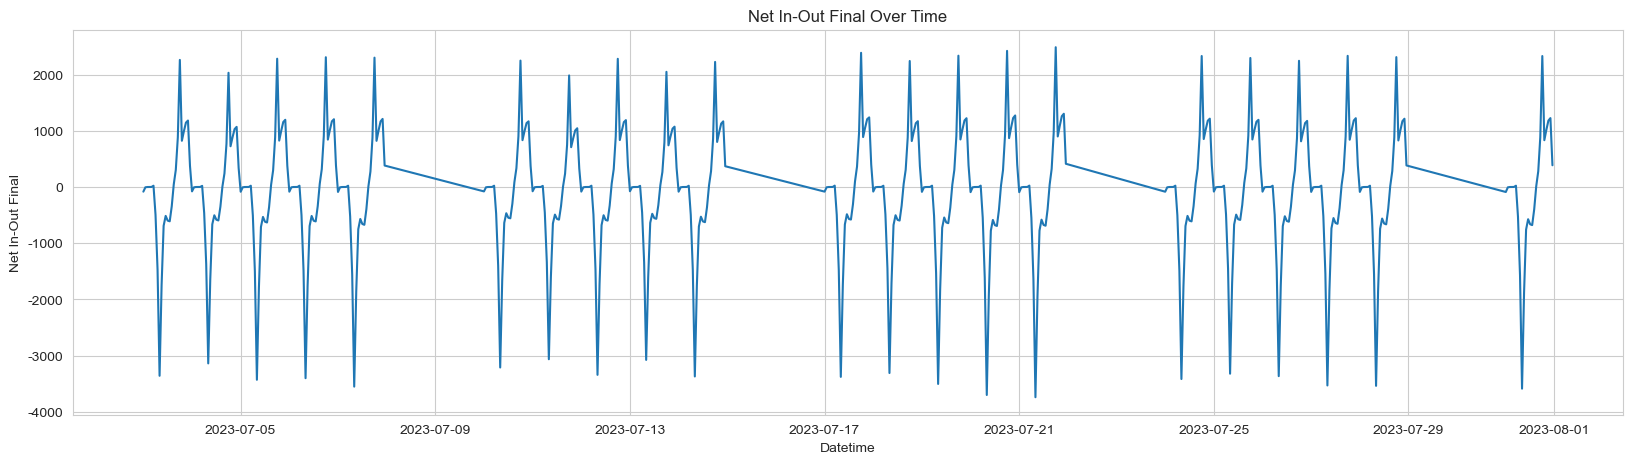

In [2390]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 5))
plt.plot(
    filtered_data['datetime'],  # x-axis data (continuous datetime)
    filtered_data['net_in_out_final']  # y-axis data
)
plt.xlabel("Datetime")
plt.ylabel("Net In-Out Final")
plt.title("Net In-Out Final Over Time")
plt.show()

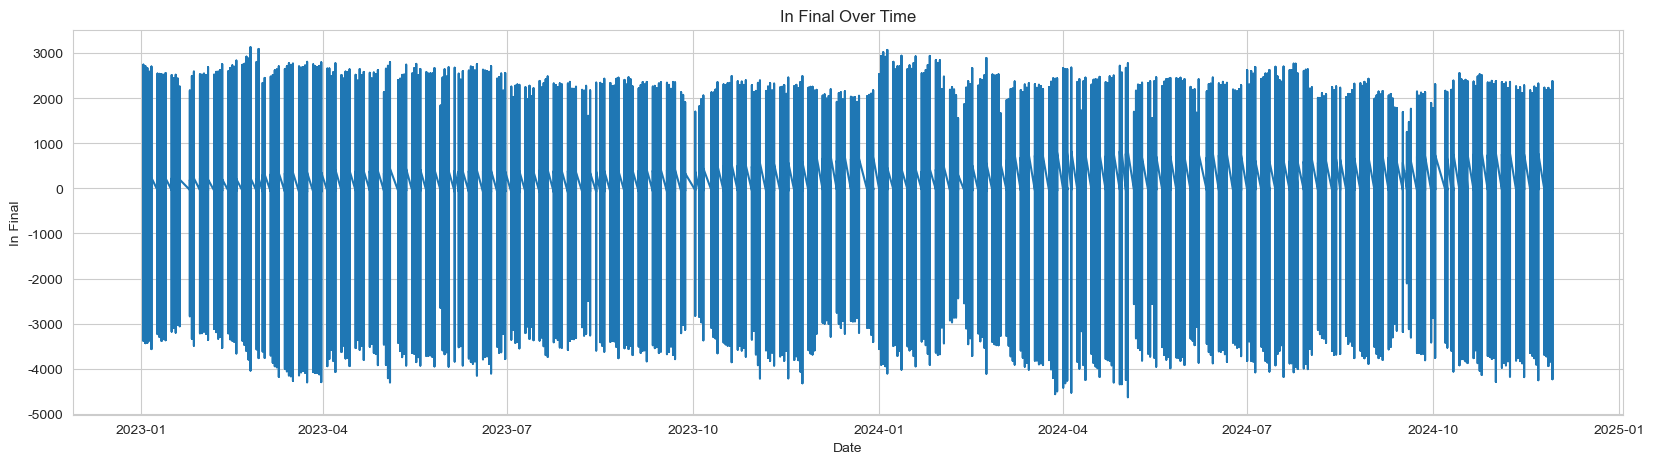

In [2391]:
plt.figure(figsize=(20,5))
plt.plot(
    merge_data_md_adj_WD["사용일자"],  # x-axis data (dates)
    merge_data_md_adj_WD["net_in_out_final"]  # y-axis data
)
plt.xlabel("Date")  # Add x-axis label
plt.ylabel("In Final")  # Add y-axis label
plt.title("In Final Over Time")  # Add a title
plt.show()

In [2392]:
# Group by '사용일자' and sum other columns
merge_data_md_adj_WD_D = merge_data_md_adj_WD.groupby('사용일자').sum().reset_index()

# Display the resulting DataFrame
print(merge_data_md_adj_WD_D)

          사용일자                                               year  \
0   2023-01-02  2023202320232023202320232023202320232023202320...   
1   2023-01-03  2023202320232023202320232023202320232023202320...   
2   2023-01-04  2023202320232023202320232023202320232023202320...   
3   2023-01-05  2023202320232023202320232023202320232023202320...   
4   2023-01-06  2023202320232023202320232023202320232023202320...   
..         ...                                                ...   
476 2024-11-25  2024202420242024202420242024202420242024202420...   
477 2024-11-26  2024202420242024202420242024202420242024202420...   
478 2024-11-27  2024202420242024202420242024202420242024202420...   
479 2024-11-28  2024202420242024202420242024202420242024202420...   
480 2024-11-29  2024202420242024202420242024202420242024202420...   

                                                month  \
0    010101010101010101010101010101010101010101010101   
1    010101010101010101010101010101010101010101010101   


In [2393]:
merge_data_md_adj_WD_D = merge_data_md_adj_WD.groupby('사용일자')[['in_final', 'out_final', 'net_in_out_final']].sum().reset_index()
merge_data_md_adj_H_D = merge_data_md_adj_H.groupby('사용일자')[['in_final', 'out_final', 'net_in_out_final']].sum().reset_index()
merge_data_md_adj_mon = merge_data_md_adj_mon.groupby('사용일자')[['in_final', 'out_final', 'net_in_out_final']].sum().reset_index()
merge_data_md_adj_tue = merge_data_md_adj_tue.groupby('사용일자')[['in_final', 'out_final', 'net_in_out_final']].sum().reset_index()
merge_data_md_adj_wed = merge_data_md_adj_wed.groupby('사용일자')[['in_final', 'out_final', 'net_in_out_final']].sum().reset_index()
merge_data_md_adj_thu = merge_data_md_adj_thu.groupby('사용일자')[['in_final', 'out_final', 'net_in_out_final']].sum().reset_index()
merge_data_md_adj_fri = merge_data_md_adj_fri.groupby('사용일자')[['in_final', 'out_final', 'net_in_out_final']].sum().reset_index()
merge_data_md_adj_sat = merge_data_md_adj_sat.groupby('사용일자')[['in_final', 'out_final', 'net_in_out_final']].sum().reset_index()
merge_data_md_adj_sun = merge_data_md_adj_sun.groupby('사용일자')[['in_final', 'out_final', 'net_in_out_final']].sum().reset_index()

In [2394]:
merge_data_md_adj_WD_D

,사용일자,in_final,out_final,net_in_out_final
0,2023-01-02,26154.73845,26633.46732,-478.72887
1,2023-01-03,26087.73912,27010.45978,-922.72066
2,2023-01-04,25780.74219,26908.46182,-1127.71963
3,2023-01-05,25158.74841,26492.47014,-1333.72173
4,2023-01-06,26389.73610,27982.44034,-1592.70424
...,...,...,...,...
476,2024-11-25,36989.63010,38475.23048,-1485.60038
477,2024-11-26,36728.63271,38751.22496,-2022.59225
478,2024-11-27,38234.61765,40907.18184,-2672.56419
479,2024-11-28,37341.62658,39864.20270,-2522.57612


/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


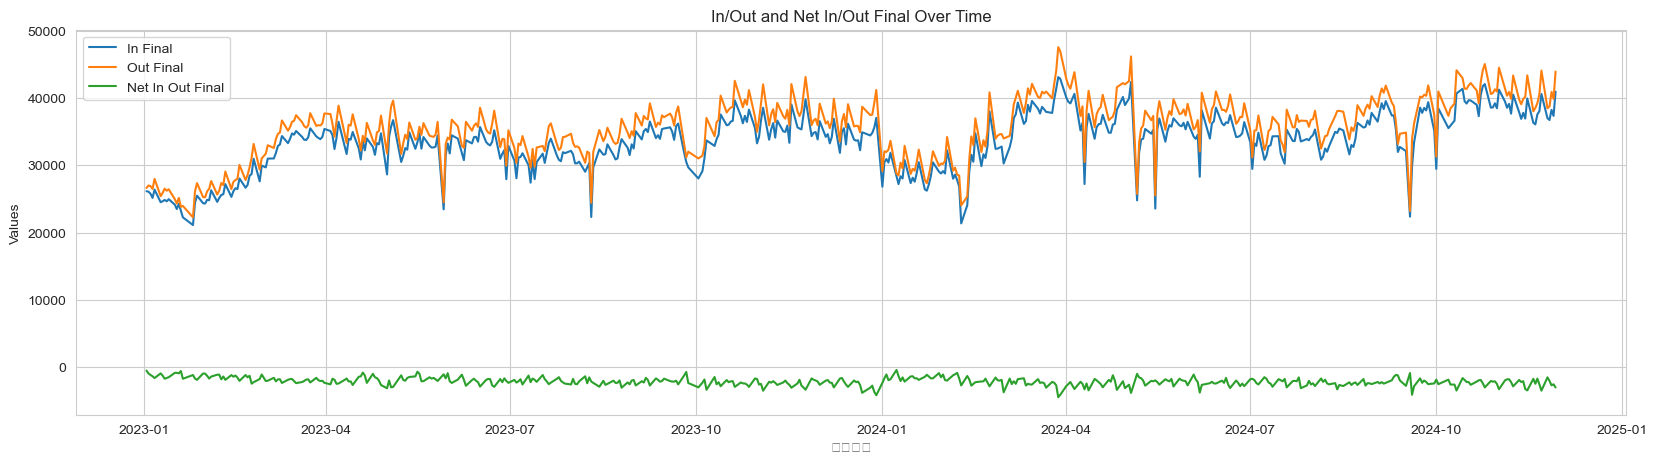

In [2395]:
plt.figure(figsize=(20, 5))

# Plot each column individually
plt.plot(merge_data_md_adj_WD_D["사용일자"], merge_data_md_adj_WD_D["in_final"], label="In Final")
plt.plot(merge_data_md_adj_WD_D["사용일자"], merge_data_md_adj_WD_D["out_final"], label="Out Final")
plt.plot(merge_data_md_adj_WD_D["사용일자"], merge_data_md_adj_WD_D["net_in_out_final"], label="Net In Out Final")

# Add legend
plt.legend()

# Add labels and title
plt.xlabel("사용일자")
plt.ylabel("Values")
plt.title("In/Out and Net In/Out Final Over Time")

plt.show()

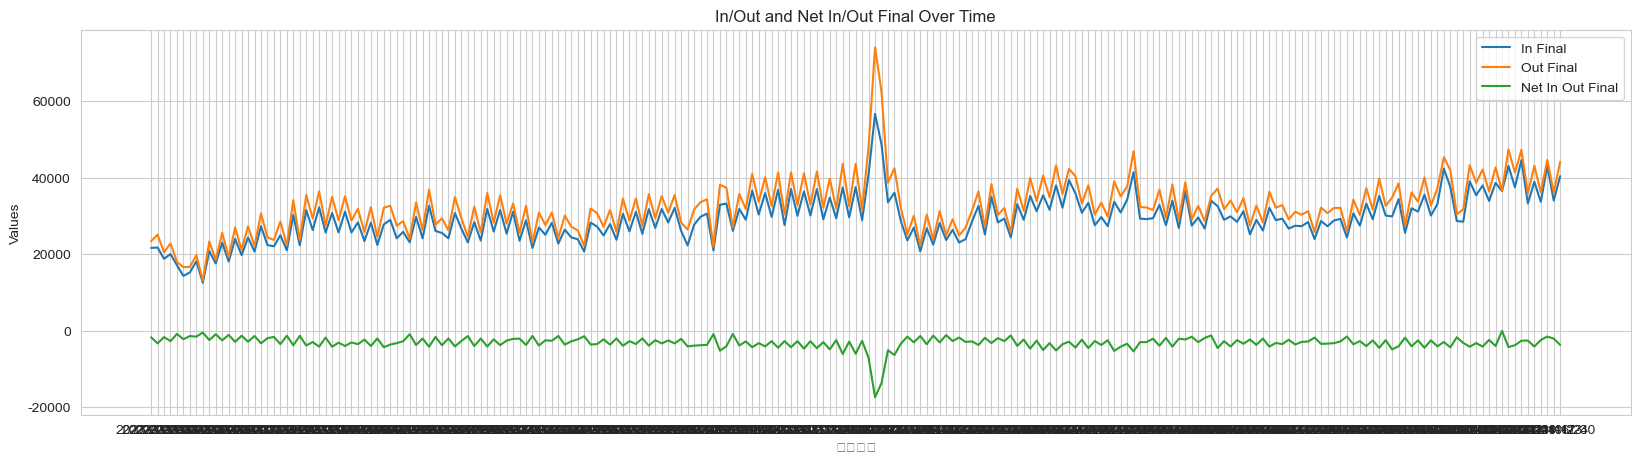

In [2396]:
plt.figure(figsize=(20, 5))

# Plot each column individually
plt.plot(merge_data_md_adj_H_D["사용일자"], merge_data_md_adj_H_D["in_final"], label="In Final")
plt.plot(merge_data_md_adj_H_D["사용일자"], merge_data_md_adj_H_D["out_final"], label="Out Final")
plt.plot(merge_data_md_adj_H_D["사용일자"], merge_data_md_adj_H_D["net_in_out_final"], label="Net In Out Final")

# Add legend
plt.legend()

# Add labels and title
plt.xlabel("사용일자")
plt.ylabel("Values")
plt.title("In/Out and Net In/Out Final Over Time")

plt.show()

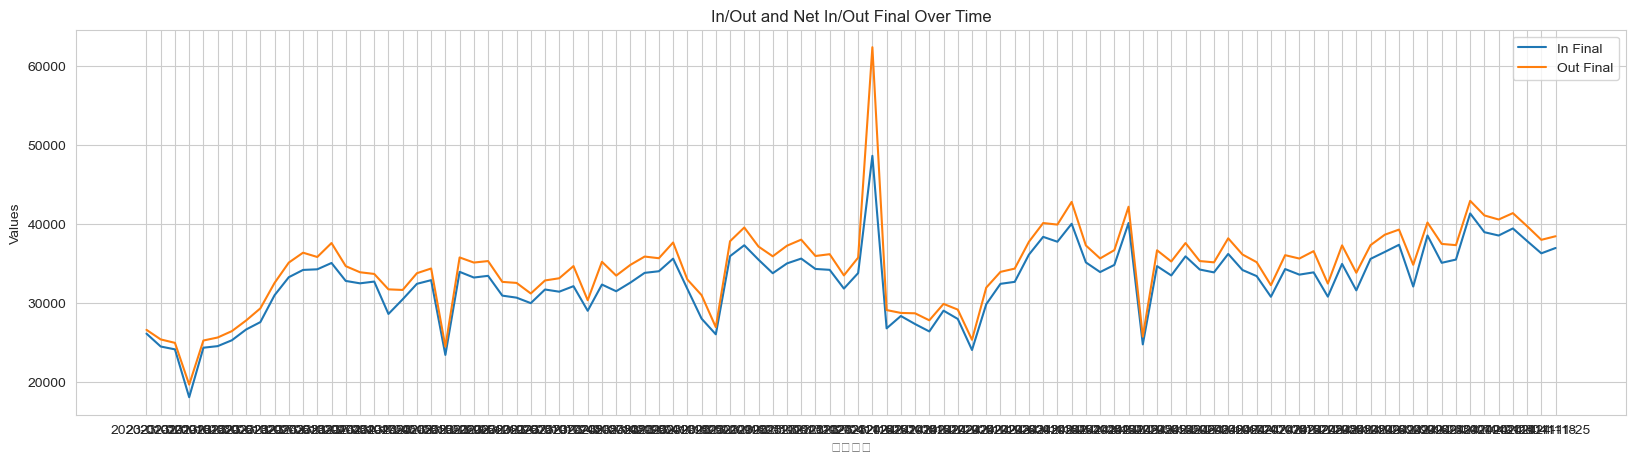

In [2397]:
plt.figure(figsize=(20, 5))

# Plot each column individually
plt.plot(merge_data_md_adj_mon["사용일자"], merge_data_md_adj_mon["in_final"], label="In Final")
plt.plot(merge_data_md_adj_mon["사용일자"], merge_data_md_adj_mon["out_final"], label="Out Final")

# Add legend
plt.legend()

# Add labels and title
plt.xlabel("사용일자")
plt.ylabel("Values")
plt.title("In/Out and Net In/Out Final Over Time")

plt.show()

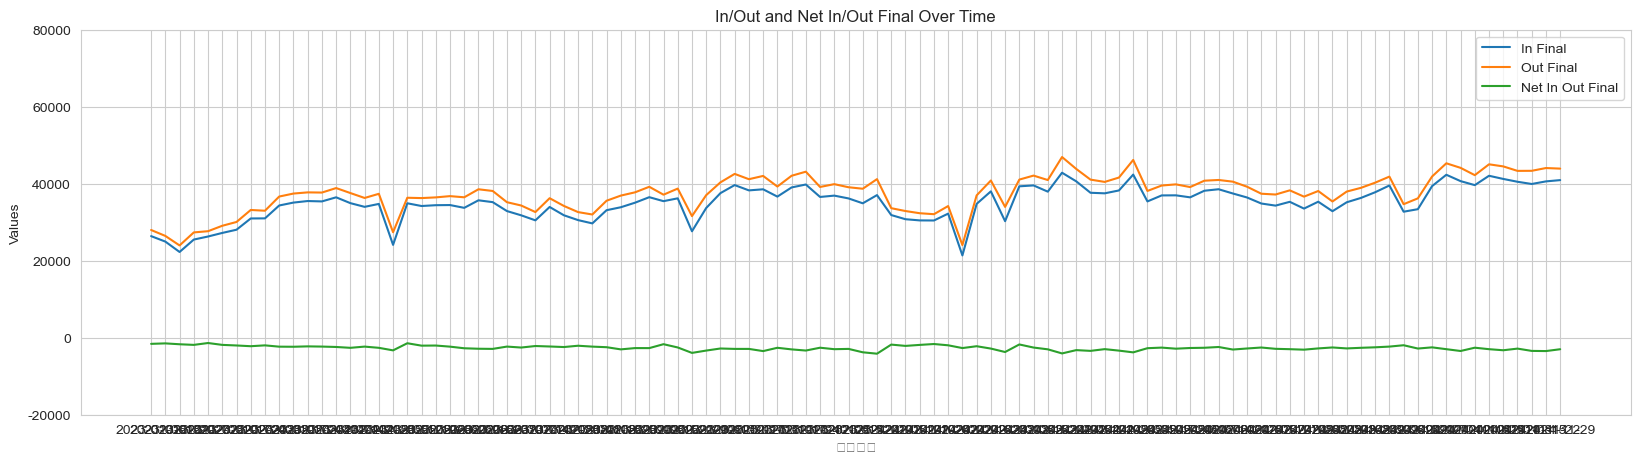

In [2398]:
plt.figure(figsize=(20, 5))

# Plot each column individually
plt.plot(merge_data_md_adj_fri["사용일자"], merge_data_md_adj_fri["in_final"], label="In Final")
plt.plot(merge_data_md_adj_fri["사용일자"], merge_data_md_adj_fri["out_final"], label="Out Final")
plt.plot(merge_data_md_adj_fri["사용일자"], merge_data_md_adj_fri["net_in_out_final"], label="Net In Out Final")

# Add legend
plt.legend()

# Add labels and title
plt.xlabel("사용일자")
plt.ylabel("Values")
plt.title("In/Out and Net In/Out Final Over Time")
plt.ylim(-20000,80000)

plt.show()

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


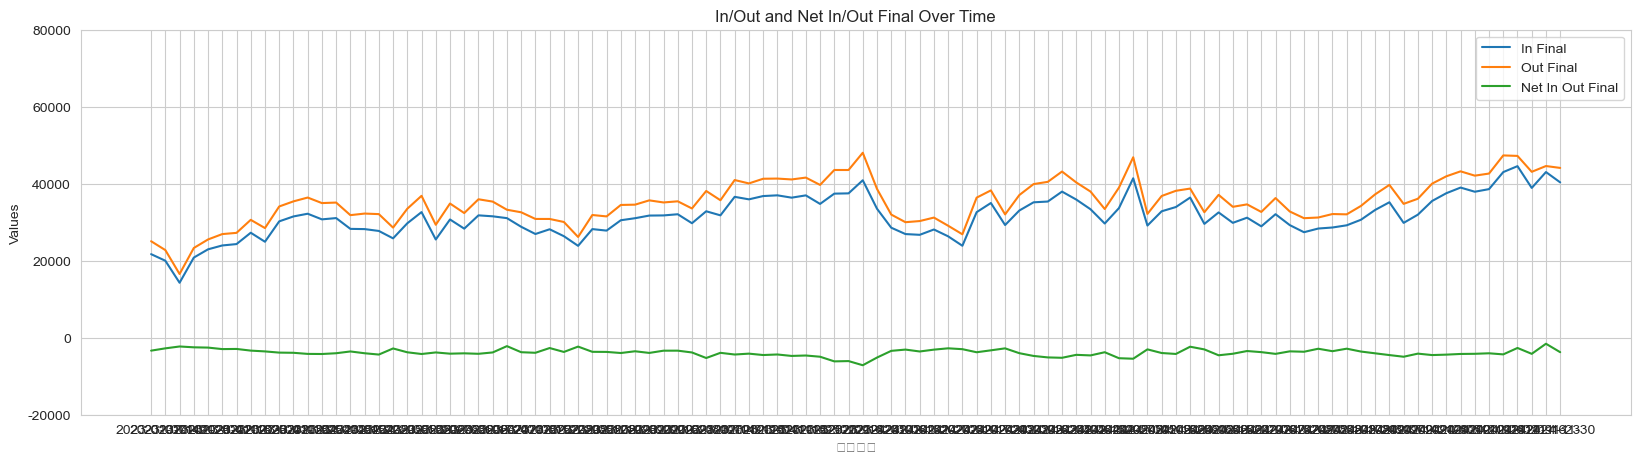

In [2403]:
plt.figure(figsize=(20, 5))

# Plot each column individually
plt.plot(merge_data_md_adj_sat["사용일자"], merge_data_md_adj_sat["in_final"], label="In Final")
plt.plot(merge_data_md_adj_sat["사용일자"], merge_data_md_adj_sat["out_final"], label="Out Final")
plt.plot(merge_data_md_adj_sat["사용일자"], merge_data_md_adj_sat["net_in_out_final"], label="Net In Out Final")

# Add legend
plt.legend()

# Add labels and title
plt.xlabel("사용일자")
plt.ylabel("Values")
plt.title("In/Out and Net In/Out Final Over Time")
plt.ylim(-20000,80000)

plt.show()

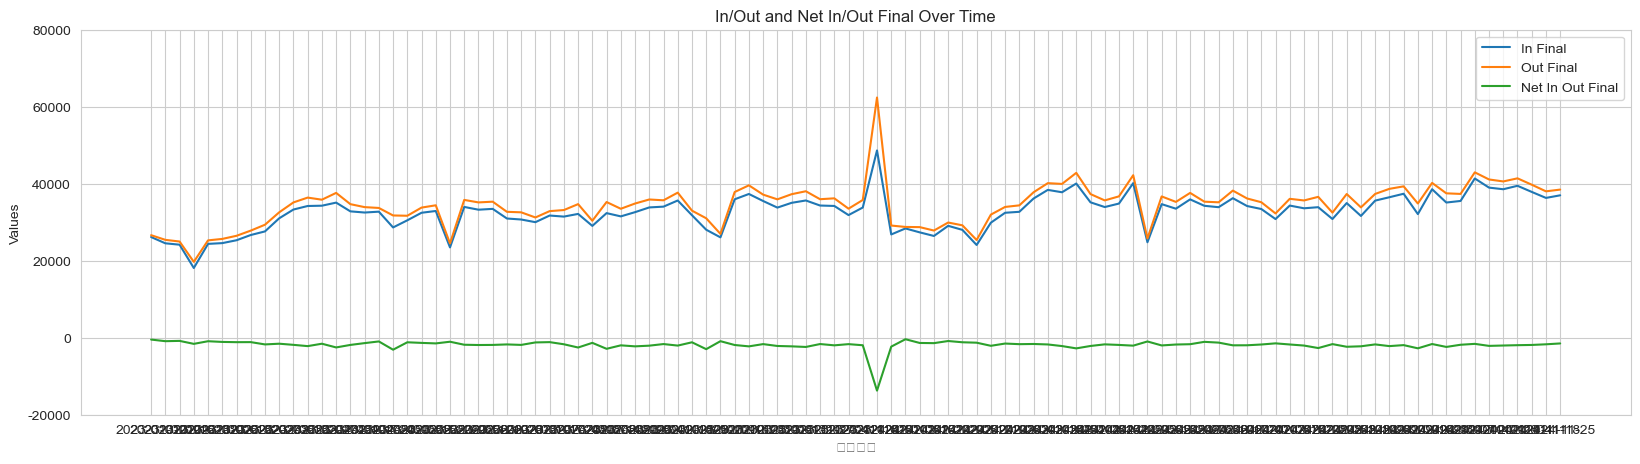

In [2399]:
plt.figure(figsize=(20, 5))

# Plot each column individually
plt.plot(merge_data_md_adj_mon["사용일자"], merge_data_md_adj_mon["in_final"], label="In Final")
plt.plot(merge_data_md_adj_mon["사용일자"], merge_data_md_adj_mon["out_final"], label="Out Final")
plt.plot(merge_data_md_adj_mon["사용일자"], merge_data_md_adj_mon["net_in_out_final"], label="Net In Out Final")

# Add legend
plt.legend()

# Add labels and title
plt.xlabel("사용일자")
plt.ylabel("Values")
plt.title("In/Out and Net In/Out Final Over Time")
plt.ylim(-20000,80000)

plt.show()

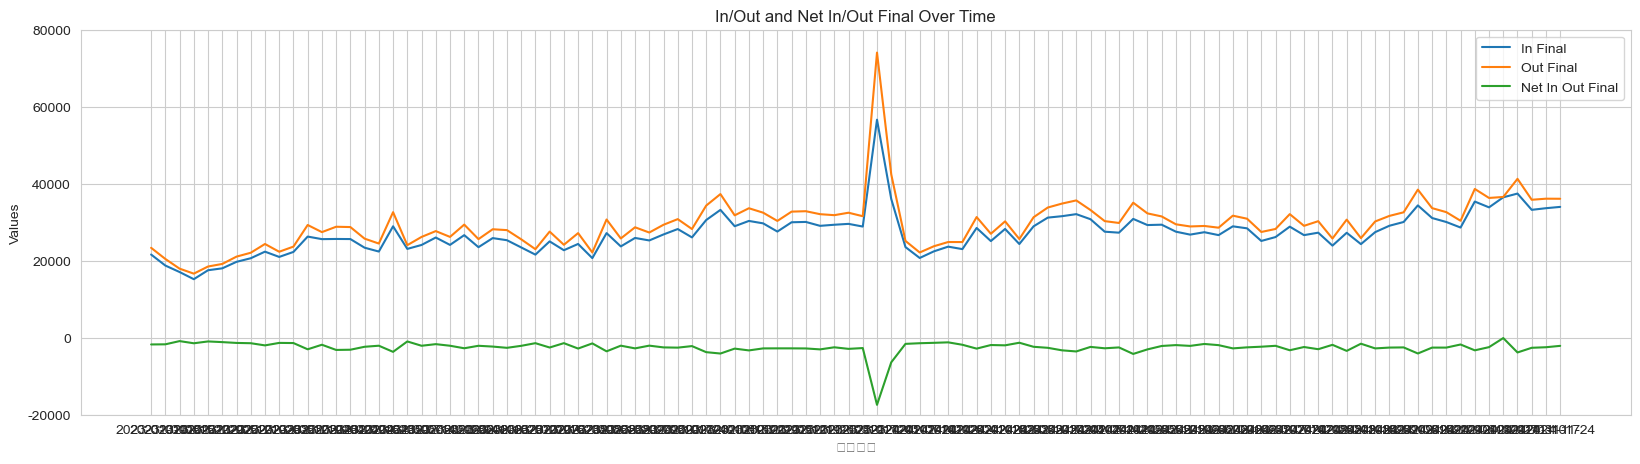

In [2400]:
plt.figure(figsize=(20, 5))

# Plot each column individually
plt.plot(merge_data_md_adj_sun["사용일자"], merge_data_md_adj_sun["in_final"], label="In Final")
plt.plot(merge_data_md_adj_sun["사용일자"], merge_data_md_adj_sun["out_final"], label="Out Final")
plt.plot(merge_data_md_adj_sun["사용일자"], merge_data_md_adj_sun["net_in_out_final"], label="Net In Out Final")

# Add legend
plt.legend()

# Add labels and title
plt.xlabel("사용일자")
plt.ylabel("Values")
plt.title("In/Out and Net In/Out Final Over Time")
plt.ylim(-20000,80000)

plt.show()

In [2401]:
# Create 'pre_week' column by shifting values up by 7 rows
merge_data_md_adj_WD_D["pre_week"] = merge_data_md_adj_WD_D["net_in_out_final"].shift(5)

# Create 'next_week' column by shifting values down by 7 rows
merge_data_md_adj_WD_D["next_week"] = merge_data_md_adj_WD_D["net_in_out_final"].shift(-5)

# Display the updated DataFrame
merge_data_md_adj_WD_D.head(10)  # Show first 10 rows

,사용일자,in_final,out_final,net_in_out_final,pre_week,next_week
0,2023-01-02,26154.73845,26633.46732,-478.72887,NaN,-898.73678
1,2023-01-03,26087.73912,27010.45978,-922.72066,NaN,-1235.72864
2,2023-01-04,25780.74219,26908.46182,-1127.71963,NaN,-1689.71764
3,2023-01-05,25158.74841,26492.47014,-1333.72173,NaN,-1573.72192
4,2023-01-06,26389.73610,27982.44034,-1592.70424,NaN,-1470.72088
5,2023-01-09,24523.75476,25422.49154,-898.73678,-478.72887,-821.74191
6,2023-01-10,24663.75336,25899.48200,-1235.72864,-922.72066,-815.74858
7,2023-01-11,24855.75144,26545.46908,-1689.71764,-1127.71963,-887.73949
8,2023-01-12,24659.75340,26233.47532,-1573.72192,-1333.72173,-550.75609
9,2023-01-13,24969.75030,26440.47118,-1470.72088,-1592.70424,-1698.74329


In [2404]:
merge_data_md_adj_WD_D.dropna(how="any", inplace=True)

In [2405]:
merge_data_md_adj_WD_D

,사용일자,in_final,out_final,net_in_out_final,pre_week,next_week
5,2023-01-09,24523.75476,25422.49154,-898.73678,-478.72887,-821.74191
6,2023-01-10,24663.75336,25899.48200,-1235.72864,-922.72066,-815.74858
7,2023-01-11,24855.75144,26545.46908,-1689.71764,-1127.71963,-887.73949
8,2023-01-12,24659.75340,26233.47532,-1573.72192,-1333.72173,-550.75609
9,2023-01-13,24969.75030,26440.47118,-1470.72088,-1592.70424,-1698.74329
...,...,...,...,...,...,...
471,2024-11-18,36313.63686,38023.23952,-1709.60266,-1875.58377,-1485.60038
472,2024-11-19,36083.63916,38523.22952,-2439.59036,-2174.58749,-2022.59225
473,2024-11-20,37576.62423,39248.21502,-1671.59079,-2063.58082,-2672.56419
474,2024-11-21,38045.61954,40570.18858,-2524.56904,-3223.56603,-2522.57612


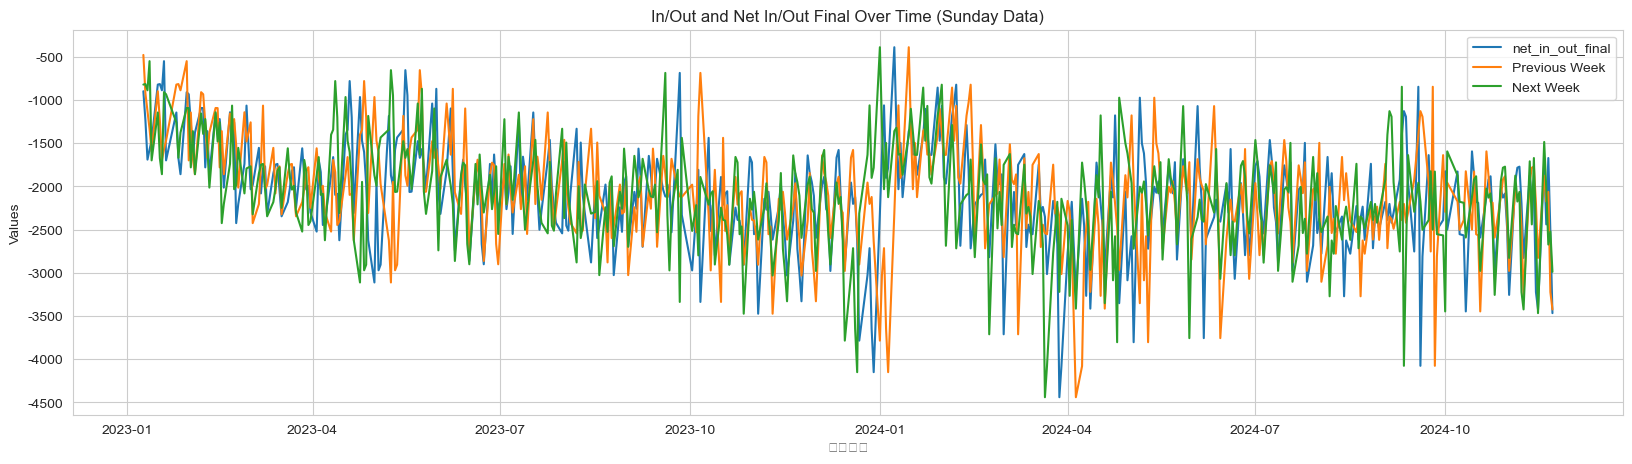

In [2411]:
plt.figure(figsize=(20, 5))

# Plot each column individually
plt.plot(merge_data_md_adj_WD_D["사용일자"], merge_data_md_adj_WD_D["net_in_out_final"], label="net_in_out_final")
plt.plot(merge_data_md_adj_WD_D["사용일자"], merge_data_md_adj_WD_D["pre_week"], label="Previous Week")
plt.plot(merge_data_md_adj_WD_D["사용일자"], merge_data_md_adj_WD_D["next_week"], label="Next Week")

# Add legend
plt.legend()

# Add labels and title
plt.xlabel("사용일자")
plt.ylabel("Values")
plt.title("In/Out and Net In/Out Final Over Time (Sunday Data)")


# Display the plot
plt.show()

Correlation between last week's and this week's net_in_out_final: 0.40448238503515865


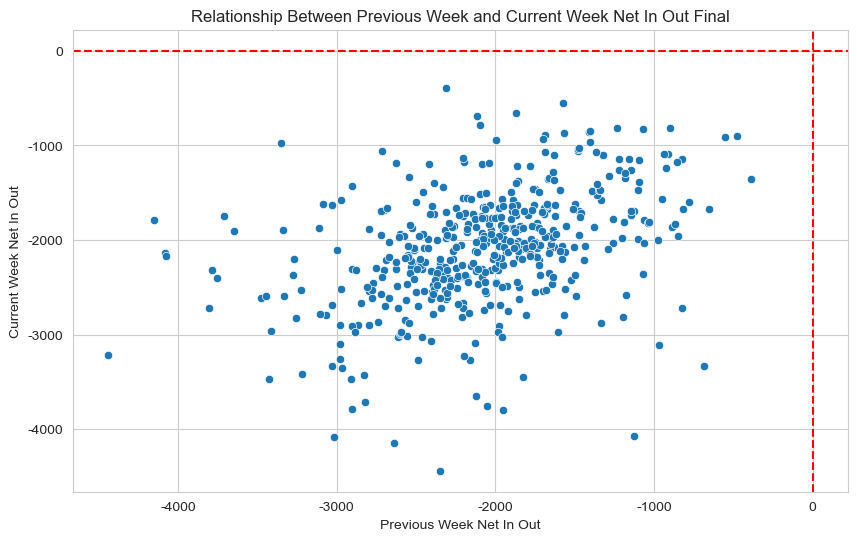

Linear Regression Results:
Slope: 0.4009927820756049
Intercept: -1256.2735722301002
R-squared: 0.16360599980373033
P-value: 5.754237399159273e-20


In [2412]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Compute the correlation
correlation = merge_data_md_adj_WD_D["pre_week"].corr(merge_data_md_adj_WD_D["net_in_out_final"])
print(f"Correlation between last week's and this week's net_in_out_final: {correlation}")

# Scatter plot to visualize the relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=merge_data_md_adj_WD_D["pre_week"],
    y=merge_data_md_adj_WD_D["net_in_out_final"]
)
plt.xlabel("Previous Week Net In Out")
plt.ylabel("Current Week Net In Out")
plt.title("Relationship Between Previous Week and Current Week Net In Out Final")
plt.axhline(0, color='red', linestyle='--')  # Optional: Add a reference line
plt.axvline(0, color='red', linestyle='--')  # Optional: Add a reference line
plt.show()

# Perform linear regression (optional)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    merge_data_md_adj_WD_D["pre_week"],
    merge_data_md_adj_WD_D["net_in_out_final"]
)
print(f"Linear Regression Results:")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")
print(f"P-value: {p_value}")

In [2413]:
from scipy.stats import pearsonr

# Perform Pearson correlation test
corr, p_value = pearsonr(merge_data_md_adj_WD_D["pre_week"], merge_data_md_adj_WD_D["net_in_out_final"])
print(f"Pearson Correlation Coefficient: {corr}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("The correlation is statistically significant.")
else:
    print("The correlation is not statistically significant.")

Pearson Correlation Coefficient: 0.4044823850351589
P-value: 5.754237399158902e-20
The correlation is statistically significant.


In [2441]:
merge_data_md_adj_WD

,사용일자,year,month,time,week,weekend&public holiday,in_final,out_final,net_in_out_final,day
24,2023-01-02,2023,01,00,0,0,37.66320,76.43958,-38.77638,02
25,2023-01-02,2023,01,01,0,0,0.52310,4.79412,-4.27102,02
26,2023-01-02,2023,01,02,0,0,0.00000,0.00000,0.00000,02
27,2023-01-02,2023,01,03,0,0,0.00000,0.00000,0.00000,02
28,2023-01-02,2023,01,04,0,0,1.56930,0.26634,1.30296,02
...,...,...,...,...,...,...,...,...,...,...
16771,2024-11-29,2024,11,19,4,0,3407.59588,2289.86238,1117.73350,29
16772,2024-11-29,2024,11,20,4,0,3289.69732,1656.44946,1633.24786,29
16773,2024-11-29,2024,11,21,4,0,3099.74964,1150.86120,1948.88844,29
16774,2024-11-29,2024,11,22,4,0,2771.84427,663.28260,2108.56167,29


In [2442]:
all_data = merge_data_md_adj_WD.groupby('사용일자')[['in_final', 'out_final', 'net_in_out_final']].sum().reset_index()

In [2443]:
all_data

,사용일자,in_final,out_final,net_in_out_final
0,2023-01-02,26154.73845,26633.46732,-478.72887
1,2023-01-03,26087.73912,27010.45978,-922.72066
2,2023-01-04,25780.74219,26908.46182,-1127.71963
3,2023-01-05,25158.74841,26492.47014,-1333.72173
4,2023-01-06,26389.73610,27982.44034,-1592.70424
...,...,...,...,...
476,2024-11-25,36989.63010,38475.23048,-1485.60038
477,2024-11-26,36728.63271,38751.22496,-2022.59225
478,2024-11-27,38234.61765,40907.18184,-2672.56419
479,2024-11-28,37341.62658,39864.20270,-2522.57612


In [2444]:
# Create 'pre_week' column by shifting values up by 7 rows
all_data["pre_week"] = all_data["net_in_out_final"].shift(7)

# Create 'next_week' column by shifting values down by 7 rows
all_data["next_week"] = all_data["net_in_out_final"].shift(-7)

# Display the updated DataFrame
all_data.head(10)  # Show first 10 rows

,사용일자,in_final,out_final,net_in_out_final,pre_week,next_week
0,2023-01-02,26154.73845,26633.46732,-478.72887,NaN,-1689.71764
1,2023-01-03,26087.73912,27010.45978,-922.72066,NaN,-1573.72192
2,2023-01-04,25780.74219,26908.46182,-1127.71963,NaN,-1470.72088
3,2023-01-05,25158.74841,26492.47014,-1333.72173,NaN,-821.74191
4,2023-01-06,26389.73610,27982.44034,-1592.70424,NaN,-815.74858
5,2023-01-09,24523.75476,25422.49154,-898.73678,NaN,-887.73949
6,2023-01-10,24663.75336,25899.48200,-1235.72864,NaN,-550.75609
7,2023-01-11,24855.75144,26545.46908,-1689.71764,-478.72887,-1698.74329
8,2023-01-12,24659.75340,26233.47532,-1573.72192,-922.72066,-1144.76581
9,2023-01-13,24969.75030,26440.47118,-1470.72088,-1127.71963,-1675.72176


In [2449]:
all_data = pd.merge(all_data, merge_data_md_adj_WD[["사용일자","week","weekend&public holiday"]], on="사용일자", how="left" )

In [2450]:
all_data.dropna(how="any", inplace=True)

In [2452]:
all_data.to_csv("../data/all_data.csv",index=False)

In [2453]:
all_data

,사용일자,in_final,out_final,net_in_out_final,pre_week,next_week,week,weekend&public holiday
0,2023-01-11,24855.75144,26545.46908,-1689.71764,-478.72887,-1698.74329,2,0
1,2023-01-11,24855.75144,26545.46908,-1689.71764,-478.72887,-1698.74329,2,0
2,2023-01-11,24855.75144,26545.46908,-1689.71764,-478.72887,-1698.74329,2,0
3,2023-01-11,24855.75144,26545.46908,-1689.71764,-478.72887,-1698.74329,2,0
4,2023-01-11,24855.75144,26545.46908,-1689.71764,-478.72887,-1698.74329,2,0
...,...,...,...,...,...,...,...,...
11203,2024-11-20,37576.62423,39248.21502,-1671.59079,-1875.58377,-2988.53085,2,0
11204,2024-11-20,37576.62423,39248.21502,-1671.59079,-1875.58377,-2988.53085,2,0
11205,2024-11-20,37576.62423,39248.21502,-1671.59079,-1875.58377,-2988.53085,2,0
11206,2024-11-20,37576.62423,39248.21502,-1671.59079,-1875.58377,-2988.53085,2,0


# lstm

In [2]:
!pip install tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.8/47.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.6/239.6 MB 8.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 40.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 32.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.1/405.1 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 14.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 kB 25.0 MB/s eta 0:00:00


In [3]:
import tensorflow as tf
print(tf.__version__)

2.18.0


Epoch 1/20


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


280/280 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0195 - val_loss: 0.0044
Epoch 2/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0035 - val_loss: 0.0035
Epoch 3/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0031 - val_loss: 0.0027
Epoch 4/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0025 - val_loss: 0.0020
Epoch 5/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 6/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 7/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 8/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 9/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 10/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 11/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 12/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/ste

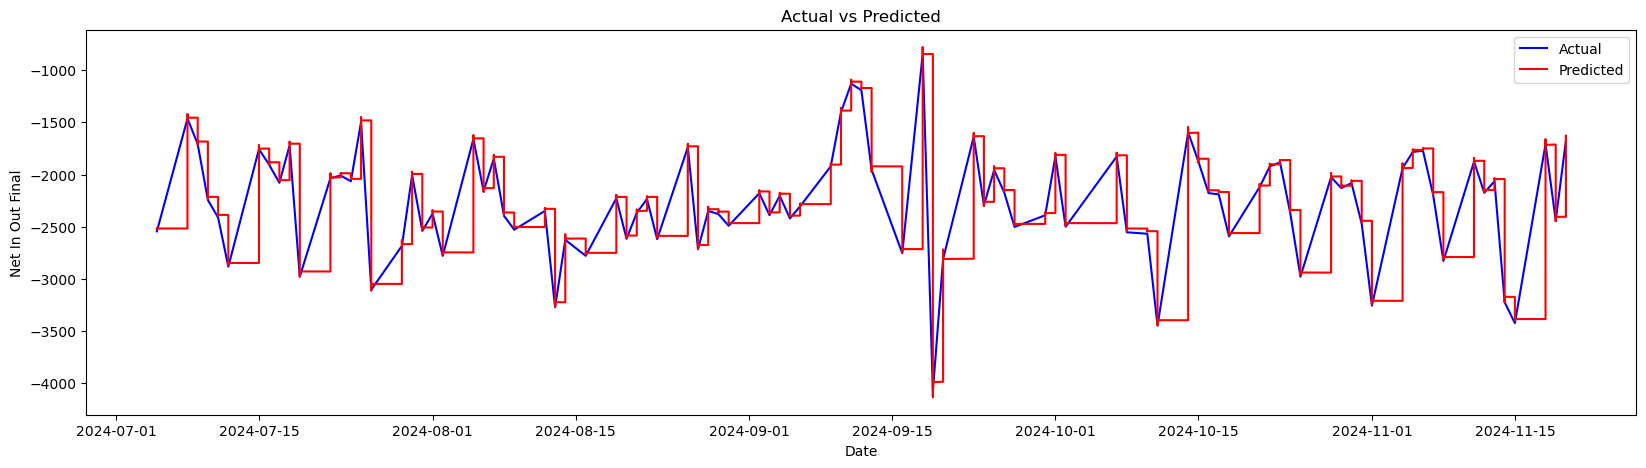

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# Load and preprocess data
data = pd.read_csv("../data/all_data.csv")
data["사용일자"] = pd.to_datetime(data["사용일자"])
data.sort_values(by="사용일자", inplace=True)

# Scale the target column
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[['net_in_out_final']])  # Only the target column

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, 0])  # Use scaled data
        y.append(data[i+seq_length, 0])   # Predict next value
    return np.array(X), np.array(y)

seq_length = 30  # Example: 30 days sequence
X, y = create_sequences(scaled_data, seq_length)

# Reshape X for LSTM input
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build LSTM Model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    LSTM(50),
    Dense(1)
])
model.compile(optimizer="adam", loss="mse")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Make predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)  # Convert back to original scale
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Visualize results
plt.figure(figsize=(20, 5))
plt.plot(data["사용일자"][-len(predictions):], y_test_inverse, label="Actual", color="blue")
plt.plot(data["사용일자"][-len(predictions):], predictions, label="Predicted", color="red")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Net In Out Final")
plt.title("Actual vs Predicted")
plt.show()

Epoch 1/50


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0401 - mae: 0.1274 - val_loss: 0.0042 - val_mae: 0.0329
Epoch 2/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0064 - mae: 0.0567 - val_loss: 0.0038 - val_mae: 0.0391
Epoch 3/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0054 - mae: 0.0522 - val_loss: 0.0029 - val_mae: 0.0258
Epoch 4/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0045 - mae: 0.0470 - val_loss: 0.0025 - val_mae: 0.0210
Epoch 5/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0041 - mae: 0.0444 - val_loss: 0.0026 - val_mae: 0.0311
Epoch 6/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0035 - mae: 0.0410 - val_loss: 0.0024 - val_mae: 0.0290
Epoch 7/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0032 - mae: 0.0381 - val_loss: 0.0018 - val_mae: 0.0170
Epoch 8/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0029 - mae: 0.0369 - val_loss: 0.0016 - val_mae: 0.0134
Epoch 9/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss

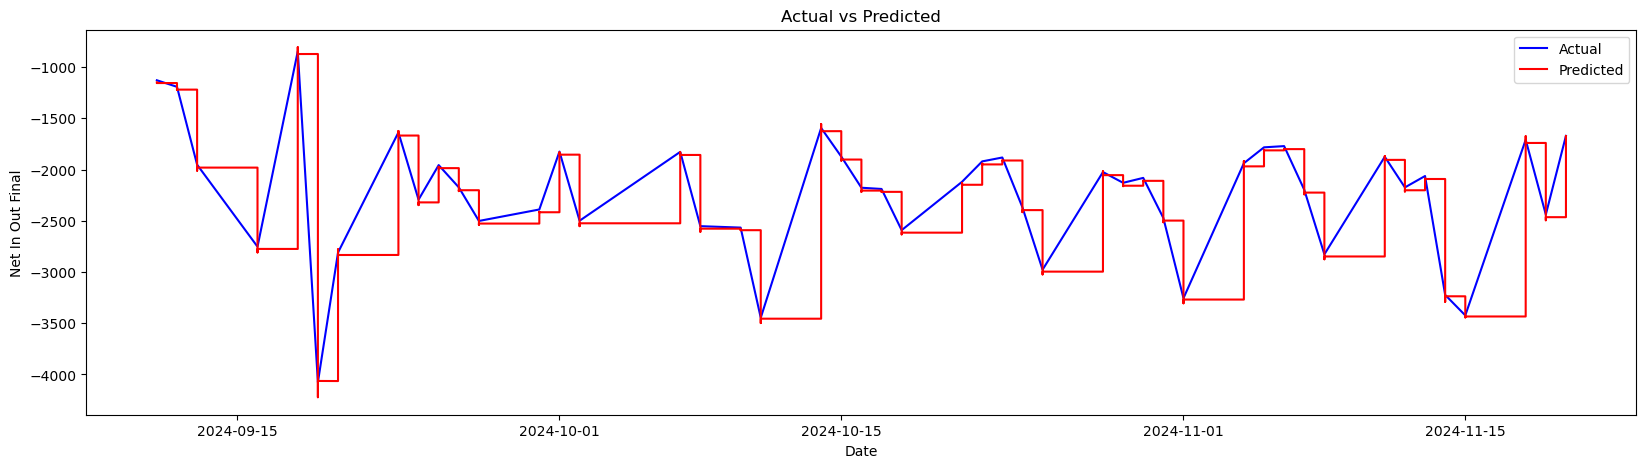

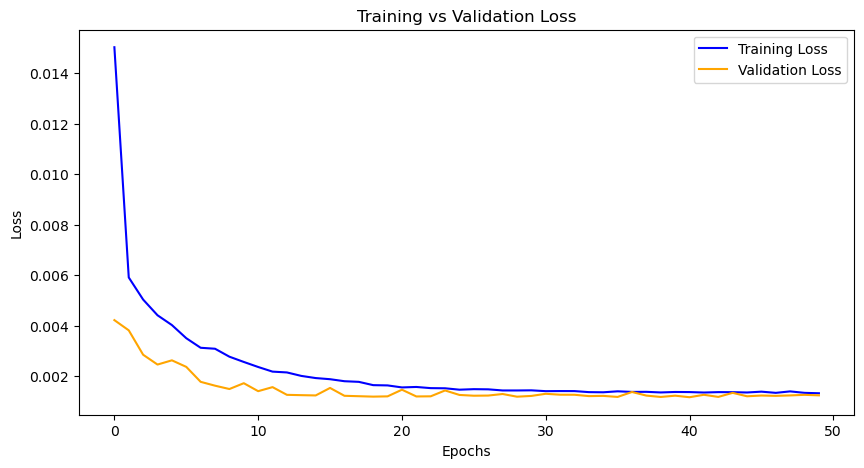

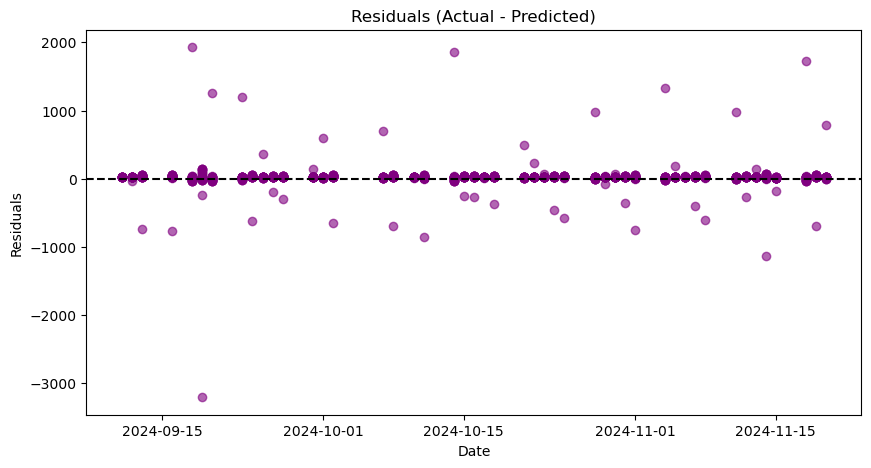

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load and preprocess data
data = pd.read_csv("../data/all_data.csv")
data["사용일자"] = pd.to_datetime(data["사용일자"])
data.sort_values(by="사용일자", inplace=True)

# Scale the target column
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[['net_in_out_final']])

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, 0])
        y.append(data[i+seq_length, 0])
    return np.array(X), np.array(y)

seq_length = 30  # Adjustable sequence length
X, y = create_sequences(scaled_data, seq_length)

# Reshape X for LSTM input
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split into training, validation, and testing sets
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.2)

X_train, X_val, X_test = X[:train_size], X[train_size:train_size + val_size], X[train_size + val_size:]
y_train, y_val, y_test = y[:train_size], y[train_size:train_size + val_size], y[train_size + val_size:]

# Build LSTM Model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),  # Dropout for regularization
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])

# Compile model
optimizer = Adam(learning_rate=0.001)  # Adjustable learning rate
model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

# Train model
history = model.fit(
    X_train, y_train,
    epochs=50,  # Increased epochs for better training
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

# Make predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)  # Convert back to original scale
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Visualize results
plt.figure(figsize=(20, 5))
plt.plot(data["사용일자"][-len(predictions):], y_test_inverse, label="Actual", color="blue")
plt.plot(data["사용일자"][-len(predictions):], predictions, label="Predicted", color="red")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Net In Out Final")
plt.title("Actual vs Predicted")
plt.show()

# Training/Validation Loss Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss", color="blue")
plt.plot(history.history["val_loss"], label="Validation Loss", color="orange")
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# Residual Plot (Error Analysis)
residuals = y_test_inverse - predictions
plt.figure(figsize=(10, 5))
plt.scatter(data["사용일자"][-len(predictions):], residuals, color="purple", alpha=0.6)
plt.axhline(0, linestyle="--", color="black")
plt.title("Residuals (Actual - Predicted)")
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.show()